# Paralog Network 10 - Split vapBC paralogs from PGRS genes within network

# Import Statements (libraries + Functions)

In [777]:
import scipy.stats as stats


In [778]:
import numpy as np
import pandas as pd
import vcf
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import pickle
import scipy.stats
import scipy.stats as stats

%matplotlib inline

In [779]:
import ast

In [780]:
import screed
import mmh3

In [781]:
from Bio import SeqIO


In [782]:
import json

In [783]:
# https://bioframe.readthedocs.io/en/latest/guide-intervalops.html
import bioframe as bf
#import bioframe.vis

In [784]:
import subprocess

In [785]:
from pycirclize import Circos


In [786]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch


In [787]:
from matplotlib.ticker import FuncFormatter

# Function to convert base pairs to megabases
def bp_to_mb(x, pos):
    return f'{x * 1e-6:.1f}'

In [788]:
# Define matplotlib plot style from config file
plt.style.use('../mgm.v1.mplstyle')

In [789]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

#### Pandas Viewing Settings

In [790]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

# Import custom utils functions

In [791]:
%load_ext autoreload
%autoreload 2
    
from gcutils.general import Rv_dist, compute_Paralog_EdgeToEdge_Distance
from gcutils.general import count_substitutions_in_cs, calculate_gc_content_perwindow

from gcutils.eventtoparalogcomparison import genViz_RecombEvent_Vs_Paralogs_V3
from gcutils.eventtoparalogcomparison import process_and_visualize_event

from gcutils.gubbinsfuncs import subset_EventsDF_ForGenes


# from gcutils.homologymapfuncs import label_HmMap_PAF_DF_ByOvrLapGenes, label_HmMap_Variants_DF_ByOvrLapGenes

from gcutils.homologymap_graph import CreatePR_DiGraph, CreatePR_UGraph
from gcutils.homologymap_graph import infer_HmMap_ParalogSet_Labels, add_PR_SetID_to_graph, subset_graph_by_PR_SetIDs, summarize_graph_stats


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Import functions for plotting Gene Annotations + Results (GCEs + Epitopes, MutFreq, etc)

In [792]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

from gcutils.genomeviz_utils import plot_Anno_WiVariantCalls_2Panel, plot_Anno_with_empty_bottom

from gcutils.genomeviz_utils import add_cdseffect_legend, pack_intervals_greedy
from gcutils.genomeviz_utils import plot_multi_event_snp_packed_on_ax_V2, plot_Anno_with_GCE_V3
from gcutils.genomeviz_utils import plot_ParalogVars_Anno_with_GCE

from gcutils.genomeviz_utils import plot_variants_for_isolates_simple
from gcutils.genomeviz_utils import plot_paralog_variants_on_ax
from gcutils.genomeviz_utils import plot_genome_annotation_on_ax

from gcutils.genomeviz_utils import overlay_gc_event_highlights_on_variants

from gcutils.genomeviz_utils import viz_region_Tree_Variants_Anno_ParalogVariants, viz_region_Tree_Variants_Anno


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Import functions related to phylogeny/tree viz

In [793]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload
    
from gcutils.gubbinsfuncs import get_BranchLengths_and_DescendantCounts_FromTree

from gcutils.gubbinsfuncs import annotate_tree_with_lineages, infer_InternalNode_Lineages

from gcutils.treeviz_mpl import mpl_plot_tree

from gcutils.treeviz_ete_utils import subset_tree_by_leaf_ids, subset_ETE_Tree
from gcutils.treeviz_ete_utils import style_ETE3_Tree_ByMtbLineage_V1

from gcutils.treeviz_ete_utils import style_single_node_in_tree
from gcutils.treeviz_ete_utils import subset_ETE_Tree_Style_GCEChildNode 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Define Functions

In [794]:
# < Define functions here as needed >

In [795]:
# # -------------------------
# # Helper: split one region
# # -------------------------
# def splitAndUpdate_ParalogRegion_0based(df, hmregion_id, split_specs):
#     """
#     Assumes 0-based, end-exclusive coordinates.
#     Length = End - Start
#     """
#     og = df.loc[df["HmRegionID"] == hmregion_id].iloc[0].copy()

#     new_rows = []
#     for s in split_specs:
#         r = og.copy()
#         r["HmRegionID"] = s["HmRegionID"]
#         r["Start"] = s["Start"]
#         r["End"] = s["End"]
#         r["Overlap_Genes"] = s["Overlap_Genes"]

#         if "Length" in r:
#             r["Length"] = r["End"] - r["Start"]
#         if "Center" in r:
#             r["Center"] = (r["Start"] + r["End"]) / 2

        
#         new_rows.append(r)

#     df_out = df.loc[df["HmRegionID"] != hmregion_id].copy()
#     df_out = pd.concat([df_out, pd.DataFrame(new_rows)], ignore_index=True)

#     return df_out

In [796]:
# # -------------------------
# # Helper: split one region
# # -------------------------
# def splitAndUpdate_ParalogRegion_V2(df, hmregion_id, split_specs):
#     """
#     Assumes 0-based, end-exclusive coordinates.
#     Length = End - Start
#     """
#     og = df.loc[df["HmRegionID"] == hmregion_id].iloc[0].copy()

#     new_rows = []
#     for s in split_specs:
#         r = og.copy()

        
#         r["HmRegionID"] = s["HmRegionID"]
#         r["Start"] = s["Start"]
#         r["End"] = s["End"]
#         r["Overlap_Genes"] = s["Overlap_Genes"]

#         if "Length" in r:
#             r["Length"] = r["End"] - r["Start"]
#         if "Center" in r:
#             r["Center"] = (r["Start"] + r["End"]) / 2

#         if "PR_SetID" in s.keys():
#             r["PR_SetID"] = s["PR_SetID"]

        
#         new_rows.append(r)

#     df_out = df.loc[df["HmRegionID"] != hmregion_id].copy()
#     df_out = pd.concat([df_out, pd.DataFrame(new_rows)], ignore_index=True)

#     return df_out

In [797]:
import pandas as pd

def splitAndUpdate_ParalogRegion_V3(
    df: pd.DataFrame,
    hmregion_id: str,
    split_specs: list[dict],
    *,
    id_col: str = "HmRegionID",
    start_col: str = "Start",
    end_col: str = "End",
    length_col: str = "Length",
    center_col: str = "Center",
) -> pd.DataFrame:
    """
    Strict splitter/updater for paralog-region rows.

    Requirements (enforced):
      - df must contain: id_col, start_col, end_col, length_col, center_col
      - each split_spec must contain: id_col, start_col, end_col
      - any other keys in split_spec must already exist as columns in df
      - coordinates assumed 0-based, end-exclusive:
            Length = End - Start
            Center = (Start + End) / 2
      - Length and Center are always recomputed (even if provided in split_spec)

    Returns:
      A new dataframe with the original hmregion_id row replaced by the split rows.
    """
    required_df_cols = {id_col, start_col, end_col, length_col, center_col}
    missing = required_df_cols - set(df.columns)
    if missing:
        raise KeyError(f"df is missing required columns: {sorted(missing)}")

    # Find original row
    og_rows = df.loc[df[id_col] == hmregion_id]
    if og_rows.shape[0] != 1:
        raise ValueError(f"Expected exactly 1 row for {hmregion_id}, found {og_rows.shape[0]}")
    og = og_rows.iloc[0].copy()

    df_cols = set(df.columns)

    new_rows = []
    for i, spec in enumerate(split_specs):
        # Required keys in spec
        for req in (id_col, start_col, end_col):
            if req not in spec:
                raise KeyError(f"split_specs[{i}] missing required key '{req}'")

        # Strict: no unknown columns
        unknown_keys = set(spec.keys()) - df_cols
        if unknown_keys:
            raise KeyError(
                f"split_specs[{i}] contains keys not present in df columns: {sorted(unknown_keys)}"
            )

        r = og.copy()

        # Apply overrides (except derived cols, which we always recompute)
        for k, v in spec.items():
            if k in (length_col, center_col):
                continue
            r[k] = v

        # Force numeric coords
        r[start_col] = int(r[start_col])
        r[end_col] = int(r[end_col])

        # Recompute derived columns (0-based, end-exclusive)
        r[length_col] = r[end_col] - r[start_col]
        r[center_col] = (r[start_col] + r[end_col]) / 2.0

        new_rows.append(r)

    # Drop original row + append replacements
    out = df.loc[df[id_col] != hmregion_id].copy()
    out = pd.concat([out, pd.DataFrame(new_rows)], ignore_index=True)

    return out


In [798]:
import pandas as pd

def splitAndUpdate_PairwiseRow_V2(
    df: pd.DataFrame,
    *,
    match: dict,
    new_rows: list[dict],
) -> pd.DataFrame:
    """
    Replace exactly one matched row in a pairwise DF with multiple updated copies.

    - match: column -> value pairs used to identify the single source row
    - new_rows: list of dicts with column overrides for each replacement row
                (all unspecified columns remain identical to the source row)

    Enforces:
      - mask.sum() == 1
      - no unknown columns in updates
    """
    # Build strict mask
    mask = pd.Series(True, index=df.index)
    for col, val in match.items():
        mask &= (df[col] == val)

    n = int(mask.sum())
    if n != 1:
        raise ValueError(f"Expected exactly 1 matched row, found {n} for match={match}")

    src = df.loc[mask].iloc[0].copy()

    # Drop original row
    out = df.loc[~mask].copy()

    # Create updated copies
    new_entries = []
    for i, upd in enumerate(new_rows):
        r = src.copy()
        for col, val in upd.items():
            if col not in df.columns:
                raise KeyError(f"Column '{col}' not found in dataframe (update #{i})")
            r[col] = val
        new_entries.append(r)

    out = pd.concat([out, pd.DataFrame(new_entries)], ignore_index=True)
    return out


# ETE3 Settings & Parameters Setup

### Link to ETE3 documentation for tree layout style
 http://etetoolkit.org/docs/latest/tutorial/tutorial_drawing.html#interactive-visualization-of-trees

In [799]:

import ete3 as ETE

from ete3 import Tree

# https://github.com/ipython/ipython/issues/10627
import os
os.environ['QT_QPA_PLATFORM']='offscreen'

In [800]:
Mtb_LinToColor_Dict = {"lineage1": "#DF83AC",
                      "lineage2": "#7098CB",
                      "lineage3": "#815D9F",
                      "lineage4": "#E76956",
                      "lineage5": "#B67548",
                      "lineage6": "#6AB79E",
                      "lineage8": "#E4515B", 
                      "Ancestral": "black",
                      "None": "black",}


In [801]:

ts_vt_NoScale = ETE.TreeStyle()
ts_vt_NoScale.show_leaf_name = False
ts_vt_NoScale.show_branch_length = False
ts_vt_NoScale.show_branch_support = False
ts_vt_NoScale.show_scale = False #True
ts_vt_NoScale.branch_vertical_margin = 2
ts_vt_NoScale.rotation = 90

ts_hz_NoScale = ETE.TreeStyle()
ts_hz_NoScale.show_leaf_name = False
ts_hz_NoScale.show_branch_length = False
ts_hz_NoScale.show_branch_support = False
ts_hz_NoScale.show_scale = False #True
ts_hz_NoScale.branch_vertical_margin = 2
ts_hz_NoScale.rotation = 0

ts_ColLin = ETE.TreeStyle()
ts_ColLin.show_leaf_name = False
ts_ColLin.show_branch_length = False
ts_ColLin.show_branch_support = False
ts_ColLin.show_scale = True #True
ts_ColLin.branch_vertical_margin = 2
#ts_ColLin.layout_fn = Mtb_ColorBranchByLineage_Layout
ts_ColLin.rotation = 90

ts_ColLin_circ = ETE.TreeStyle()
ts_ColLin_circ.mode = "c" # draw tree in circular mode
ts_ColLin_circ.arc_start = 0 #-180 # 0 degrees = 3 o'clock
ts_ColLin_circ.arc_span = 180
ts_ColLin_circ.show_leaf_name = False
ts_ColLin_circ.show_branch_length = False
ts_ColLin_circ.show_branch_support = False
ts_ColLin_circ.show_scale = False #True
ts_ColLin_circ.branch_vertical_margin = 2
#ts_ColLin_circ.layout_fn = Mtb_ColorBranchByLineage_Layout

ts_ColLin_FullCirc = ETE.TreeStyle()
ts_ColLin_FullCirc.mode = "c" # draw tree in circular mode
ts_ColLin_FullCirc.arc_start = -90 #-180 # 0 degrees = 3 o'clock
ts_ColLin_FullCirc.arc_span = 355
ts_ColLin_FullCirc.show_leaf_name = False
ts_ColLin_FullCirc.show_branch_length = False
ts_ColLin_FullCirc.show_branch_support = False
ts_ColLin_FullCirc.show_scale = False #True
ts_ColLin_FullCirc.branch_vertical_margin = 2
# ts_ColLin_FullCirc.rotation = 90


# Define Color Pallete `Mtb-H37Rv` Gene Categories 

In [802]:
all_categories = [ "PE/PPE", "REP13E12_Repeat", "esx", "conserved hypotheticals", "cell wall and cell processes",
                  "insertion seqs and phages",
                  "intermediary metabolism and respiration", "lipid metabolism", "information pathways",
                  "virulence, detoxification, adaptation", "regulatory proteins",
                   "stable RNAs",  "unknown",  ] 

NQ_Colors = ['065275', '029099', '7CCBA1', 'FDDE9C', 'F0746E', 'DC3978', '7C1E6F']


Mtb_GeneCat_ColorDict = { 
    "PE/PPE" : "#57A89D", #"#1ABFAD", 
    "REP13E12_Repeat" : "#D3516D", 
    "esx" : "#5D81AA", 
    "lipid metabolism" : "#6EA4D4",  # Warm brownish-orange
    "conserved hypotheticals" : "#F2B84A", 
    "cell wall and cell processes" : "#7D3E84", 
    "insertion seqs and phages": "#E16843", 
    "intermediary metabolism and respiration" : "#4F7942",  # Deep green
    "information pathways": "#5698C4",  # Soft blue
    "virulence, detoxification, adaptation": "#B0338E",  # Magenta-purple
    "regulatory proteins": "#A42CD6",  # Vivid violet
    "stable RNAs": "#5C5C5C",  # Neutral dark gray
    "unknown": "#999999",  # Lighter gray for unknown
}

Mtb_GeneCat_ColorPallete =  [Mtb_GeneCat_ColorDict[cat] for cat in all_categories] 

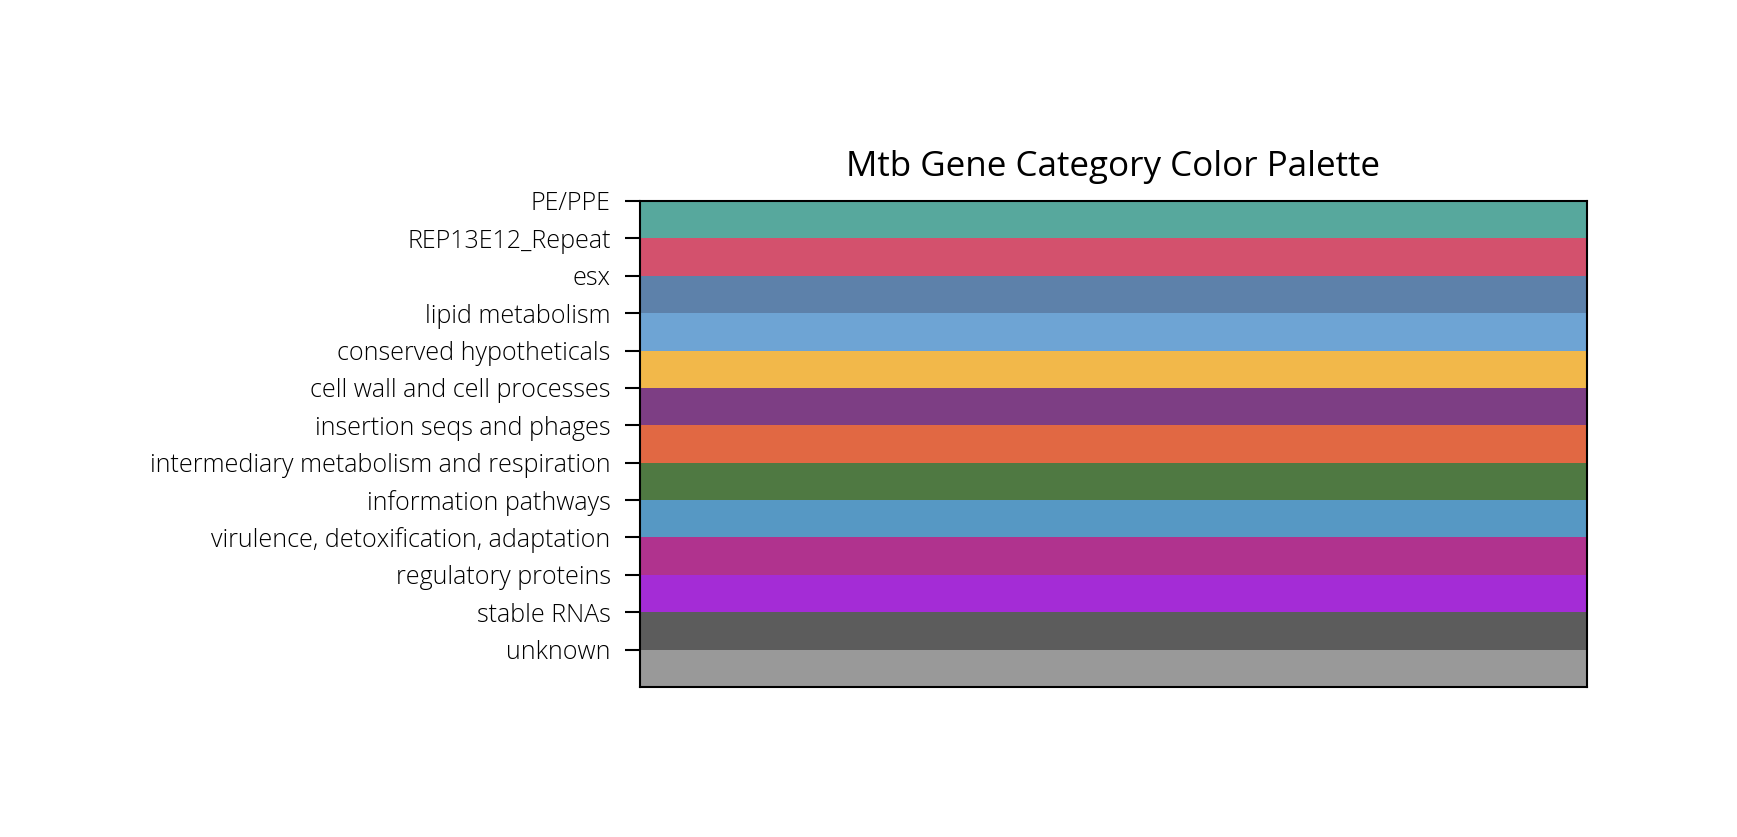

In [803]:
# Plot the colors
fig, ax = plt.subplots(figsize=(5, 2))
ax.set_xlim(0, 1)
ax.set_ylim(0, len(Mtb_GeneCat_ColorDict))
ax.set_xticks([])
ax.set_yticks(range(len(Mtb_GeneCat_ColorDict)))
ax.set_yticklabels(Mtb_GeneCat_ColorDict.keys(), fontsize=6)

for i, (category, color) in enumerate(Mtb_GeneCat_ColorDict.items()):
    ax.add_patch(plt.Rectangle((0, i), 1, 1, color=color))

plt.gca().invert_yaxis()
plt.title("Mtb Gene Category Color Palette")
plt.show()

# Pre-process Data for Genome Viz w/ `DNA-Features-Viewer`

### Import/setup DNA Features Viewer (For plotting H37rv genome annotations)

In [804]:
from dna_features_viewer import GraphicFeature, GraphicRecord, CircularGraphicRecord, BiopythonTranslator
from Bio import SeqIO
from Bio.SeqFeature import SeqFeature, FeatureLocation


In [805]:
BiopythonTranslator.label_fields = ['gene', 'label', 'source', 'locus_tag', 'note', 'gene', 'product']
BiopythonTranslator.ignored_features_types = ["source", "gene"]
BiopythonTranslator.default_feature_color = "lightgrey"

## Create H37Rv Genome Record + Results Features Objects

In [806]:
H37rv_Ref_GBK_PATH = "/n/data1/hms/dbmi/farhat/mm774/References/GCF_000195955.2_ASM19595v2_genomic.gbk"

In [807]:
records = list(SeqIO.parse(H37rv_Ref_GBK_PATH, "genbank"))
print(len(records))
Mtb_H37rv_SeqIO_Record = records[0]

CDS_Features = []

for feature in Mtb_H37rv_SeqIO_Record.features:
    if feature.type == "CDS":
        CDS_Features.append(feature) 
        # if "gene" in feature.qualifiers.keys():
        #     if feature.qualifiers["locus_tag"] == ['Rv1196']:
        #         print(feature)
        #         print()

# --- Manually add esxM (Rv1792) ---

# esxM gene info
esxM_start = 2030346  # GenBank is 0-based, so subtract 1 from 1-based start
esxM_end = 2030643    # end is exclusive in Biopython
esxM_seq = (
    "atggcctcacgttttatgacggatccgcatgcgatgcgggacatggcgggccgttttgaggtgcacgcccagacggtggaggacgaggctcgccggatgtgggcgtccgcgcaaaacatttccggtgcgggctggagtggcatggccgaggcgacctcgctagacaccatgacctagatgaatcaggcgtttcgcaacatcgtgaacatgctgcacggggtgcgtgacgggctggttcgcgacgccaacaactacgaacagcaagagcaggcctcccagcagatcctgagcagctag"
)

# Create the SeqFeature object
esxM_feature = SeqFeature(
    location=FeatureLocation(esxM_start, esxM_end, strand=1),
    type="CDS",
    qualifiers={
        "locus_tag": ["Rv1792"],
        "gene": ["esxM"],
        "product": ["esxM hypothetical protein"],
        "translation": [
            "MASRFMTDPHAMRDMAGRFEVHAQTVEDEARRMWASAQNISGAGWSGMAEATSLDTMTMNQAFRNIVNMLHGVRDGLVRDANNYEQQEQASQQILSS"
        ]
    }
)



# --- Manually add vapB25 (Rv0277A) ---

# esxM gene info
vapB25_start = 333159  # GenBank is 0-based, so subtract 1 from 1-based start
vapB25_end = 333417    # end is exclusive in Biopython
vapB25_DNA_seq = (
    "atgcgcaccaccgtgtcaatctcggatgaactactggctaccgccaaacgccgggcccgcgagcgtggttaatcgctgggcgctgtgatcgaagacgcccttcggcgggagctcgccgccgcccgtaccggcggcgcccggccaaccgtccccgtttttgacgccggcaccggtccgcggccaggtatcgacctaacctcgaatacggtgttgtccgaagtgctcgacgagggtctggaactgaactcgcggaagtga"
)

# Create the SeqFeature object
vapB25_feature = SeqFeature(
    location=FeatureLocation(vapB25_start, vapB25_end, strand=-1),
    type="CDS",
    qualifiers={
        "locus_tag": ["Rv0277A"],
        "gene": ["vapB25"],
        "product": ["Possible toxin vapB25"],
        "translation": [
            "MRTTVSISDELLATAKRRARERGSLGAVIEDALRRELAAARTGGARPTVPVFDAGTGPRPGIDLTSNTVLSEVLDEGLELNSRK"
        ]
    }
)


# Append to the list of CDS features
CDS_Features.append(esxM_feature)
CDS_Features.append(vapB25_feature)

Mtb_H37rv_SeqIO_Record.features = CDS_Features

Mtb_H37rv_Graphic_Record = BiopythonTranslator().translate_record(Mtb_H37rv_SeqIO_Record)
Mtb_H37rv_Graphic_Record.feature_level_height = 0

1


# Parse `Mtb151CI` Isolate Metadata

In [808]:
Repo_DataDir = "../../Data"
InputAsmPath_Dir = f"{Repo_DataDir}/231121.InputAsmTSVs.MtbSetV3.151CI"

MtbSetV3_151CI_InputAsmPATHs_TSV = f"{InputAsmPath_Dir}/231121.MtbSetV3.151CI.HybridAndSRAsm.FAPATHs.V1.tsv"
MtbSetV3_151CI_AsmSumm_TSV = f"{InputAsmPath_Dir}/231121.MtbSetV3.151CI.HybridAsm.AsmSummary.V2.tsv"


### Reading in "WGA151CI_AsmSummary_DF"

In [809]:
WGA151CI_AsmSummary_DF = pd.read_csv(MtbSetV3_151CI_AsmSumm_TSV, sep = "\t")

SampleIDs_151CI_SOI = list( WGA151CI_AsmSummary_DF["SampleID"].values )
WGA151CI_SampleIDs = SampleIDs_151CI_SOI
WGA151CI_AsmSummary_DF.shape


(151, 7)

#### Create SampleID Mapping Dicts

In [810]:
WGA151CI_ID_To_PrimLineage_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'PrimaryLineage']].values)
WGA151CI_ID_To_SubLineage_Dict = dict( WGA151CI_AsmSummary_DF[["SampleID", "Lineage"]].values)
WGA151CI_ID_To_Dataset_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'Dataset_Tag']].values)  

SampleID_To_PrimLineage_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'PrimaryLineage']].values)
SampleID_To_SubLineage_Dict = dict( WGA151CI_AsmSummary_DF[["SampleID", "Lineage"]].values)
SampleID_To_Dataset_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'Dataset_Tag']].values)  


In [811]:
WGA151CI_OrderOfSampleIDs_Phylo = ['N0153', 'N0072', 'mada_2-46', 'mada_1-44', 'mada_107', 'mada_1-1', 'mada_1-51',
                          'mada_1-39', 'mada_1-36', 'mada_117', 'mada_122', 'mada_118', 'mada_1-10', 'R27252',
                          'R23887', 'TB3091', '9050-05', '3003-06', '702-06', '696-05', '8651-04', 'TB3396',
                          '4549-04', 'TB1612', 'TB2780', 'TB3368', 'TB1236', 'TB2659', '8129-04', 'R30215',
                          'R25048', 'TB2512', 'TB2981', 'TB2995', 'TB3113', '706-05', 'R30078', 'R28012',
                          'R27657', 'R30234', 'R31095', 'R28703', 'R24120', 'R36431', 'R29816', 'S0070-08',
                          'N0155', 'N0145', 'R29598', 'R24100', 'S0107-01', 'R28581', 'S0256-08', 'S0085-01',
                          'S0089-01', 'mada_1-11', 'M0003941_3', 'mada_115', 'mada_2-42', 'R37765', '18_0621851',
                          'R22601', 'R27937', 'R18040', 'R18043', 'R27725', 'R26791', 'R20574', 'R20260', 'R21408',
                          'R23146', 'R28980', 'R32929', 'R26778', 'R30420', 'R21893', 'QC-9', 'QC-5', 'QC-3', 'N0004',
                          'mada_1-30', 'N0054', 'N1274', '01_R1134', 'TB2968', 'mada_1-53', 'mada_2-53', 'mada_1-50',
                          'mada_2-1', 'R23571', 'mada_123', 'mada_1-12', 'mada_1-15', 'mada_128', 'mada_1-38', 'TB3054',
                          'mada_126', 'mada_120', 'TB4620', 'M0016737_0', 'M0016395_7', 'R15311', 'TB2661', 'TB3386',
                          'TB3162', '02_R1179', 'M0010874_7', 'QC-7', 'QC-6', 'QC-1', '01_R1430', 'M0011368_9',
                          '02_R1896', 'mada_2-25', 'TB3237', 'mada_103', 'mada_112', 'mada_124', 'S0123-01', 'S0262-02',
                          'TB3251', 'M0017522_5', 'R30396', 'R20896', 'mada_1-32', 'S0106-01', 'R21839', 'R21363', 'R21770',
                          'MT_0080', 'mada_102', 'TB3334', 'M0014888_3', 'mada_151', 'TB3169', 'mada_105', 'QC-8', 'QC-10',
                          'QC-4', 'mada_129', 'mada_139', '02_R1708', '02_R0894', 'mada_2-31', 'mada_1-41', 'N1272', 'N1176',
                          'N1202', 'N0091', 'N1177', 'RW-TB008']


In [812]:
!pwd 

/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/Analysis/4_Mtb_RecombEvent_Explore_V6


# Parse all individual variants per genome annotated by CDS effect (`WGA-151CI`)

In [813]:
Mtb151_AllVar_Dir = "../../Data/241030.Mtb151CI.AllVariants.Anno.V1/"

Mtb151_AllVar_TSVGZ              = f"{Mtb151_AllVar_Dir}/Mtb.151CI.AllVariants.V1.tsv.gz"
Mtb151_AllVar_WiCDSAnno_TSVGZ    = f"{Mtb151_AllVar_Dir}/Mtb.151CI.AllVariants.WiCDSAnno.V1.tsv.gz"
Mtb151_SNPs_WiInterSNPDist_TSVGZ = f"{Mtb151_AllVar_Dir}/Mtb.151CI.AllSNPs.WiInterSNPDists.V1.tsv"


In [814]:

Mtb151CI_AllAsm_AllVar_DF = pd.read_csv(Mtb151_AllVar_WiCDSAnno_TSVGZ, sep="\t")

# WGA151_AllVar_DF = Mtb151CI_AllAsm_AllVar_DF
AllAsm_AllVar_DF = Mtb151CI_AllAsm_AllVar_DF
AllAsm_AllVar_DF.shape

(260869, 20)

In [815]:
AllAsm_AllVar_DF["SampleID"].nunique()

151

# Parse HHRs tested for Enrichment of "Paralog-Matching" SNPs

In [816]:
PerPR_ParalogSNP_EnrichTest_Results_Dir = "/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/Analysis/4_Mtb_ParalogRegions_MutPatternComparison_V4/EnrichTestForParalogSNPs_PerParalogRegion"

ParalogReg_TestForParalogSNPs_All_TSV = f"{PerPR_ParalogSNP_EnrichTest_Results_Dir}/PRs.TestedForParalogSNPS.AllRegions.V1.tsv"

ParalogReg_TestForParalogSNPs_SigOnly_TSV = f"{PerPR_ParalogSNP_EnrichTest_Results_Dir}/PRs.TestedForParalogSNPS.SigOnly.V1.tsv"


PR_ParalogSNPTest_All_DF = pd.read_csv(ParalogReg_TestForParalogSNPs_SigOnly_TSV,
                                        sep = "\t")

PR_ParalogSNPTest_SigOnly_DF = pd.read_csv(ParalogReg_TestForParalogSNPs_SigOnly_TSV,
                                            sep = "\t")


PR_ParalogSNPTest_All_DF["Num_Overlap_Genes"] = PR_ParalogSNPTest_All_DF["Overlap_Genes"].str.split(",").apply(len)
PR_ParalogSNPTest_SigOnly_DF["Num_Overlap_Genes"] = PR_ParalogSNPTest_SigOnly_DF["Overlap_Genes"].str.split(",").apply(len)

print(PR_ParalogSNPTest_All_DF.shape)
print(PR_ParalogSNPTest_SigOnly_DF.shape)

(60, 33)
(60, 33)


In [817]:
PR_ParalogSNPTest_SigOnly_DF.head()

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID,NPossible_SNPs_Total,NPossible_ParalogSNPs,NObserved_SNPs_Total,NObserved_SNPs_MatchParalogSNP,p_value,log_p_value,neglog_p_value,NExpected_MatchParalogSNP,p_corr,neglog_p_corr,NucDivHotspot_Ovrlap,FoldEnrichment,LogFoldEnrichment,Log2FoldEnrichment,AbsEnrichment,SizeFactor,Fraction_SNPs_MatchParalog,Num_Overlap_Genes
0,165,NC_000962.3,3710379,3712822,3711600.5,2443,"Rv3325,Rv3326,Rv3327",3,15,1,0,165,PR_HmRegion_165,1,PR_Set_24,7329,1,17,4,0.0,500.0,500.0,0.002320,1.000000e-40,500.0,0,1724.470588,3.236656,10.751938,3.997680,0.018605,0.235294,3
1,25,NC_000962.3,606510,608060,607285.0,1550,"Rv0515,Rv0516c",0,1,1,0,25,PR_HmRegion_025,0,PR_Set_13,4650,1,10,3,0.0,500.0,500.0,0.002151,1.000000e-40,500.0,0,1395.000000,3.144574,10.446049,2.997849,0.013953,0.300000,2
2,44,NC_000962.3,1169296,1170733,1170014.5,1437,Rv1047,1,5,3,0,44,PR_HmRegion_044,0,PR_Set_30,4311,2,34,16,0.0,500.0,500.0,0.015774,1.000000e-40,500.0,0,1014.352941,3.006189,9.986344,15.984226,0.074419,0.470588,1
3,15,NC_000962.3,400151,401701,400926.0,1550,Rv0336,0,1,1,0,15,PR_HmRegion_015,0,PR_Set_13,4650,1,14,3,0.0,500.0,500.0,0.003011,1.000000e-40,500.0,0,996.428571,2.998446,9.960623,2.996989,0.013953,0.214286,1
4,158,NC_000962.3,3481324,3482760,3482042.0,1436,Rv3115,1,5,3,0,158,PR_HmRegion_158,0,PR_Set_30,4308,2,64,29,0.0,500.0,500.0,0.029712,1.000000e-40,500.0,0,976.031250,2.989464,9.930784,28.970288,0.134884,0.453125,1


In [818]:
PR_ParalogSNPTest_SigOnly_DF.query("HmRegionID == 'PR_HmRegion_009' ")  

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID,NPossible_SNPs_Total,NPossible_ParalogSNPs,NObserved_SNPs_Total,NObserved_SNPs_MatchParalogSNP,p_value,log_p_value,neglog_p_value,NExpected_MatchParalogSNP,p_corr,neglog_p_corr,NucDivHotspot_Ovrlap,FoldEnrichment,LogFoldEnrichment,Log2FoldEnrichment,AbsEnrichment,SizeFactor,Fraction_SNPs_MatchParalog,Num_Overlap_Genes
49,9,NC_000962.3,332698,336379,334538.5,3681,"vapC25,vapB25,PE_PGRS3",0,4,4,4,9,PR_HmRegion_009,0,PR_Set_10,11043,838,49,32,1.561059e-24,-54.816678,54.816678,3.718374,2.450862e-22,49.760432,0,8.605913,0.934797,3.105328,28.281626,0.148837,0.653061,3


In [819]:
PR_ParalogSNPTest_SigOnly_DF.query("HmRegionID == 'PR_HmRegion_032' ")  

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID,NPossible_SNPs_Total,NPossible_ParalogSNPs,NObserved_SNPs_Total,NObserved_SNPs_MatchParalogSNP,p_value,log_p_value,neglog_p_value,NExpected_MatchParalogSNP,p_corr,neglog_p_corr,NucDivHotspot_Ovrlap,FoldEnrichment,LogFoldEnrichment,Log2FoldEnrichment,AbsEnrichment,SizeFactor,Fraction_SNPs_MatchParalog,Num_Overlap_Genes
56,32,NC_000962.3,838485,841665,840075.0,3180,"PE_PGRS10,vapB31,vapC31",0,8,8,8,32,PR_HmRegion_032,0,PR_Set_10,9540,1272,73,43,6.095098e-20,-44.244217,44.244217,9.733333,9.569304e-18,39.187971,0,4.417808,0.645207,2.143331,33.266667,0.2,0.589041,3


# Import/parse processed H37rv genome annotations

In [820]:
RepoRef_Dir = "../../References"

AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir = f"{RepoRef_Dir}/201027_H37rv_AnnotatedGenes_And_IntergenicRegions"
#H37Rv_GenomeAnnotations_Genes_TSV = f"{AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir}/H37Rv_GenomeAnnotations.Genes.tsv"
H37Rv_GenomeAnnotations_Genes_V2_TSV = f"{AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir}/H37Rv_GenomeAnnotations.Genes.V2.tsv"

## H37Rv Gene Annotations TSV
H37Rv_GenomeAnno_Genes_DF = pd.read_csv(H37Rv_GenomeAnnotations_Genes_V2_TSV, sep = "\t")
H37Rv_GeneInfo_Subset_DF = H37Rv_GenomeAnno_Genes_DF[["H37rv_GeneID", "Symbol", "Feature", "Functional_Category", "Is_Pseudogene", "Product", "PEandPPE_Subfamily", "ExcludedGroup_Category"]]

RvID_To_Symbol_Dict = dict(H37Rv_GenomeAnno_Genes_DF[['H37rv_GeneID', 'Symbol']].values)
Symbol_To_RvID_Dict = dict(H37Rv_GenomeAnno_Genes_DF[['Symbol', 'H37rv_GeneID']].values)
Symbol_To_FuncCat_Dict = dict(H37Rv_GenomeAnno_Genes_DF[['Symbol', 'Functional_Category']].values)

ESX_Genes_List_TSV = f"{RepoRef_Dir}/190927_H37rv_ListOf_ESXgenes.tsv"
Esx_Genes_DF = pd.read_csv(ESX_Genes_List_TSV, sep = '\t')

In [821]:
H37Rv_GenomeAnno_Genes_DF.head(1)

,Chrom,Start,End,Strand,H37rv_GeneID,Symbol,Feature,Functional_Category,Is_Pseudogene,Product,PEandPPE_Subfamily,ExcludedGroup_Category,Gene_Cat_V2
0,NC_000962.3,0,1524,+,Rv0001,dnaA,CDS,information pathways,No,Chromosomal replication initiator protein DnaA,NaN,NotExcluded,information pathways


### Define paths to H37Rv genome masking schemes

In [822]:
RepoRef_Dir = "../../References"

MaskingSchemes_Dir = f"{RepoRef_Dir}/Mtb_H37Rv_MaskingSchemes"
PLC_Scheme_BED = f"{MaskingSchemes_Dir}/201027_Mtb_H37rv_pLC_Regions_CoscollaExcludedGenes.bed"


### Define relevant H37Rv gene lists for analysis (PE/PPE, Esx, 13E12 gene)

In [823]:
ListOf_Esx_Symbols = list(Esx_Genes_DF["symbol"].values)
ListOf_Esx_RvIDs = list(Esx_Genes_DF["gene_id"].values)

In [824]:
listOf_PEPPE_Symbols = list( H37Rv_GenomeAnno_Genes_DF.query(" Functional_Category == 'PE/PPE' ")["Symbol"].values )
listOf_PEPPE_RvIDs = list( H37Rv_GenomeAnno_Genes_DF.query(" Functional_Category == 'PE/PPE' ")["H37rv_GeneID"].values )

In [825]:
listOf_13E12_Region_RvIDs = ["Rv0094c", "Rv0095c", "Rv0393", "Rv1572c", "Rv1572c", "Rv1128c", "Rv1148c", "Rv1587c", "Rv1588c", "Rv1702c", "Rv1945", "Rv2100", "Rv3466", "Rv3467"]  


# Parse H37Rv Reference sequences (Genome, Genes, Proteins)

## Parse H37Rv genome sequence (DNA)

In [826]:
from Bio import SeqIO


In [827]:
H37rv_Ref_GBK_PATH = "/n/data1/hms/dbmi/farhat/mm774/References/GCF_000195955.2_ASM19595v2_genomic.gbk"
H37Rv_FA = "/n/data1/hms/dbmi/farhat/mm774/References/GCF_000195955.2_ASM19595v2_genomic.fasta"

H37Rv_Seq = SeqIO.read(H37Rv_FA, "fasta").seq
len(H37Rv_Seq)

4411532

## Parse H37Rv Protein (AA) and gene (DNA) sequences

In [828]:
O2_RefDir = "/n/data1/hms/dbmi/farhat/mm774/References"

MycoBrowser_RefFiles_Dir = f"{O2_RefDir}/190619_Mycobrowser_H37rv_ReferenceFiles"

H37Rv_Proteins_MycoBro_FAA = f"{MycoBrowser_RefFiles_Dir}/Mycobacterium_tuberculosis_H37Rv_proteins_v3_TrimmedHeader.fasta"
H37Rv_Proteins_MycoBro_FAA = f"{MycoBrowser_RefFiles_Dir}/Mycobacterium_tuberculosis_H37Rv_proteins_v3_TrimmedHeader.esxM_Added.fasta"
H37Rv_Proteins_NCBI_FAA = f"{MycoBrowser_RefFiles_Dir}/Mycobacterium_tuberculosis_H37Rv_proteins_v3_TrimmedHeader.fasta"
H37RV_Genes_FA = f"{MycoBrowser_RefFiles_Dir}/Mycobacterium_tuberculosis_H37Rv_genes_v3.fasta"



H37Rv_FAA_PATH = f"{O2_RefDir}/GCF_000195955.2_ASM19595v2_proteins.faa"
H37Rv_FAA_PATH = f"{O2_RefDir}/GCF_000195955.2_ASM19595v2_proteins.esxM_Added.faa"
H37Rv_GBK_PATH = f"{O2_RefDir}/GCF_000195955.2_ASM19595v2_genomic.gbk"


In [829]:
!ls -1 $MycoBrowser_RefFiles_Dir

Mycobacterium_tuberculosis_H37Rv_genes_v3.fasta
Mycobacterium_tuberculosis_H37Rv_genome_v3.fasta
Mycobacterium_tuberculosis_H37Rv_genome_v3.fasta.fai
Mycobacterium_tuberculosis_H37Rv_gff_v3.gff
Mycobacterium_tuberculosis_H37Rv_gff_v3.REP13E12_Regions.gff
Mycobacterium_tuberculosis_H37Rv_proteins_v3.fasta
Mycobacterium_tuberculosis_H37Rv_proteins_v3_TrimmedHeader.esxM_Added.fasta
Mycobacterium_tuberculosis_H37Rv_proteins_v3_TrimmedHeader.fasta
Mycobacterium_tuberculosis_H37Rv_txt_v3_PEPPE_subfamilies.txt
Mycobacterium_tuberculosis_H37Rv_txt_v3.txt.tsv


### Parse MycoBrowser Protein Seq Ref

In [830]:
dictOf_H37Rv_MycoBrow_ProtSeq = {}

for index, record in tqdm(enumerate(SeqIO.parse(H37Rv_Proteins_MycoBro_FAA, "fasta"))):
    ShortID = record.name
    
    dictOf_H37Rv_MycoBrow_ProtSeq[ShortID] = record.seq


4091it [00:00, 174549.33it/s]


### Parse MycoBrowser Gene Seq Ref

In [831]:
dictOf_H37Rv_MycoBrow_Gene_Seq = {}

for index, record in tqdm(enumerate(SeqIO.parse(H37RV_Genes_FA, "fasta"))):

    ShortID = record.name.split("|")[0]
    dictOf_H37Rv_MycoBrow_Gene_Seq[ShortID] = record.seq


4187it [00:00, 122827.80it/s]


In [832]:
list(dictOf_H37Rv_MycoBrow_Gene_Seq.keys())[:2]

['Rv3728', 'Rv3729']

### Parse NCBI Protein Seq Ref

In [833]:
dictOf_H37Rv_ProtSeq = {}
dictOf_H37Rv_ProtRecord = {}

for index, record in tqdm(enumerate(SeqIO.parse(H37Rv_FAA_PATH, "fasta"))):
    Rec_Description = record.description
    dict_Attr = {}
    for i in Rec_Description.split(" "):
        ###Just looking for line with " " character (as key = value)
        if "=" in i:
            key = i.strip().split("=")[0].strip('"').strip('[')
            value = i.strip().split("=")[1].strip('"').strip(']')
            ###Put them in a dictionnary
            dict_Attr[key]=value
    
    ShortID = dict_Attr["locus_tag"]
    dictOf_H37Rv_ProtSeq[ShortID] = record.seq
    dictOf_H37Rv_ProtRecord[ShortID] = record


3907it [00:00, 92776.68it/s]


In [834]:
#dictOf_H37Rv_ProtSeq["Rv1196"]

In [835]:
#dictOf_H37Rv_ProtSeq["Rv1196"] == dictOf_H37Rv_MycoBrow_ProtSeq["Rv1196"]

In [836]:
dictOf_H37Rv_ProtSeq["Rv1792"]

Seq('MASRFMTDPHAMRDMAGRFEVHAQTVEDEARRMWASAQNISGAGWSGMAEATSLDTMT')

In [837]:
dictOf_H37Rv_MycoBrow_ProtSeq["Rv1792"]

Seq('MASRFMTDPHAMRDMAGRFEVHAQTVEDEARRMWASAQNISGAGWSGMAEATSLDTMT')

# Parse in H37Rv Homology-Map Results (k19w19)

### Define all HmMap file paths

In [838]:
Main_Project_Dir = "/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V9"

H37_Rv_MM2_HomologyMapping_Dir = f"{Main_Project_Dir}/250901.H37Rv.HomologyMapping.k19w19.ProcessedData.V2"

# Define paths to output TSVS

### Homologous regions (MERGED)
RvHmMap_Merged_ParaRegions_TSV  = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.MergedRegions.ParalogousRegions.k19w19.tsv"
RvHmMap_Merged_LocalRepeats_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.MergedRegions.LocalRepeats.k19w19.tsv"

### Homology map (pairwise alignments)
RvHmMap_Aln_All_TSV           = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.All.tsv"
RvHmMap_Aln_PRs_NoOverlap_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.NoOverlap.tsv"
RvHmMap_Aln_LRs_WiOverlap_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.WiOverlap.tsv"

RvHmMap_Aln_PRs_NoOverlap_Clustered_TSV     = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.NoOverlap.Clustered.tsv"
RvHmMap_Aln_LRs_WiOverlap_Clustered_TSV     = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.OnlyOverlap.Clustered.tsv"

### Variants from the homology map alignments
RvHmMap_Var_TSV      = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.variants.tsv"
RvHmMap_Var_SNPs_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.variants.snps.tsv"



### Variants from the homology map alignments (For each pairwise alignment between PRs)
RvHmMap_Var_PerAln_TSV      = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.variants.ParalogousRegions.PerAln.tsv"
RvHmMap_Var_PerAln_SNPs_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.variants.ParalogousRegions.PerAln.snps.tsv"



### Parse in HmRegions (`Paralogous_Regions` and `Local_Repeats`)

In [839]:
HmMapRegs_ParaRegs_k19w19_DF = pd.read_csv(RvHmMap_Merged_ParaRegions_TSV,
                                           sep="\t")

HmMapRegs_ParaRegs_k19w19_DF.shape

(200, 15)

In [840]:
HmMapRegs_LocalRepeats_k19w19_DF = pd.read_csv(RvHmMap_Merged_LocalRepeats_TSV, 
                                               sep="\t")
HmMapRegs_LocalRepeats_k19w19_DF.shape

(50, 13)

In [841]:
HmMapRegs_All_LRsPRs_K19w19_DF = pd.concat([HmMapRegs_ParaRegs_k19w19_DF,
                                            HmMapRegs_LocalRepeats_k19w19_DF])

HmMapRegs_All_LRsPRs_K19w19_DF.shape

(250, 15)

#### Peak at head of each HmMap Regions DFs

In [842]:
HmMapRegs_ParaRegs_k19w19_DF.head()

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID
0,0,NC_000962.3,80184,80523,80353.5,339,Rv0071,0,1,1,1,0,PR_HmRegion_000,0,PR_Set_1
1,1,NC_000962.3,80623,82664,81643.5,2041,"Rv0072,Rv0073",0,1,1,1,1,PR_HmRegion_001,0,PR_Set_2
2,2,NC_000962.3,103705,105130,104417.5,1425,"Rv0094c,Rv0095c",0,2,2,2,2,PR_HmRegion_002,0,PR_Set_3
3,3,NC_000962.3,149571,149808,149689.5,237,PE_PGRS2,0,1,1,1,3,PR_HmRegion_003,0,PR_Set_4
4,4,NC_000962.3,177203,177447,177325.0,244,_,0,1,1,1,4,PR_HmRegion_004,0,PR_Set_5


In [843]:
HmMapRegs_LocalRepeats_k19w19_DF.head()

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID
0,0,NC_000962.3,333811,335879,334845.0,2068,PE_PGRS3,0,1,1,1,0,LR_HmRegion_000
1,1,NC_000962.3,366430,375121,370775.5,8691,"PPE5,PPE6",0,6,6,6,1,LR_HmRegion_001
2,2,NC_000962.3,424011,432951,428481.0,8940,"hspR,PPE7,PPE8",0,5,4,4,2,LR_HmRegion_002
3,3,NC_000962.3,566288,580814,573551.0,14526,"hbhA,Rv0476,Rv0477,deoC,Rv0479c,Rv0480c,Rv0481...",0,4,2,1,3,LR_HmRegion_003
4,4,NC_000962.3,631298,631436,631367.0,138,Rv0538,0,2,2,2,4,LR_HmRegion_004


### Parse in homology-map DFs (pairwise alignments between all homologous regions)

In [844]:
HmMap_Aln_k19w19_DF = pd.read_csv(RvHmMap_Aln_All_TSV,
                           sep="\t")
HmMap_Aln_k19w19_DF.shape

(776, 25)

In [845]:
HmMap_Aln_k19w19_NoOverlap_DF = pd.read_csv(RvHmMap_Aln_PRs_NoOverlap_TSV,
                                     sep="\t")
HmMap_Aln_k19w19_NoOverlap_DF.shape

(640, 38)

In [846]:
HmMap_Aln_k19w19_LocalRepeat_DF = pd.read_csv(RvHmMap_Aln_LRs_WiOverlap_TSV,
                                              sep="\t")
HmMap_Aln_k19w19_LocalRepeat_DF.shape

(136, 35)

### Parse in HomologyMap Alignment Variants DFs

In [847]:
### paralog variants - Improved per alignment `cs` tag approach 
Mtb_HM_Var_PR_DF = pd.read_csv(RvHmMap_Var_PerAln_TSV, sep="\t")
print(Mtb_HM_Var_PR_DF.shape)

Mtb_HM_Var_PR_SNPs_DF = pd.read_csv(RvHmMap_Var_PerAln_SNPs_TSV, sep="\t")
print(Mtb_HM_Var_PR_SNPs_DF.shape)

(60402, 20)
(50203, 20)


In [848]:
Mtb_HM_Var_PR_SNPs_DF.head(4)

,Target_Name,Target_Start,Target_End,Strand,Ref,Alt,SNP,Type,Query_Name,Query_Start,Query_End,HmMap_Aln_ID,Aln_Query_Start,Aln_Query_End,Aln_Target_Start,Aln_Target_End,Aln_Strand,QueryOverlap_Genes,TargetOverlap_Genes,QueryParalog_RegionID
0,NC_000962.3,3082657,3082658,+,T,C,True,SNP,NC_000962.3,80412,80413,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523
1,NC_000962.3,3082660,3082661,+,C,A,True,SNP,NC_000962.3,80415,80416,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523
2,NC_000962.3,3082667,3082668,+,G,A,True,SNP,NC_000962.3,80422,80423,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523
3,NC_000962.3,3082669,3082670,+,T,C,True,SNP,NC_000962.3,80424,80425,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523


In [849]:
TarCol = ['Target_Name', 'Target_Start', 'Target_End', 'Ref', 'Alt', 'SNP'] 

Mtb_HM_Var_PR_SNPs_Trim_DF = Mtb_HM_Var_PR_SNPs_DF[TarCol]

print(Mtb_HM_Var_PR_SNPs_Trim_DF.shape)

Mtb_HM_Var_PR_SNPs_Trim_TrimUnq_DF = Mtb_HM_Var_PR_SNPs_Trim_DF.drop_duplicates()

print(Mtb_HM_Var_PR_SNPs_Trim_TrimUnq_DF.shape)


(50203, 6)
(41454, 6)


In [850]:
Mtb_HM_Var_PR_SNPs_Trim_TrimUnq_DF.head(3)

,Target_Name,Target_Start,Target_End,Ref,Alt,SNP
0,NC_000962.3,3082657,3082658,T,C,True
1,NC_000962.3,3082660,3082661,C,A,True
2,NC_000962.3,3082667,3082668,G,A,True


In [851]:
# Mtb_HM_Var_DF = pd.read_csv(RvHmMap_Var_TSV, sep="\t")
# Mtb_HM_Var_SNPs_DF = pd.read_csv(RvHmMap_Var_SNPs_TSV, sep="\t")

# print(Mtb_HM_Var_DF.shape)
# print(Mtb_HM_Var_SNPs_DF.shape)

In [852]:
Mtb_HM_Var_PR_SNPs_DF.head(5)

,Target_Name,Target_Start,Target_End,Strand,Ref,Alt,SNP,Type,Query_Name,Query_Start,Query_End,HmMap_Aln_ID,Aln_Query_Start,Aln_Query_End,Aln_Target_Start,Aln_Target_End,Aln_Strand,QueryOverlap_Genes,TargetOverlap_Genes,QueryParalog_RegionID
0,NC_000962.3,3082657,3082658,+,T,C,True,SNP,NC_000962.3,80412,80413,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523
1,NC_000962.3,3082660,3082661,+,C,A,True,SNP,NC_000962.3,80415,80416,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523
2,NC_000962.3,3082667,3082668,+,G,A,True,SNP,NC_000962.3,80422,80423,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523
3,NC_000962.3,3082669,3082670,+,T,C,True,SNP,NC_000962.3,80424,80425,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523
4,NC_000962.3,3082671,3082672,+,G,A,True,SNP,NC_000962.3,80426,80427,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523


In [853]:
HmMap_Aln_k19w19_NoOverlap_DF.head(5)

,Query_Name,Query_Start,Query_End,Strand,Target_Name,Target_Start,Target_End,Num_ResidueMatches,Aln_BlockLength,cs,SeqID,Target_Middle,Query_Middle,Dist_Middles,Query_Length,Target_Length,QueryOverlap_Genes,TargetOverlap_Genes,AlnOverlapsWithSelf,PerfectRepeat,Query_NOvrlap_Transposase,Target_NOvrlap_Transposase,QueryCoords,TargetCoords,QueryToTarget_ID,Query_Cluster,Query_Cluster_Start,Query_Cluster_End,Target_Cluster,Target_Cluster_Start,Target_Cluster_End,Query_HmRegionID,Target_HmRegionID,Query_HmRegionNum,Target_HmRegionNum,Query_NOvrlap_IS6110_Label,Target_NOvrlap_IS6110_Label,PR_SetID
0,NC_000962.3,80184,80523,+,NC_000962.3,3082465,3082769,283.0,340.0,:187+gcggctcaaccgatatcgacaaactcaccttcacct:5*tc...,0.832353,3082617.0,80353.5,1409268.5,339,304,Rv0071,Rv2774c,False,False,0,0,NC_000962.3:80184-80523,NC_000962.3:3082465-3082769,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,0,80184,80523,134,3082465,3082769,PR_HmRegion_000,PR_HmRegion_136,0,136,0,0,PR_Set_1
1,NC_000962.3,80623,82664,+,NC_000962.3,2882289,2884330,1650.0,2058.0,:5*tc:2*tc:5*tc*tc:7*tc*ga:1*cg:6*ca:4*ag:2*ac...,0.801749,2883309.5,81643.5,1609866.0,2041,2041,"Rv0072,Rv0073","Rv2563,glnQ",False,False,0,0,NC_000962.3:80623-82664,NC_000962.3:2882289-2884330,NC_000962.3:80623-82664;NC_000962.3:2882289-28...,1,80623,82664,124,2882289,2884330,PR_HmRegion_001,PR_HmRegion_126,1,126,0,0,PR_Set_2
2,NC_000962.3,103705,105090,-,NC_000962.3,3883535,3884921,1346.0,1390.0,:6*cg:2-ac:3+gc:13*tc:2*tc:14*gc:23*tc:9*tc:3*...,0.968345,3884228.0,104397.5,631701.5,1385,1386,"Rv0094c,Rv0095c","Rv3466,Rv3467",False,False,0,0,NC_000962.3:103705-105090,NC_000962.3:3883535-3884921,NC_000962.3:103705-105090;NC_000962.3:3883535-...,2,103705,105130,177,3883535,3884921,PR_HmRegion_002,PR_HmRegion_180,2,180,0,0,PR_Set_3
3,NC_000962.3,103779,105130,+,NC_000962.3,1788513,1789865,1316.0,1354.0,:987*tc:5*tc:1*ga:6*ag:2*ga:5*tc:2*tc:5*at*gt:...,0.971935,1789189.0,104454.5,1684734.5,1351,1352,"Rv0094c,Rv0095c","Rv1587c,Rv1588c",False,False,0,0,NC_000962.3:103779-105130,NC_000962.3:1788513-1789865,NC_000962.3:103779-105130;NC_000962.3:1788513-...,2,103705,105130,73,1788513,1789865,PR_HmRegion_002,PR_HmRegion_074,2,74,0,0,PR_Set_3
4,NC_000962.3,149571,149808,-,NC_000962.3,1357376,1357613,195.0,241.0,:3*tc:5*ag:8*gt:2+t:2+ag:5-gcg:4*tc*ca:2*gc:1*...,0.809129,1357494.5,149689.5,1207805.0,237,237,PE_PGRS2,PE14,False,False,0,0,NC_000962.3:149571-149808,NC_000962.3:1357376-1357613,NC_000962.3:149571-149808;NC_000962.3:1357376-...,3,149571,149808,55,1357376,1357613,PR_HmRegion_003,PR_HmRegion_056,3,56,0,0,PR_Set_4


# Parse `Nuc-Div` results for `WGA-151CI` dataset

## Define NucDiv analysis file paths

In [854]:
AnalysisName = "250201.WGA151CI.V10"

Main_Project_Dir = "/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V10"

Target_Output_Dir = f"{Main_Project_Dir}/{AnalysisName}"

VCFT_NucDiv_Dir = f"{Target_Output_Dir}/VCFtools_SNV_NucDiv_AcrossH37Rv"

Pickle_PATH_WGA_NucDiv_PI_Dict = VCFT_NucDiv_Dir + f"/{AnalysisName}.SNVs.NucDiv.DictOfResults.pickle"   

#NucDiv_NoFilt_1kb_TSV_PATH = f"{VCFT_NucDiv_Dir}/WGA.SNVs.NucDiv.1000bp.ALL.tsv"
NucDiv_NoFilt_1kb_TSV_PATH = f"{VCFT_NucDiv_Dir}/WGA.SNVs.NucDiv.1000bp.ALL.Anno.tsv"
NucDiv_NoFilt_1kb_V2_TSV_PATH = f"{VCFT_NucDiv_Dir}/WGA.SNVs.NucDiv.1000bp.ALL.Anno.V2.tsv"


### Parse pickle of NucDiv stats

In [855]:
with open(Pickle_PATH_WGA_NucDiv_PI_Dict, "rb") as f: NucDiv_PI_Dict = pickle.load(f)
NucDiv_PI_Dict.keys()

dict_keys([('ALL', 1000)])

In [856]:
xx_1kb_All_np = NucDiv_PI_Dict[("ALL", 1000)]["Fill_np"]["XX"]
yy_1kb_All_np = NucDiv_PI_Dict[("ALL", 1000)]["Fill_np"]["YY"] * 1000


### Parse 1-kb NucDiv DF

In [857]:
# Read in TSV
WGA_NucDiv_PI_1kb_DF = pd.read_csv(NucDiv_NoFilt_1kb_V2_TSV_PATH, sep = "\t")

NucDiv_1kb_DF = WGA_NucDiv_PI_1kb_DF

# Calculate mean, median, standard deviation, and Median Absolute Deviation
median_1kb_PI = NucDiv_1kb_DF['NucDiv'].median()
mean_1kb_PI = NucDiv_1kb_DF['NucDiv'].mean()
std_1kb_PI = NucDiv_1kb_DF['NucDiv'].std()
MAD_1kb_PI = np.median(np.abs(NucDiv_1kb_DF['NucDiv'] - median_1kb_PI))


### Define NucDiv Hospots (N = 37)

In [858]:
NucDiv_HSR_1kb_DF = NucDiv_1kb_DF.query("IsNucDivHotspot == True")
NucDiv_HSR_1kb_DF.shape

(37, 20)

In [859]:
NucDiv_HSR_1kb_DF.head(5)

,Chrom,Start,End,NucDiv,OverlapGenes,Middle,NucDiv_kb,NucDiv_Z,NucDiv_ModZ,IsNucDivHotspot,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMapAln_PR,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMapAln_LR,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmap,PLC_Mask_Count,PLC_Mask_Ovrlap
103,NC_000962.3,103000,104000,0.004051,"Rv0093c,Rv0094c",103500.0,4.05131,6.567424,18.817330,True,2,1,0,0,0,0,1,1,1,1
104,NC_000962.3,104000,105000,0.015961,"Rv0094c,Rv0095c",104500.0,15.96060,27.525938,76.880144,True,2,1,0,0,0,0,3,1,2,1
105,NC_000962.3,105000,106000,0.003371,"Rv0095c,PPE1",105500.0,3.37124,5.370605,15.501701,True,2,1,0,0,0,0,1,1,2,1
338,NC_000962.3,338000,339000,0.005144,PE_PGRS4,338500.0,5.14383,8.490090,24.143826,True,2,1,0,0,1,1,6,1,1,1
1095,NC_000962.3,1095000,1096000,0.003100,"rpmF,PE_PGRS18",1095500.0,3.10016,4.893546,14.180072,True,2,1,0,0,1,1,3,1,1,1


#### Extra Inspection of NucDiv DFs

In [860]:
NucDiv_1kb_DF.head(2)

,Chrom,Start,End,NucDiv,OverlapGenes,Middle,NucDiv_kb,NucDiv_Z,NucDiv_ModZ,IsNucDivHotspot,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMapAln_PR,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMapAln_LR,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmap,PLC_Mask_Count,PLC_Mask_Ovrlap
0,NC_000962.3,0,1000,0.000218,dnaA,500.0,0.217905,-0.178778,0.127863,False,0,0,0,0,0,0,0,0,0,0
1,NC_000962.3,1000,2000,0.000791,dnaA,1500.0,0.790654,0.829172,2.920256,False,0,0,0,0,0,0,0,0,0,0


In [861]:
NucDiv_1kb_DF["NucDiv_kb"].describe()

count    4421.000000
mean        0.319492
std         0.568232
min         0.000000
25%         0.078678
50%         0.191679
75%         0.405184
max        15.960600
Name: NucDiv_kb, dtype: float64

In [862]:
NucDiv_HSR_1kb_DF.head(4)

,Chrom,Start,End,NucDiv,OverlapGenes,Middle,NucDiv_kb,NucDiv_Z,NucDiv_ModZ,IsNucDivHotspot,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMapAln_PR,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMapAln_LR,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmap,PLC_Mask_Count,PLC_Mask_Ovrlap
103,NC_000962.3,103000,104000,0.004051,"Rv0093c,Rv0094c",103500.0,4.05131,6.567424,18.817330,True,2,1,0,0,0,0,1,1,1,1
104,NC_000962.3,104000,105000,0.015961,"Rv0094c,Rv0095c",104500.0,15.96060,27.525938,76.880144,True,2,1,0,0,0,0,3,1,2,1
105,NC_000962.3,105000,106000,0.003371,"Rv0095c,PPE1",105500.0,3.37124,5.370605,15.501701,True,2,1,0,0,0,0,1,1,2,1
338,NC_000962.3,338000,339000,0.005144,PE_PGRS4,338500.0,5.14383,8.490090,24.143826,True,2,1,0,0,1,1,6,1,1,1


In [863]:
NucDiv_HSR_1kb_DF.query("OvrlapWi_HmMapAln_PR == 1").shape

(36, 20)

In [864]:
NucDiv_HSR_1kb_DF.query("OvrlapWi_HmMapAln_PR == 0").shape

(1, 20)

# Parse `Mtb151-MainAnalysis` Gubbins Results

### Define dictionary of file paths for Gubbins analysis

In [865]:
AnalysisName = "250201.WGA151CI.V10"

Main_Project_Dir = "/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V10"

Target_Output_Dir = f"{Main_Project_Dir}/{AnalysisName}"

i_Gubbins_V1_OutputDir = f"{Target_Output_Dir}/Gubbins_v321_ExtSearch_SW_MS4_mpileup_SNVs_10AmbThresh"

Gubbins_V1_OutputDir = i_Gubbins_V1_OutputDir

i_Gubbins_OutPrefix = "Gubbins"

i_Gubbins_FullPrefix_PATH  = f"{i_Gubbins_V1_OutputDir}/{i_Gubbins_OutPrefix}"

i_Gubbins_FilePath_Dict = {}

i_Gubbins_FilePath_Dict["NodeLabelledTree_PATH"]           = f"{i_Gubbins_FullPrefix_PATH}.node_labelled.final_tree.tre"
i_Gubbins_FilePath_Dict["NodeToPriLineage_Dict_JSON"]      = f"{i_Gubbins_FullPrefix_PATH}.NodeToPrimaryLineage.json"
i_Gubbins_FilePath_Dict["BranchStats_CSV"]                 = f"{i_Gubbins_FullPrefix_PATH}.per_branch_statistics.csv"
i_Gubbins_FilePath_Dict["BranchStats_WithLineage_CSV"]     = f"{i_Gubbins_FullPrefix_PATH}.per_branch_statistics.WithLineagePerNode.tsv"
i_Gubbins_FilePath_Dict["EventsPer_1kb_H37Rv_TSV"]         = f"{i_Gubbins_FullPrefix_PATH}.H37Rv.EventsPer1kb.tsv"
i_Gubbins_FilePath_Dict["EventsPer_Gene_H37Rv_TSV"]        = f"{i_Gubbins_FullPrefix_PATH}.H37Rv.EventsPerGene.tsv"
#i_Gubbins_FilePath_Dict["EventsPer_HHR_H37Rv_TSV"]      = f"{i_Gubbins_FullPrefix_PATH}.H37Rv.EventsPerMergedHomologousRegion.tsv"
i_Gubbins_FilePath_Dict["EventsPer_PR_H37Rv_TSV"]      = f"{i_Gubbins_FullPrefix_PATH}.H37Rv.EventsPerMergedParalogRegion.tsv"
i_Gubbins_FilePath_Dict["EventsPer_LR_H37Rv_TSV"]      = f"{i_Gubbins_FullPrefix_PATH}.H37Rv.EventsPerMergedLocalRepeatRegion.tsv"

i_Gubbins_FilePath_Dict["RecombPred_Anno_TSV"]             = f"{i_Gubbins_FullPrefix_PATH}.recombination_predictions.Anno.tsv"
i_Gubbins_FilePath_Dict["BaseAncRec_All_TSV"]              = f"{i_Gubbins_FullPrefix_PATH}.branch_base_reconstruction.AnnoByEvent.All.tsv"  
i_Gubbins_FilePath_Dict["BaseAncRec_EventsOnly_TSV"]       = f"{i_Gubbins_FullPrefix_PATH}.branch_base_reconstruction.AnnoByEvent.EventSNPsOnly.tsv" 

i_Gubbins_FilePath_Dict["ASR_SNPs_Anno_V2_All_TSV"]        = f"{i_Gubbins_FullPrefix_PATH}.SNPs.AnnoByEvent.AnnoByCDSEffect.All.tsv"
i_Gubbins_FilePath_Dict["ASR_SNPs_Anno_V2_EventsOnly_TSV"] = f"{i_Gubbins_FullPrefix_PATH}.SNPs.AnnoByEvent.AnnoByCDSEffect.EventSNPsOnly.tsv"


######### Add Event to Paralog Mapping Results File Paths ##########
EventMapping_ResultsDir = f"{Target_Output_Dir}/RecombEvent-To-HmRegion-Comparison-V3"

GRE_Anno_ByTopHomologMatch_TSV              = f"{EventMapping_ResultsDir}/GubbinsEvents.WiParalogMapping.V1.tsv"
EventMappingToAllParalogs_Info_TSV_PATH     = f"{EventMapping_ResultsDir}/EventMapping.EventsToAllHmRegions.SeqComparisonInfo.tsv"
Pickle_PATH_dictOf_EventAndHomolog_KmerComp = f"{EventMapping_ResultsDir}/EventMapping.DictOf.KmerComparisons.pickle"   


i_Gubbins_FilePath_Dict["GCEvents_WiParalogMapInfo_TSV"]       = GRE_Anno_ByTopHomologMatch_TSV
i_Gubbins_FilePath_Dict["EventMappingToAllParalogs_TSV"]       = EventMappingToAllParalogs_Info_TSV_PATH
i_Gubbins_FilePath_Dict["EventKmerAnalysis_Dict_PicklePath"]   = Pickle_PATH_dictOf_EventAndHomolog_KmerComp

HmRegions_MappedEvents_TSV = f"{EventMapping_ResultsDir}/GCE.Stats.PerMergedHmRegion.PRs.tsv"
HmPairs_MappedEvents_TSV   = f"{EventMapping_ResultsDir}/GCE.Stats.PerPairwiseAln.PRs.tsv"

i_Gubbins_FilePath_Dict["MergedHmRegion_PRs_GCE_Stats_TSV"] = HmRegions_MappedEvents_TSV
i_Gubbins_FilePath_Dict["HmMapAln_PRs_GCE_Stats_TSV"]       = HmPairs_MappedEvents_TSV

# Parsimony Scores (Fitch) for all mutations associated with each event
GCE_ParsimonyScores_PerEvent_TSV = f"{i_Gubbins_V1_OutputDir}/GCE.FitchParsimonyScores.PerEvent.tsv"
GCE_ParsimonyScores_PerSite_TSV = f"{i_Gubbins_V1_OutputDir}/GCE.FitchParsimonyScores.PerSite.tsv"

i_Gubbins_FilePath_Dict["ParsimonyQC_PerEvent_TSV"] = GCE_ParsimonyScores_PerEvent_TSV
i_Gubbins_FilePath_Dict["ParsimonyQC_PerSite_TSV"]  = GCE_ParsimonyScores_PerSite_TSV


####################################################################


## A) Parse table of ALL Gubbins Events (all putative recomb events) - `WGA-151-GCE` 

In [866]:
print( i_Gubbins_FilePath_Dict["RecombPred_Anno_TSV"]) 

/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V10/250201.WGA151CI.V10/Gubbins_v321_ExtSearch_SW_MS4_mpileup_SNVs_10AmbThresh/Gubbins.recombination_predictions.Anno.tsv


In [867]:
# Parse annotated events TSV
GRE_DF = pd.read_csv(i_Gubbins_FilePath_Dict["RecombPred_Anno_TSV"], sep = "\t")

# Convert the string column to a list of strings
GRE_DF['taxa_List'] = GRE_DF['taxa_List'].apply(ast.literal_eval)
GRE_DF["LenOfTaxaList"] = GRE_DF["taxa_List"].apply(len)

GRE_DF.shape

(324, 31)

### B) Parse Gubbins recombination events counted over regions (`1 kb window`, `Gene-level`, `HmRegion`)

In [868]:
GCE_CtPerGene_DF = pd.read_csv(i_Gubbins_FilePath_Dict["EventsPer_Gene_H37Rv_TSV"], sep = "\t")

GCE_CtPerGene_Atleast1_DF = GCE_CtPerGene_DF.query("pGCE_Count > 0")
GCE_CtPerGene_Atleast1_DF.shape

(76, 15)

In [869]:
GRE_PerPRStats_DF = pd.read_csv(i_Gubbins_FilePath_Dict["EventsPer_PR_H37Rv_TSV"] , sep = "\t")
GRE_PerPRStats_DF.shape

(200, 18)

## C) Parse Gubbins Events - branch-level stats

In [870]:
G_BranchStats_Filt_DF = pd.read_csv(i_Gubbins_FilePath_Dict["BranchStats_WithLineage_CSV"], sep = "\t")
G_BranchStats_Filt_DF.shape

(300, 15)

In [871]:
G_BranchStats_Filt_DF.head(1)

,Node,Total SNPs,Number of SNPs Inside Recombinations,Number of SNPs Outside Recombinations,Number of Recombination Blocks,Bases in Recombinations,Cumulative Bases in Recombinations,r/m,rho/theta,Genome Length,Bases in Clonal Frame,Lineage,BranchLen,Num_Tips_Downstream,Total_SNPs
0,N0072,328,36,292,4,391,3619,0.123288,0.013699,4411487,4408943,lineage1,295.04892,0.0,328


In [872]:
G_BranchStats_Filt_DF.query("Lineage == 'lineage4' ").sort_values("Num_Tips_Downstream", ascending=False).head(1)

,Node,Total SNPs,Number of SNPs Inside Recombinations,Number of SNPs Outside Recombinations,Number of Recombination Blocks,Bases in Recombinations,Cumulative Bases in Recombinations,r/m,rho/theta,Genome Length,Bases in Clonal Frame,Lineage,BranchLen,Num_Tips_Downstream,Total_SNPs
215,Node_65,208,16,192,2,946,1898,0.083333,0.010417,4411532,4409993,lineage4,199.414017,62.0,208


## D) Read in the "node_To_PrimaryLin_Dict" dictionary 

In [873]:
with open(i_Gubbins_FilePath_Dict["NodeToPriLineage_Dict_JSON"]) as json_file:
    node_To_PrimaryLin_Dict = json.load(json_file)

## E) Gubbins ASR SNP DFs

In [874]:
GubSNPs_All_DF = pd.read_csv(i_Gubbins_FilePath_Dict["BaseAncRec_All_TSV"], sep = "\t")
GubSNPs_All_DF.shape

(26508, 13)

In [875]:
GubSNPs_EventOnly_DF = pd.read_csv(i_Gubbins_FilePath_Dict["BaseAncRec_EventsOnly_TSV"], sep = "\t")
GubSNPs_EventOnly_DF.shape

(2916, 13)

In [876]:
GubSNPs_CDSAnno_All_V2_DF = pd.read_csv(i_Gubbins_FilePath_Dict["ASR_SNPs_Anno_V2_All_TSV"], sep = "\t")
GubSNPs_CDSAnno_All_V2_DF.shape

(26508, 23)

In [877]:
GubSNPs_CDSAnno_EventOnly_V2_DF = pd.read_csv(i_Gubbins_FilePath_Dict["ASR_SNPs_Anno_V2_EventsOnly_TSV"], sep = "\t")
GubSNPs_CDSAnno_EventOnly_V2_DF.shape

(2916, 23)

### Parse Gubbins ASR SNP files (w/ Codon Variant Annotations)

In [878]:
Gub_SNPs_V2_DF = pd.read_csv(i_Gubbins_FilePath_Dict["ASR_SNPs_Anno_V2_All_TSV"],
                                         sep = "\t")
Gub_SNPs_V2_DF.shape

(26508, 23)

In [879]:
#Gub_SNPs_V2_DF.head(1)

In [880]:
Gub_SNPs_V2_DF["MissenseMut"].value_counts() 

MissenseMut
True     13883
False    12625
Name: count, dtype: int64

In [881]:
Gub_SNPs_V2_DF["MissenseMut"].value_counts()

MissenseMut
True     13883
False    12625
Name: count, dtype: int64

## F) Parse `Event-to-Paralog-Mapping` results

### F.1) Event table anno by paralog match

In [882]:
GRE_AnnoByMatch_DF = pd.read_csv(i_Gubbins_FilePath_Dict["GCEvents_WiParalogMapInfo_TSV"],
                                 sep = "\t")


# Convert the string column to a list of strings
GRE_AnnoByMatch_DF['taxa_List']     = GRE_AnnoByMatch_DF['taxa_List'].apply(ast.literal_eval)
GRE_AnnoByMatch_DF["LenOfTaxaList"] = GRE_AnnoByMatch_DF["taxa_List"].apply(len)


##### Label GC Events by overlap w/ NucDiv Hotspots ######
RE_CoordCols = ("seqname", "start_0based", "end_1based")
GenomeAnno_CoordCols = ("Chrom", "Start", "End")

print(GRE_AnnoByMatch_DF.shape)
GRE_AnnoByMatch_DF = bf.count_overlaps(GRE_AnnoByMatch_DF, NucDiv_HSR_1kb_DF, 
                               cols1 = RE_CoordCols,
                               cols2 = GenomeAnno_CoordCols).rename(columns={'count': 'N_NucDivHotSpots'})
print(GRE_AnnoByMatch_DF.shape)

##########################################################

GRE_ABM_DF = GRE_AnnoByMatch_DF
GRE_ABM_DF.shape

(324, 46)
(324, 47)


(324, 47)

### F.2) Event to all paralogs DF

In [883]:
GRE_MatchToHm_DF = pd.read_csv(i_Gubbins_FilePath_Dict["EventMappingToAllParalogs_TSV"],
                               sep = "\t")

GRE_MatchToHm_DF.shape

(590, 15)

### F.3) Event to paralog details dict

In [884]:
with open(i_Gubbins_FilePath_Dict["EventKmerAnalysis_Dict_PicklePath"], "rb") as f:
    
    dictOf_FullKmerAnalysis_PerEvent = pickle.load(f)
    
print(len(list(dictOf_FullKmerAnalysis_PerEvent.keys()) ))

295


### F.4) HmMap and GCE Stats annotated onto HmRegions and HmMap alignment pairs  
- Parse in mapping results quantified across `Paralogous Regions and each `HmMap-Alignment`

In [885]:
HmPair_EventCt_DF = pd.read_csv(i_Gubbins_FilePath_Dict["HmMapAln_PRs_GCE_Stats_TSV"],
                                sep = "\t")

# HmPair_EventCt_DF["Aln_N_SNPs"] = HmPair_EventCt_DF["cs"].apply(count_substitutions_in_cs)

HmPair_EventCt_DF["QueryOverlap_Genes"]  = HmPair_EventCt_DF["QueryOverlap_Genes"].fillna("_")
HmPair_EventCt_DF["TargetOverlap_Genes"] = HmPair_EventCt_DF["TargetOverlap_Genes"].fillna("_")

HmPair_EventCt_NoPerf_DF = HmPair_EventCt_DF.query("SeqID < 100")
HmPair_EventsOnly_DF = HmPair_EventCt_NoPerf_DF.query("EventsMapped > 0")



HmRegions_DonorAndEventCt_DF = pd.read_csv(i_Gubbins_FilePath_Dict["MergedHmRegion_PRs_GCE_Stats_TSV"],
                                           sep = "\t")


In [886]:
HmRegions_DonorAndEventCt_DF.head(1)

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID,Norm_Donor_Count,N_Events_Mapped,N_Events_Putative,EventSkew,DonAccCt,EventSkew_Norm,GCE_FractionMapped,Num_PR_SNPs_All,Num_PR_SNPs_Unq
0,0,NC_000962.3,80184,80523,80353.5,339,Rv0071,0,1,1,1,0,PR_HmRegion_000,0,PR_Set_1,0.0,0,0,0.0,0.0,0.0,0.0,20,20


In [887]:
HmPair_EventCt_DF.head(2)

,Query_Name,Query_Start,Query_End,Strand,Target_Name,Target_Start,Target_End,Num_ResidueMatches,Aln_BlockLength,cs,SeqID,Target_Middle,Query_Middle,Dist_Middles,Query_Length,Target_Length,QueryOverlap_Genes,TargetOverlap_Genes,AlnOverlapsWithSelf,PerfectRepeat,Query_NOvrlap_Transposase,Target_NOvrlap_Transposase,QueryCoords,TargetCoords,QueryToTarget_ID,Query_Cluster,Query_Cluster_Start,Query_Cluster_End,Target_Cluster,Target_Cluster_Start,Target_Cluster_End,Query_HmRegionID,Target_HmRegionID,Query_HmRegionNum,Target_HmRegionNum,Query_NOvrlap_IS6110_Label,Target_NOvrlap_IS6110_Label,PR_SetID,EventsMapped,Dist_Bin,Dist_Bin_Mid,DonorGenes,AcceptorGenes,Normalized_EventsMapped,N_Ovrlap_pGCE_ToTarget,Aln_N_SNPs,SNPs_Per1kb_Aln,N_Ovrlap_ParalogAlns,Dist,Distance_kb,GC_Content
0,NC_000962.3,80184,80523,+,NC_000962.3,3082465,3082769,283.0,340.0,:187+gcggctcaaccgatatcgacaaactcaccttcacct:5*tc...,0.832353,3082617.0,80353.5,1409268.5,339,304,Rv0071,Rv2774c,False,False,0,0,NC_000962.3:80184-80523,NC_000962.3:3082465-3082769,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,0,80184,80523,134,3082465,3082769,PR_HmRegion_000,PR_HmRegion_136,0,136,0,0,PR_Set_1,0.0,"(1400000, 1450000]",1425000.0,Rv0071,Rv2774c,0.0,0,20,58.823529,1,1409268.5,1409.2685,64.262295
1,NC_000962.3,80623,82664,+,NC_000962.3,2882289,2884330,1650.0,2058.0,:5*tc:2*tc:5*tc*tc:7*tc*ga:1*cg:6*ca:4*ag:2*ac...,0.801749,2883309.5,81643.5,1609866.0,2041,2041,"Rv0072,Rv0073","Rv2563,glnQ",False,False,0,0,NC_000962.3:80623-82664,NC_000962.3:2882289-2884330,NC_000962.3:80623-82664;NC_000962.3:2882289-28...,1,80623,82664,124,2882289,2884330,PR_HmRegion_001,PR_HmRegion_126,1,126,0,0,PR_Set_2,0.0,"(1600000, 1650000]",1625000.0,"Rv0072,Rv0073","Rv2563,glnQ",0.0,0,374,181.729835,1,1609866.0,1609.8660,65.328110


## G) Parsimony Scoring of SNPs per GC Event


In [888]:
GCE_FitchQC_PerEvent_DF = pd.read_csv(i_Gubbins_FilePath_Dict["ParsimonyQC_PerEvent_TSV"],
                                      sep = "\t")

GCE_FitchQC_PerSite_DF = pd.read_csv(i_Gubbins_FilePath_Dict["ParsimonyQC_PerSite_TSV"],
                                      sep = "\t")

print("Parsimony Scores - per GC Event - DF shape:", GCE_FitchQC_PerEvent_DF.shape)
print("Parsimony Scores - per SNP of each GC Event - DF shape:", GCE_FitchQC_PerSite_DF.shape)


Parsimony Scores - per GC Event - DF shape: (324, 11)
Parsimony Scores - per SNP of each GC Event - DF shape: (2916, 10)


# Process Gubbins Tree (`Mtb-151CI`)

## Parse and annotate phylogeny

In [889]:
## 1) Parse Gubbins Tree w/ ETE3

i_Gubbins_T = Tree(i_Gubbins_FilePath_Dict["NodeLabelledTree_PATH"],
                   format = 1)


# Root the Mtb-151CI tree on the L8 isolate
i_T_RootPoint = i_Gubbins_T.get_leaves_by_name("RW-TB008")[0]    
i_Gubbins_T.set_outgroup(i_T_RootPoint)

## 2) Parsing over each node of the tree (ETE3), get ML BRANCH LENGTH and Number of descendents per node
Tree_BranchLen_Dict, Tree_NumDescendants_PerNode_Dict = get_BranchLengths_and_DescendantCounts_FromTree(i_Gubbins_T)

## 3) Label each LEAF within phylogeny by MTBC Lineage + Infer lineage of each internal node of the tree
i_Gubbins_T = annotate_tree_with_lineages(i_Gubbins_T,
                                          SampleID_To_PrimLineage_Dict)

# i_Gubbins_T, Tree_PrimaryLin_PerNode_Dict = infer_InternalNode_Lineages(i_Gubbins_T,
#                                                                         SampleID_To_PrimLineage_Dict)

                          

Number of leaves processed: 151


In [890]:
MTBC_AncestralNode = i_Gubbins_T.search_nodes(name="Node_150")[0]

print(MTBC_AncestralNode.name)

Node_150


# Viz `Mtb-151CI` phylogeny with branches colored by MTBC Lineage

In [891]:
Mtb_151CI_Tree_V1 = style_ETE3_Tree_ByMtbLineage_V1(i_Gubbins_T,
                                                   Mtb_LinToColor_Dict,
                                                   node_To_PrimaryLin_Dict, #Tree_PrimaryLin_PerNode_Dict,
                                                   verbose=False)


### Viz `Mtb151CI` Tree -  w/ ETE3

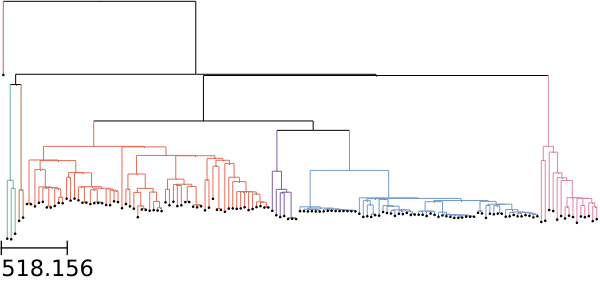

In [892]:
in_Tree = Mtb_151CI_Tree_V1.copy()
in_Tree.render("%%inline", w = 600, tree_style = ts_ColLin)

# Classify & Divide sets of GC Events based on Paralog Mapping results

In [893]:
GCE_All_DF = GRE_AnnoByMatch_DF
GCE_ABM_DF = GRE_AnnoByMatch_DF

# Seperate GC Event Info DF into GCEs WITH and WITHOUT paralogs
GCE_InPR_DF = GCE_All_DF.query("NumHmTargets > 0")
GCE_NotInPR_DF = GCE_All_DF.query("NumHmTargets == 0")

mGCE_DF = GRE_AnnoByMatch_DF.query("MappedEvent == True") #.query("Max_KmerMatch_ToHm > 0.5")
GCE_Mapped_DF = mGCE_DF

GCE_NotMapped_DF = GRE_AnnoByMatch_DF.query("MappedEvent == False") #.query("Max_KmerMatch_ToHm <= 0.5")

GCE_NotMapped_InPR_DF = GCE_NotMapped_DF.query("NumHmTargets > 0")

GCE_NotMapped_NotInPR_DF = GCE_NotMapped_DF.query("NumHmTargets == 0")


print("# of TOTAL detected events", GCE_All_DF.shape[0])

print("# of detected events IN a Paralog-Region:", GCE_InPR_DF.shape[0])
print("# of detected events NOT IN a Paralog-Region:", GCE_NotInPR_DF.shape[0])
print("")
print("# of mapped events", GCE_Mapped_DF.shape[0])
print("# of NOT MAPPED events:", GCE_NotMapped_DF.shape[0])

print("# of NOT MAPPED events IN a Paralog-Region:", GCE_NotMapped_InPR_DF.shape[0])
#print("# of NOT MAPPED events NOT IN a Paralog-Region:", GCE_NotMapped_NotInPR_DF.shape[0])


# of TOTAL detected events 324
# of detected events IN a Paralog-Region: 295
# of detected events NOT IN a Paralog-Region: 29

# of mapped events 217
# of NOT MAPPED events: 107
# of NOT MAPPED events IN a Paralog-Region: 78


# Begin Analysis

# Quick Comparison of PR region IDs between DFs

In [894]:
HmRegions_DonorAndEventCt_DF.shape

(200, 24)

In [895]:
HmPair_EventCt_DF.shape

(640, 51)

In [896]:
print(HmPair_EventCt_DF["Target_HmRegionNum"].nunique() )
print(HmPair_EventCt_DF["Query_HmRegionNum"].nunique() )

197
197


In [897]:
Set_T_Pair_Nums = set( HmPair_EventCt_DF["Target_HmRegionNum"].unique() )

In [898]:
Set_Q_Pair_Nums = set( HmPair_EventCt_DF["Query_HmRegionNum"].unique() )

In [899]:
Set_MgHmReg_PR_Nums = set( HmRegions_DonorAndEventCt_DF["HmRegion_Num"].unique() )

In [900]:
Set_T_Pair_Nums - Set_Q_Pair_Nums

{22, 92, 138}

In [901]:
Set_MgHmReg_PR_Nums - Set_T_Pair_Nums

{21, 93, 139}

In [902]:
HmRegions_DonorAndEventCt_DF.query("HmRegion_Num == 21")

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID,Norm_Donor_Count,N_Events_Mapped,N_Events_Putative,EventSkew,DonAccCt,EventSkew_Norm,GCE_FractionMapped,Num_PR_SNPs_All,Num_PR_SNPs_Unq
21,21,NC_000962.3,577285,577380,577332.5,95,Rv0487,0,1,0,0,21,PR_HmRegion_021,0,PR_Set_17,0.0,0,0,0.0,0.0,0.0,0.0,0,0


In [903]:
HmRegions_DonorAndEventCt_DF.query("HmRegion_Num == 93")

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID,Norm_Donor_Count,N_Events_Mapped,N_Events_Putative,EventSkew,DonAccCt,EventSkew_Norm,GCE_FractionMapped,Num_PR_SNPs_All,Num_PR_SNPs_Unq
93,93,NC_000962.3,2165476,2165583,2165529.5,107,PPE34,0,1,1,1,93,PR_HmRegion_093,0,PR_Set_51,0.0,0,0,0.0,0.0,0.0,0.0,0,0


In [904]:
HmRegions_DonorAndEventCt_DF.query("HmRegion_Num == 139")

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID,Norm_Donor_Count,N_Events_Mapped,N_Events_Putative,EventSkew,DonAccCt,EventSkew_Norm,GCE_FractionMapped,Num_PR_SNPs_All,Num_PR_SNPs_Unq
139,139,NC_000962.3,3113641,3113937,3113789.0,296,Rv2807,0,1,1,1,139,PR_HmRegion_139,0,PR_Set_60,0.0,0,0,0.0,0.0,0.0,0.0,0,0


# Manually inspect all events and mutations around the `vapC31-vapB31` and `vapB25-vapC25` loci

In [905]:
HmRegions_DonorAndEventCt_DF[  HmRegions_DonorAndEventCt_DF["Overlap_Genes"].str.contains("vapB") ] 

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID,Norm_Donor_Count,N_Events_Mapped,N_Events_Putative,EventSkew,DonAccCt,EventSkew_Norm,GCE_FractionMapped,Num_PR_SNPs_All,Num_PR_SNPs_Unq
9,9,NC_000962.3,332698,336379,334538.5,3681,"vapC25,vapB25,PE_PGRS3",0,4,4,4,9,PR_HmRegion_009,0,PR_Set_10,8.0,4,4,-4.0,12.0,-0.333333,1.0,960,838
32,32,NC_000962.3,838485,841665,840075.0,3180,"PE_PGRS10,vapB31,vapC31",0,8,8,8,32,PR_HmRegion_032,0,PR_Set_10,3.0,3,5,0.0,6.0,0.000000,0.6,2272,1272


In [906]:
HmPair_EventCt_DF[  HmPair_EventCt_DF["QueryOverlap_Genes"].str.contains("vapB") ] 

,Query_Name,Query_Start,Query_End,Strand,Target_Name,Target_Start,Target_End,Num_ResidueMatches,Aln_BlockLength,cs,SeqID,Target_Middle,Query_Middle,Dist_Middles,Query_Length,Target_Length,QueryOverlap_Genes,TargetOverlap_Genes,AlnOverlapsWithSelf,PerfectRepeat,Query_NOvrlap_Transposase,Target_NOvrlap_Transposase,QueryCoords,TargetCoords,QueryToTarget_ID,Query_Cluster,Query_Cluster_Start,Query_Cluster_End,Target_Cluster,Target_Cluster_Start,Target_Cluster_End,Query_HmRegionID,Target_HmRegionID,Query_HmRegionNum,Target_HmRegionNum,Query_NOvrlap_IS6110_Label,Target_NOvrlap_IS6110_Label,PR_SetID,EventsMapped,Dist_Bin,Dist_Bin_Mid,DonorGenes,AcceptorGenes,Normalized_EventsMapped,N_Ovrlap_pGCE_ToTarget,Aln_N_SNPs,SNPs_Per1kb_Aln,N_Ovrlap_ParalogAlns,Dist,Distance_kb,GC_Content
12,NC_000962.3,332698,336275,-,NC_000962.3,838485,841665,2601.0,3723.0,:3*ga:6*ga:10*gc*ga:1*gt*ac:4*ga:3+a:2-g:2*tc:...,0.698630,840075.0,334486.5,505588.5,3577,3180,"vapC25,vapB25,PE_PGRS3","PE_PGRS10,vapB31,vapC31",False,False,0,0,NC_000962.3:332698-336275,NC_000962.3:838485-841665,NC_000962.3:332698-336275;NC_000962.3:838485-8...,9,332698,336379,31,838485,841665,PR_HmRegion_009,PR_HmRegion_032,9,32,0,0,PR_Set_10,2.0,"(500000, 550000]",525000.0,"vapC25,vapB25,PE_PGRS3","PE_PGRS10,vapB31,vapC31",0.105263,5,433,116.304056,9,505588.5,505.5885,75.699466
40,NC_000962.3,838485,841665,-,NC_000962.3,332698,336275,2599.0,3725.0,:14*tg*tc:11*ag:8*ac:23*ag:27*tc:4*gt:2*gt:6*c...,0.697718,334486.5,840075.0,505588.5,3180,3577,"PE_PGRS10,vapB31,vapC31","vapC25,vapB25,PE_PGRS3",False,False,0,0,NC_000962.3:838485-841665,NC_000962.3:332698-336275,NC_000962.3:838485-841665;NC_000962.3:332698-3...,31,838485,841665,9,332698,336379,PR_HmRegion_032,PR_HmRegion_009,32,9,0,0,PR_Set_10,3.0,"(500000, 550000]",525000.0,"PE_PGRS10,vapB31,vapC31","vapC25,vapB25,PE_PGRS3",0.157895,4,433,116.241611,3,505588.5,505.5885,74.482951


In [907]:
HmPair_EventCt_DF[  HmPair_EventCt_DF["TargetOverlap_Genes"].str.contains("vapB") ] 

,Query_Name,Query_Start,Query_End,Strand,Target_Name,Target_Start,Target_End,Num_ResidueMatches,Aln_BlockLength,cs,SeqID,Target_Middle,Query_Middle,Dist_Middles,Query_Length,Target_Length,QueryOverlap_Genes,TargetOverlap_Genes,AlnOverlapsWithSelf,PerfectRepeat,Query_NOvrlap_Transposase,Target_NOvrlap_Transposase,QueryCoords,TargetCoords,QueryToTarget_ID,Query_Cluster,Query_Cluster_Start,Query_Cluster_End,Target_Cluster,Target_Cluster_Start,Target_Cluster_End,Query_HmRegionID,Target_HmRegionID,Query_HmRegionNum,Target_HmRegionNum,Query_NOvrlap_IS6110_Label,Target_NOvrlap_IS6110_Label,PR_SetID,EventsMapped,Dist_Bin,Dist_Bin_Mid,DonorGenes,AcceptorGenes,Normalized_EventsMapped,N_Ovrlap_pGCE_ToTarget,Aln_N_SNPs,SNPs_Per1kb_Aln,N_Ovrlap_ParalogAlns,Dist,Distance_kb,GC_Content
12,NC_000962.3,332698,336275,-,NC_000962.3,838485,841665,2601.0,3723.0,:3*ga:6*ga:10*gc*ga:1*gt*ac:4*ga:3+a:2-g:2*tc:...,0.698630,840075.0,334486.5,505588.5,3577,3180,"vapC25,vapB25,PE_PGRS3","PE_PGRS10,vapB31,vapC31",False,False,0,0,NC_000962.3:332698-336275,NC_000962.3:838485-841665,NC_000962.3:332698-336275;NC_000962.3:838485-8...,9,332698,336379,31,838485,841665,PR_HmRegion_009,PR_HmRegion_032,9,32,0,0,PR_Set_10,2.0,"(500000, 550000]",525000.0,"vapC25,vapB25,PE_PGRS3","PE_PGRS10,vapB31,vapC31",0.105263,5,433,116.304056,9,505588.5,505.5885,75.699466
40,NC_000962.3,838485,841665,-,NC_000962.3,332698,336275,2599.0,3725.0,:14*tg*tc:11*ag:8*ac:23*ag:27*tc:4*gt:2*gt:6*c...,0.697718,334486.5,840075.0,505588.5,3180,3577,"PE_PGRS10,vapB31,vapC31","vapC25,vapB25,PE_PGRS3",False,False,0,0,NC_000962.3:838485-841665,NC_000962.3:332698-336275,NC_000962.3:838485-841665;NC_000962.3:332698-3...,31,838485,841665,9,332698,336379,PR_HmRegion_032,PR_HmRegion_009,32,9,0,0,PR_Set_10,3.0,"(500000, 550000]",525000.0,"PE_PGRS10,vapB31,vapC31","vapC25,vapB25,PE_PGRS3",0.157895,4,433,116.241611,3,505588.5,505.5885,74.482951


In [908]:
subset_EventsDF_ForGenes(GRE_ABM_DF, "vapC25")

,seqname,start_1based,end_1based,strand,Parent_Node,Child_Node,neg_log_likelihood,snp_count,taxa_List,start_0based,CenterOfRegion,EventLen,Lineage,Num_Tips_Downstream,Overlap_Genes,Overlap_Gene_RvIDs,EventID,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,Overlap_HHRs,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMap_ParalogReg,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMap_LocalRepeat,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmapRegion,LenOfTaxaList,IsTermNode,Freq_SNP_FoundInAnyPR,NumHmTargets,NumHm_AtMaxKmerMatch,Top_KmerMatch_HomologTarIDs,Top_KmerMatch_HomologGeneIDs,Max_KmerMatch_ToHm,DistToHm_TopKmatch,TotalKmers_Eval,NumHm_AtMaxSNPMatch,Top_SNPMatch_HomologTarIDs,Top_SNPMatch_HomologGeneIDs,Max_SNPMatch_ToHm,DistToHm_TopSNPmatch,MappedEvent,N_NucDivHotSpots
32,NC_000962.3,332726,332916,.,Node_17,TB3334,946.590720,4,[TB3334],332725,332820.5,191,lineage4,0,vapC25,Rv0277c,Event_033,False,False,False,True,PR_HmRegion_009,1,1,0,0,0,0,1,1,1,True,0.0,1,1,"PE_PGRS10,vapB31,vapC31-H37Rv-838485-841665","PE_PGRS10,vapB31,vapC31",1.0000,507254.5,38,1,"PE_PGRS10,vapB31,vapC31-H37Rv-838485-841665","PE_PGRS10,vapB31,vapC31",1.0,507254.5,True,0
33,NC_000962.3,332726,333086,.,Node_144,mada_1-10,1590.558219,10,[mada_1-10],332725,332905.5,361,lineage1,0,vapC25,Rv0277c,Event_034,False,False,False,True,PR_HmRegion_009,1,1,0,0,0,0,1,1,1,True,0.1,1,1,"PE_PGRS10,vapB31,vapC31-H37Rv-838485-841665","PE_PGRS10,vapB31,vapC31",0.8191,507169.5,94,1,"PE_PGRS10,vapB31,vapC31-H37Rv-838485-841665","PE_PGRS10,vapB31,vapC31",1.0,507169.5,True,0


In [909]:
subset_EventsDF_ForGenes(GRE_ABM_DF, "vapC31")

,seqname,start_1based,end_1based,strand,Parent_Node,Child_Node,neg_log_likelihood,snp_count,taxa_List,start_0based,CenterOfRegion,EventLen,Lineage,Num_Tips_Downstream,Overlap_Genes,Overlap_Gene_RvIDs,EventID,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,Overlap_HHRs,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMap_ParalogReg,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMap_LocalRepeat,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmapRegion,LenOfTaxaList,IsTermNode,Freq_SNP_FoundInAnyPR,NumHmTargets,NumHm_AtMaxKmerMatch,Top_KmerMatch_HomologTarIDs,Top_KmerMatch_HomologGeneIDs,Max_KmerMatch_ToHm,DistToHm_TopKmatch,TotalKmers_Eval,NumHm_AtMaxSNPMatch,Top_SNPMatch_HomologTarIDs,Top_SNPMatch_HomologGeneIDs,Max_SNPMatch_ToHm,DistToHm_TopSNPmatch,MappedEvent,N_NucDivHotSpots
58,NC_000962.3,841377,841651,.,Node_27,Node_5,1591.478718,6,"[mada_2-31, mada_1-41]",841376,841513.5,275,lineage4,2,vapC31,Rv0749,Event_059,False,False,False,True,PR_HmRegion_032,1,1,0,0,0,0,1,1,2,False,0.0,1,1,"vapC25,vapB25,PE_PGRS3-H37Rv-332698-336275","vapC25,vapB25,PE_PGRS3",0.9565,507027.0,46,1,"vapC25,vapB25,PE_PGRS3-H37Rv-332698-336275","vapC25,vapB25,PE_PGRS3",1.0,507027.0,True,0
59,NC_000962.3,841377,841651,.,Node_53,mada_123,691.198422,10,[mada_123],841376,841513.5,275,lineage4,0,vapC31,Rv0749,Event_060,False,False,False,True,PR_HmRegion_032,1,1,0,0,0,0,1,1,1,True,0.0,1,1,"vapC25,vapB25,PE_PGRS3-H37Rv-332698-336275","vapC25,vapB25,PE_PGRS3",0.9079,507027.0,76,1,"vapC25,vapB25,PE_PGRS3-H37Rv-332698-336275","vapC25,vapB25,PE_PGRS3",1.0,507027.0,True,0


In [910]:
subset_EventsDF_ForGenes(GRE_ABM_DF, "PE_PGRS3")

,seqname,start_1based,end_1based,strand,Parent_Node,Child_Node,neg_log_likelihood,snp_count,taxa_List,start_0based,CenterOfRegion,EventLen,Lineage,Num_Tips_Downstream,Overlap_Genes,Overlap_Gene_RvIDs,EventID,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,Overlap_HHRs,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMap_ParalogReg,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMap_LocalRepeat,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmapRegion,LenOfTaxaList,IsTermNode,Freq_SNP_FoundInAnyPR,NumHmTargets,NumHm_AtMaxKmerMatch,Top_KmerMatch_HomologTarIDs,Top_KmerMatch_HomologGeneIDs,Max_KmerMatch_ToHm,DistToHm_TopKmatch,TotalKmers_Eval,NumHm_AtMaxSNPMatch,Top_SNPMatch_HomologTarIDs,Top_SNPMatch_HomologGeneIDs,Max_SNPMatch_ToHm,DistToHm_TopSNPmatch,MappedEvent,N_NucDivHotSpots
34,NC_000962.3,333406,333441,.,Node_34,M0010874_7,612.115174,7,[M0010874_7],333405,333423.0,36,lineage4,0,"vapB25,PE_PGRS3","Rv0277A,Rv0278c",Event_035,False,True,False,False,PR_HmRegion_009,1,1,0,0,0,0,0,0,1,True,0.571429,1,1,"PE_PGRS10,vapB31,vapC31-H37Rv-838485-841665","PE_PGRS10,vapB31,vapC31",1.0,506652.0,40,1,"PE_PGRS10,vapB31,vapC31-H37Rv-838485-841665","PE_PGRS10,vapB31,vapC31",1.0,506652.0,True,0
35,NC_000962.3,334552,334577,.,Node_15,Node_14,610.509286,6,"[02_R1708, 02_R0894]",334551,334564.0,26,lineage4,2,PE_PGRS3,Rv0278c,Event_036,False,True,False,False,"PR_HmRegion_009,LR_HmRegion_000",3,1,1,1,1,1,1,1,2,False,0.000000,2,1,PE_PGRS4-H37Rv-336565-339142,PE_PGRS4,1.0,3289.5,24,1,PE_PGRS4-H37Rv-336565-339142,PE_PGRS4,1.0,3289.5,True,0


In [911]:
subset_EventsDF_ForGenes(GRE_ABM_DF, "PE_PGRS10")

,seqname,start_1based,end_1based,strand,Parent_Node,Child_Node,neg_log_likelihood,snp_count,taxa_List,start_0based,CenterOfRegion,EventLen,Lineage,Num_Tips_Downstream,Overlap_Genes,Overlap_Gene_RvIDs,EventID,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,Overlap_HHRs,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMap_ParalogReg,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMap_LocalRepeat,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmapRegion,LenOfTaxaList,IsTermNode,Freq_SNP_FoundInAnyPR,NumHmTargets,NumHm_AtMaxKmerMatch,Top_KmerMatch_HomologTarIDs,Top_KmerMatch_HomologGeneIDs,Max_KmerMatch_ToHm,DistToHm_TopKmatch,TotalKmers_Eval,NumHm_AtMaxSNPMatch,Top_SNPMatch_HomologTarIDs,Top_SNPMatch_HomologGeneIDs,Max_SNPMatch_ToHm,DistToHm_TopSNPmatch,MappedEvent,N_NucDivHotSpots
55,NC_000962.3,838643,838702,.,Node_146,N0153,2031.217925,18,[N0153],838642,838672.0,60,lineage1,0,PE_PGRS10,Rv0747,Event_056,False,True,False,False,"PR_HmRegion_032,LR_HmRegion_006",3,1,1,1,0,0,1,1,1,True,0.277778,4,1,PE_PGRS4-H37Rv-336565-339038,PE_PGRS4,0.5857,500870.5,70,1,PE_PGRS4-H37Rv-336565-339038,PE_PGRS4,0.8333,500870.5,True,0
56,NC_000962.3,839098,839291,.,Node_4,Node_3,3211.012559,7,"[N1177, N1202, N0091]",839097,839194.0,194,lineage6,3,PE_PGRS10,Rv0747,Event_057,False,True,False,False,"PR_HmRegion_032,LR_HmRegion_006",6,1,1,1,1,1,1,1,3,False,0.285714,7,2,"vapC25,vapB25,PE_PGRS3-H37Rv-332698-336275-PE_...","vapC25,vapB25,PE_PGRS3-PE_PGRS3",0.2000,NaN,30,4,"vapC25,vapB25,PE_PGRS3-H37Rv-332698-336275-PE_...","vapC25,vapB25,PE_PGRS3-PE_PGRS3-PE_PGRS12,PE_P...",0.4286,NaN,False,0
57,NC_000962.3,839251,839291,.,Node_144,mada_1-10,1511.404547,5,[mada_1-10],839250,839270.5,41,lineage1,0,PE_PGRS10,Rv0747,Event_058,False,True,False,False,"PR_HmRegion_032,LR_HmRegion_006",6,1,1,1,1,1,1,1,1,True,0.200000,7,1,"PE_PGRS12,PE_PGRS13-H37Rv-925071-927514","PE_PGRS12,PE_PGRS13",0.4643,87022.0,28,2,"PE_PGRS12,PE_PGRS13-H37Rv-925071-927514-PE_PGR...","PE_PGRS12,PE_PGRS13-PE_PGRS13",0.6000,NaN,False,0


In [912]:
GRE_ABM_DF.head(4)

,seqname,start_1based,end_1based,strand,Parent_Node,Child_Node,neg_log_likelihood,snp_count,taxa_List,start_0based,CenterOfRegion,EventLen,Lineage,Num_Tips_Downstream,Overlap_Genes,Overlap_Gene_RvIDs,EventID,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,Overlap_HHRs,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMap_ParalogReg,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMap_LocalRepeat,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmapRegion,LenOfTaxaList,IsTermNode,Freq_SNP_FoundInAnyPR,NumHmTargets,NumHm_AtMaxKmerMatch,Top_KmerMatch_HomologTarIDs,Top_KmerMatch_HomologGeneIDs,Max_KmerMatch_ToHm,DistToHm_TopKmatch,TotalKmers_Eval,NumHm_AtMaxSNPMatch,Top_SNPMatch_HomologTarIDs,Top_SNPMatch_HomologGeneIDs,Max_SNPMatch_ToHm,DistToHm_TopSNPmatch,MappedEvent,N_NucDivHotSpots
0,NC_000962.3,103600,104478,.,Node_148,Node_133,1737.432787,10,"[mada_2-31, mada_1-41, MT_0080, mada_102, TB33...",103599,104038.5,879,NaN,130,"Rv0093c,Rv0094c","Rv0093c,Rv0094c",Event_001,False,False,True,False,PR_HmRegion_002,2,1,0,0,0,0,1,1,130,False,0.0,2,2,"Rv1587c,Rv1588c-H37Rv-1788513-1789865-Rv3466,R...","Rv1587c,Rv1588c-Rv3466,Rv3467",0.8608,NaN,79,2,"Rv1587c,Rv1588c-H37Rv-1788513-1789865-Rv3466,R...","Rv1587c,Rv1588c-Rv3466,Rv3467",0.0,NaN,True,2
1,NC_000962.3,103676,103930,.,Node_3,N1177,1950.228311,5,[N1177],103675,103802.5,255,lineage6,0,Rv0094c,Rv0094c,Event_002,False,False,True,False,PR_HmRegion_002,2,1,0,0,0,0,1,1,1,True,0.0,2,2,"Rv1587c,Rv1588c-H37Rv-1788513-1789865-Rv3466,R...","Rv1587c,Rv1588c-Rv3466,Rv3467",0.0000,NaN,46,2,"Rv1587c,Rv1588c-H37Rv-1788513-1789865-Rv3466,R...","Rv1587c,Rv1588c-Rv3466,Rv3467",0.0,NaN,False,1
2,NC_000962.3,103823,103846,.,Node_146,N0153,1944.165722,4,[N0153],103822,103834.0,24,lineage1,0,Rv0094c,Rv0094c,Event_003,False,False,True,False,PR_HmRegion_002,2,1,0,0,0,0,1,1,1,True,0.0,2,2,"Rv1587c,Rv1588c-H37Rv-1788513-1789865-Rv3466,R...","Rv1587c,Rv1588c-Rv3466,Rv3467",0.0000,NaN,28,2,"Rv1587c,Rv1588c-H37Rv-1788513-1789865-Rv3466,R...","Rv1587c,Rv1588c-Rv3466,Rv3467",0.0,NaN,False,1
3,NC_000962.3,103823,104065,.,Node_134,R27252,2067.461166,6,[R27252],103822,103943.5,243,lineage1,0,Rv0094c,Rv0094c,Event_004,False,False,True,False,PR_HmRegion_002,2,1,0,0,0,0,1,1,1,True,0.0,2,2,"Rv1587c,Rv1588c-H37Rv-1788513-1789865-Rv3466,R...","Rv1587c,Rv1588c-Rv3466,Rv3467",0.0000,NaN,50,2,"Rv1587c,Rv1588c-H37Rv-1788513-1789865-Rv3466,R...","Rv1587c,Rv1588c-Rv3466,Rv3467",0.0,NaN,False,2


/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomeviz_utils.py:1399: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events.loc[:, "__start1__"]     = events["start"].astype(float) + 1.0
/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomeviz_utils.py:1400: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events.loc[:, "__end1__"]       = events["end"].astype(float)
/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomev

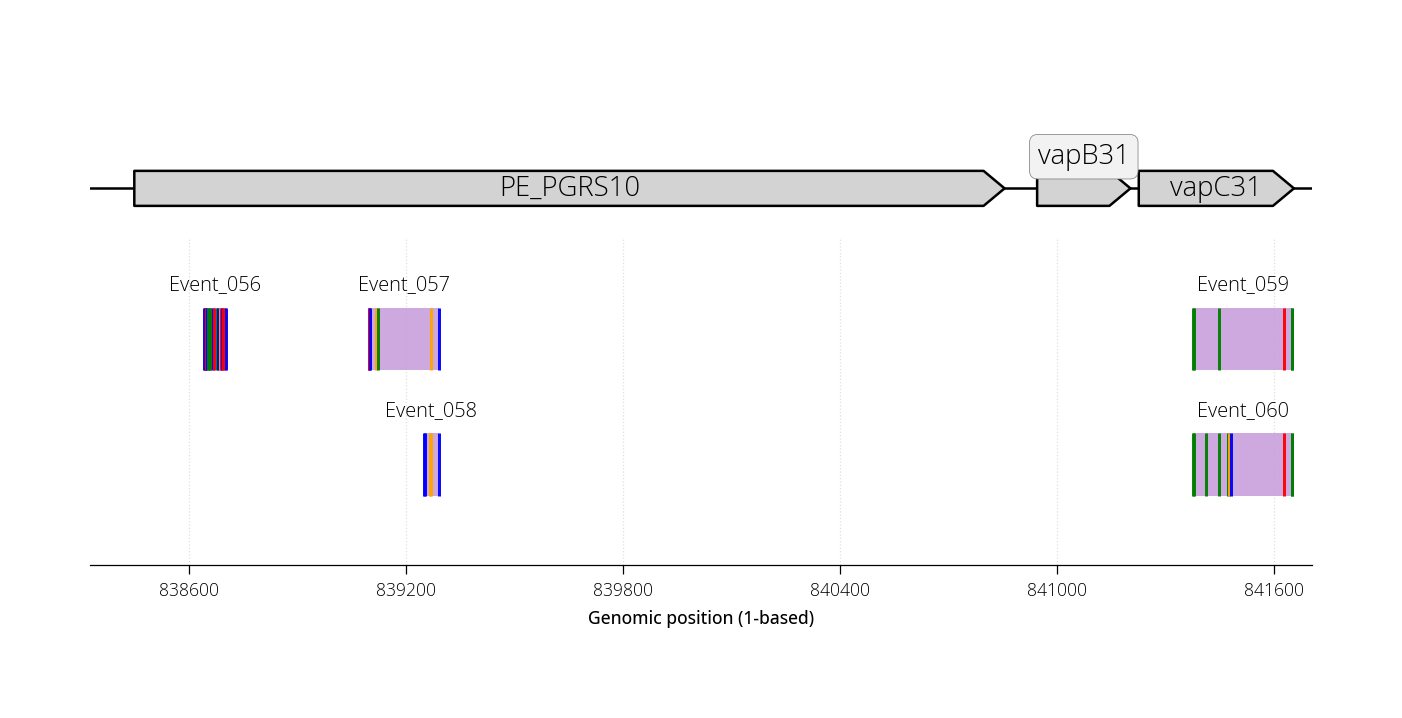

In [913]:
i_Symbol = "vapC31"

GeneInfo_DF = H37Rv_GenomeAnno_Genes_DF.query(f"Symbol == '{i_Symbol}'")
i_Gene_Start = GeneInfo_DF["Start"].values[0]
i_Gene_End = GeneInfo_DF["End"].values[0]
Viz_Start, Viz_End =  i_Gene_Start - 2900 , i_Gene_End + 50

fig, axes = plot_Anno_with_GCE_V3(Viz_Start, Viz_End,
                              in_Genome_Graphic_Record=Mtb_H37rv_Graphic_Record,
                              pGCE_df = GCE_All_DF,
                              figsize=(7, 3.2),
                              GCE_color_by_CDSeffect = False,
                              snps_df = Gub_SNPs_V2_DF)

fig.show()

(60402, 20) 370
(2893, 20) 9
vapC25,vapB25,PE_PGRS3-NC_000962.3:332698-336275 --- 838485 841665 3180
PE_PGRS3-NC_000962.3:333603-336275 --- 838485 840727 2242
PE_PGRS3-NC_000962.3:334966-335983 --- 839656 840754 1098
PE_PGRS4-NC_000962.3:336565-339038 --- 838485 840847 2362
PE_PGRS12,PE_PGRS13-NC_000962.3:925071-927514 --- 838571 840652 2081
PE_PGRS13-NC_000962.3:925780-927514 --- 838915 840652 1737
PE_PGRS52-NC_000962.3:3802143-3802720 --- 839696 840277 581
PE_PGRS54-NC_000962.3:3935705-3936438 --- 839158 839900 742
PE_PGRS57-NC_000962.3:3949543-3949970 --- 839167 839513 346


/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomeviz_utils.py:1399: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events.loc[:, "__start1__"]     = events["start"].astype(float) + 1.0
/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomeviz_utils.py:1400: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events.loc[:, "__end1__"]       = events["end"].astype(float)
/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomev

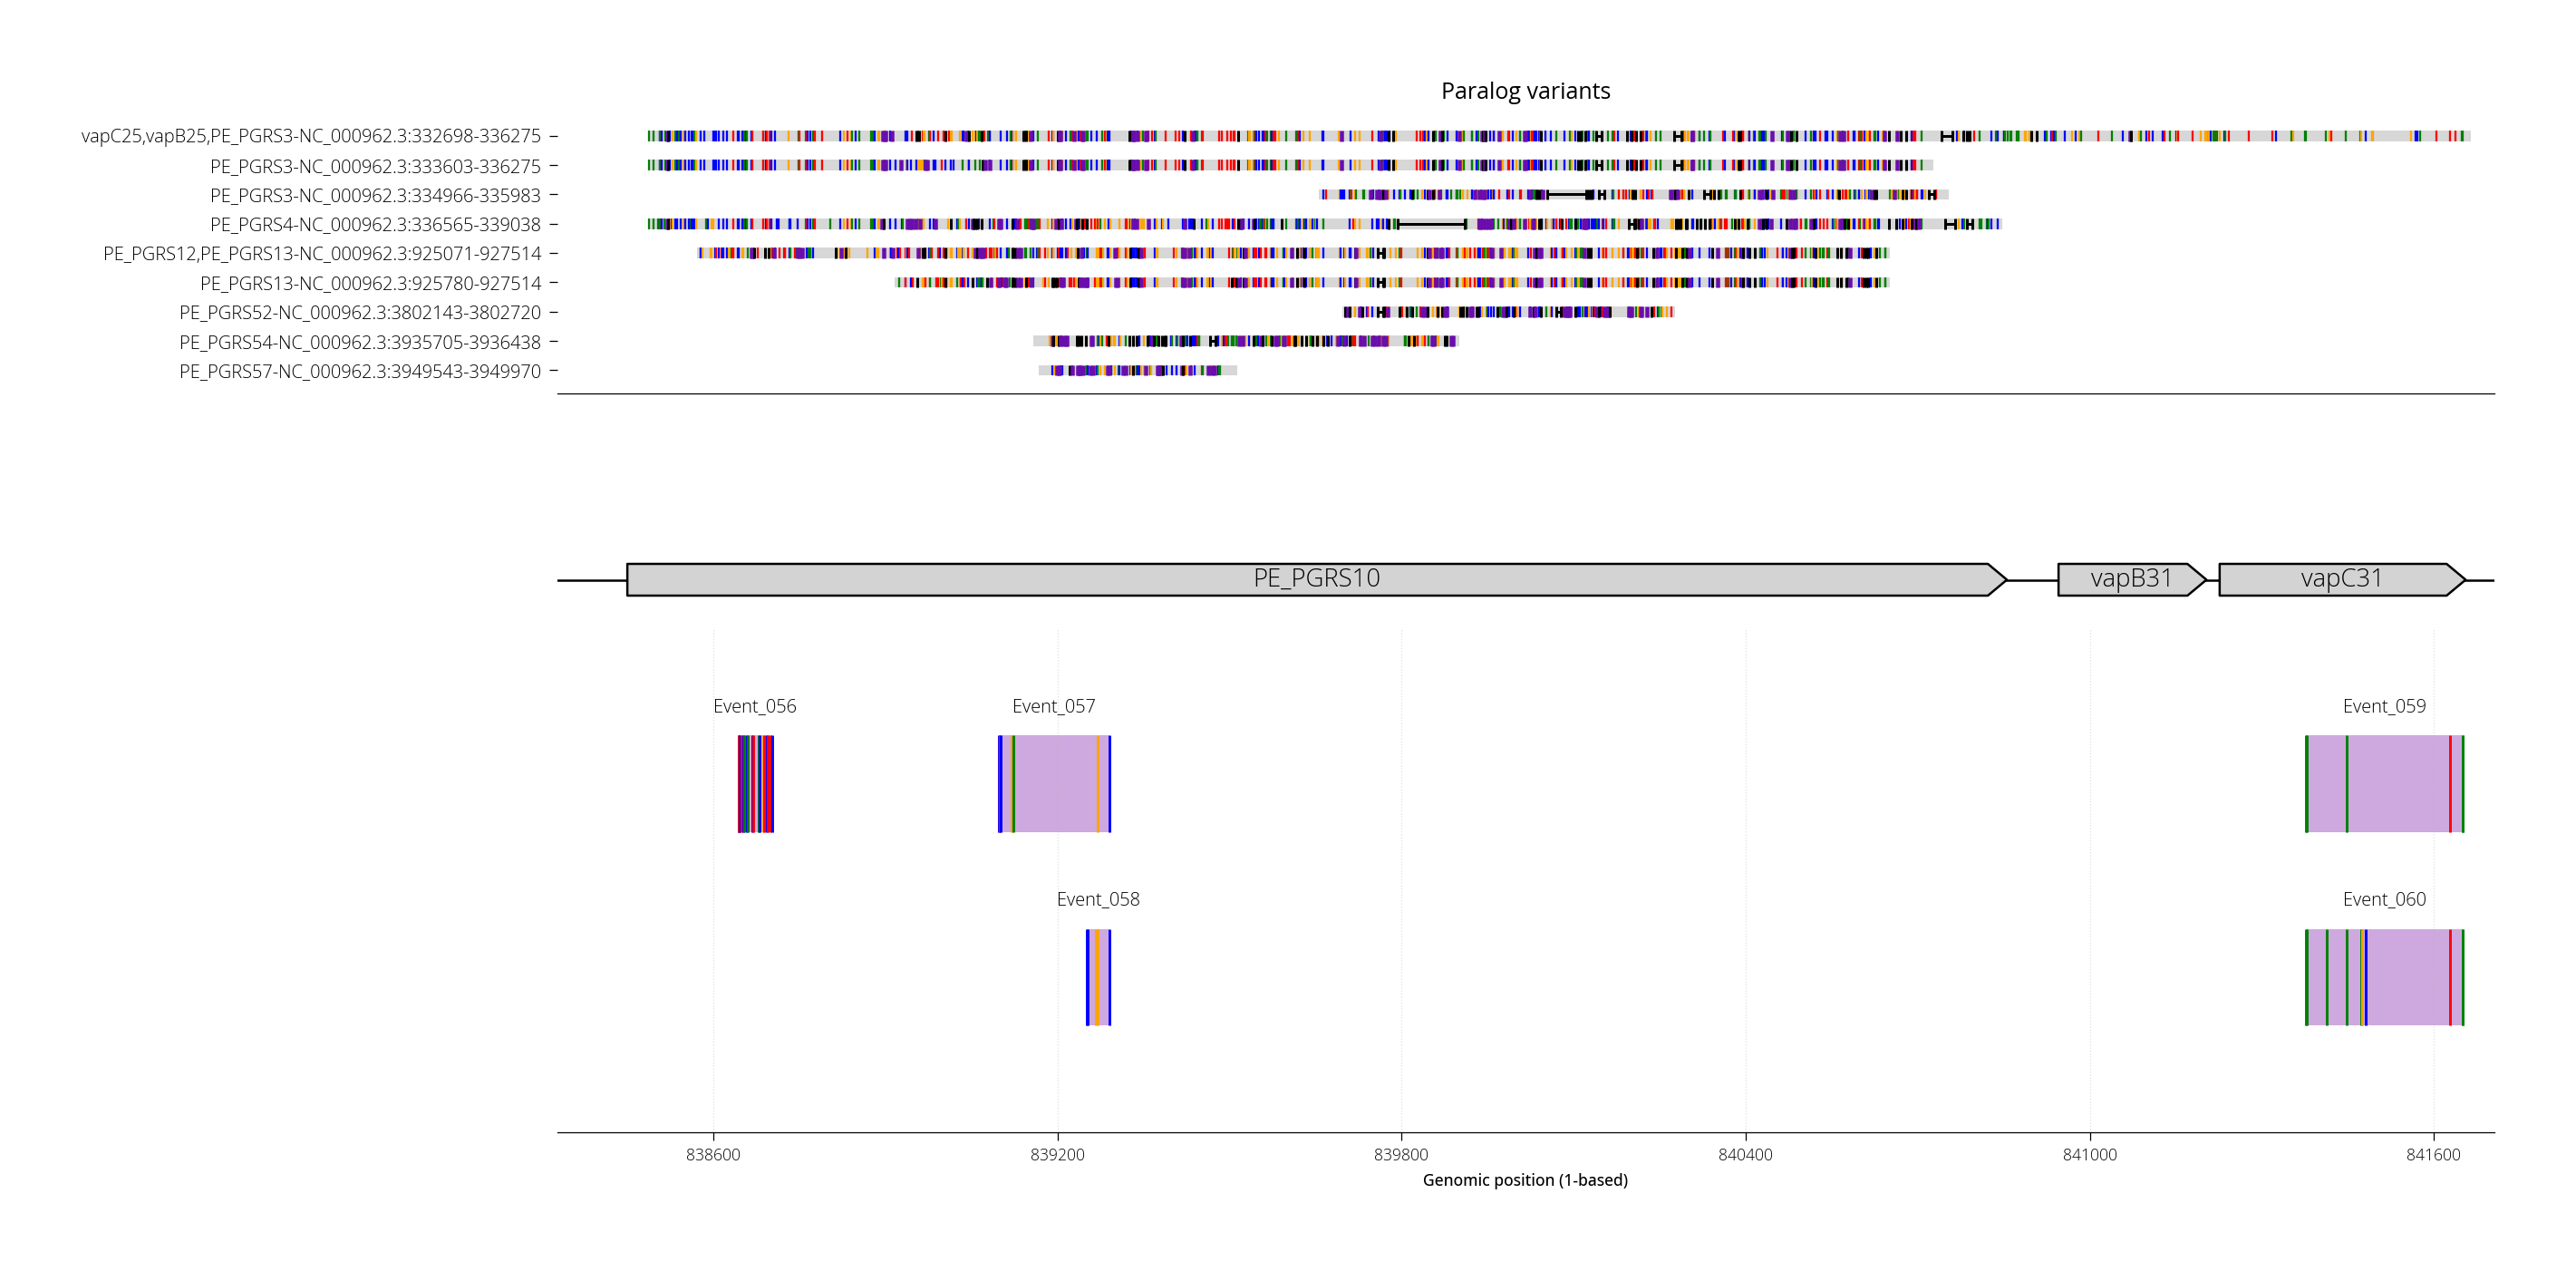

In [914]:
i_Symbol = "vapC31"

GeneInfo_DF = H37Rv_GenomeAnno_Genes_DF.query(f"Symbol == '{i_Symbol}'")
i_Gene_Start = GeneInfo_DF["Start"].values[0]
i_Gene_End = GeneInfo_DF["End"].values[0]
Viz_Start, Viz_End =  i_Gene_Start - 2900 , i_Gene_End + 50

fig, axes = plot_ParalogVars_Anno_with_GCE(Viz_Start, Viz_End,
    in_Genome_Graphic_Record = Mtb_H37rv_Graphic_Record,
    pGCE_df = GCE_All_DF,
    snps_df = Gub_SNPs_V2_DF,
    ParalogVar_df = Mtb_HM_Var_PR_DF,
    GCE_color_by_CDSeffect = False,
    ShowVariant_Legend = False,
)


/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomeviz_utils.py:1399: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events.loc[:, "__start1__"]     = events["start"].astype(float) + 1.0
/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomeviz_utils.py:1400: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events.loc[:, "__end1__"]       = events["end"].astype(float)
/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomev

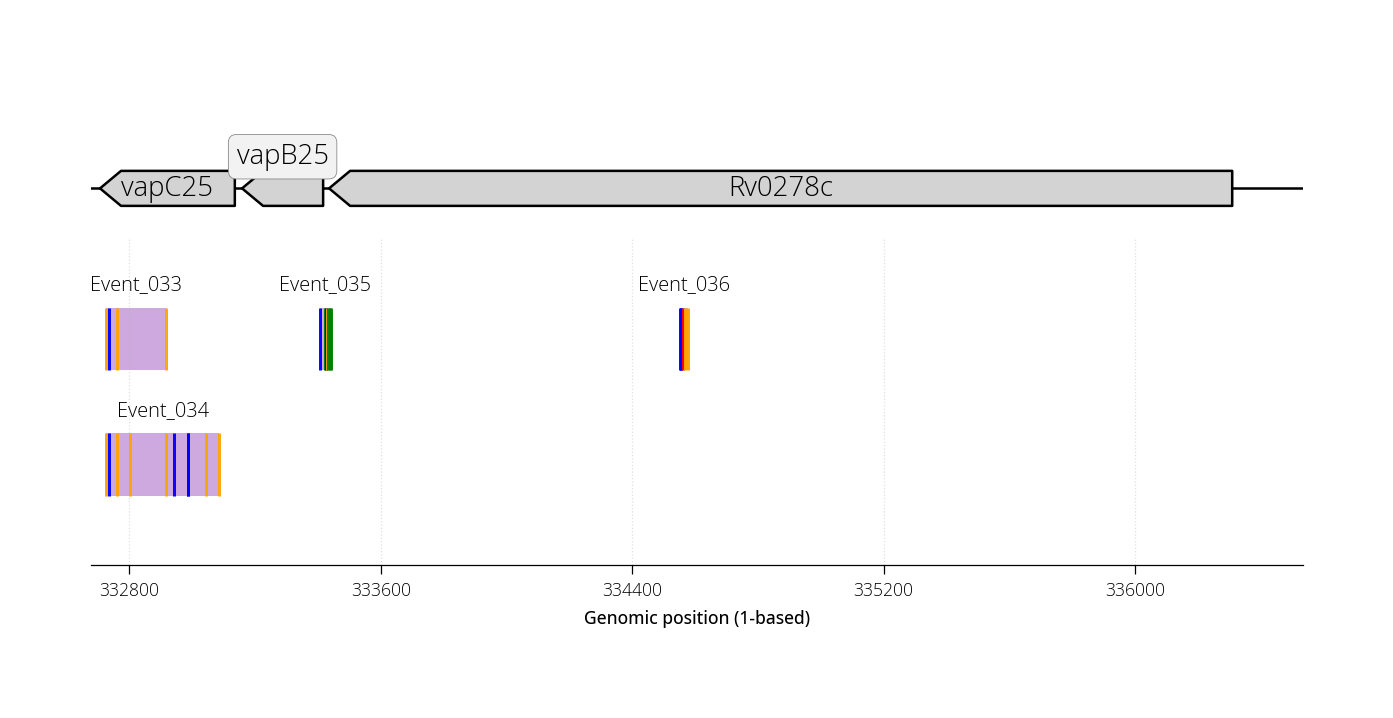

In [915]:
i_Symbol = "vapC25"

GeneInfo_DF = H37Rv_GenomeAnno_Genes_DF.query(f"Symbol == '{i_Symbol}'")
i_Gene_Start = GeneInfo_DF["Start"].values[0]
i_Gene_End = GeneInfo_DF["End"].values[0]
Viz_Start, Viz_End =  i_Gene_Start - 30 , i_Gene_End + 3400

fig, axes = plot_Anno_with_GCE_V3(Viz_Start, Viz_End,
                              in_Genome_Graphic_Record=Mtb_H37rv_Graphic_Record,
                              pGCE_df = GCE_All_DF,
                              figsize=(7, 3.2),
                              GCE_color_by_CDSeffect = False,
                              snps_df = Gub_SNPs_V2_DF)

fig.show()

(60402, 20) 370
(1155, 20) 3
PE_PGRS4-NC_000962.3:336565-339142 --- 333510 336379 2869
PE_PGRS10,vapB31,vapC31-NC_000962.3:838485-841665 --- 332698 336275 3577
PE_PGRS10-NC_000962.3:839656-840747 --- 334964 335983 1019


/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomeviz_utils.py:1399: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events.loc[:, "__start1__"]     = events["start"].astype(float) + 1.0
/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomeviz_utils.py:1400: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events.loc[:, "__end1__"]       = events["end"].astype(float)
/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomev

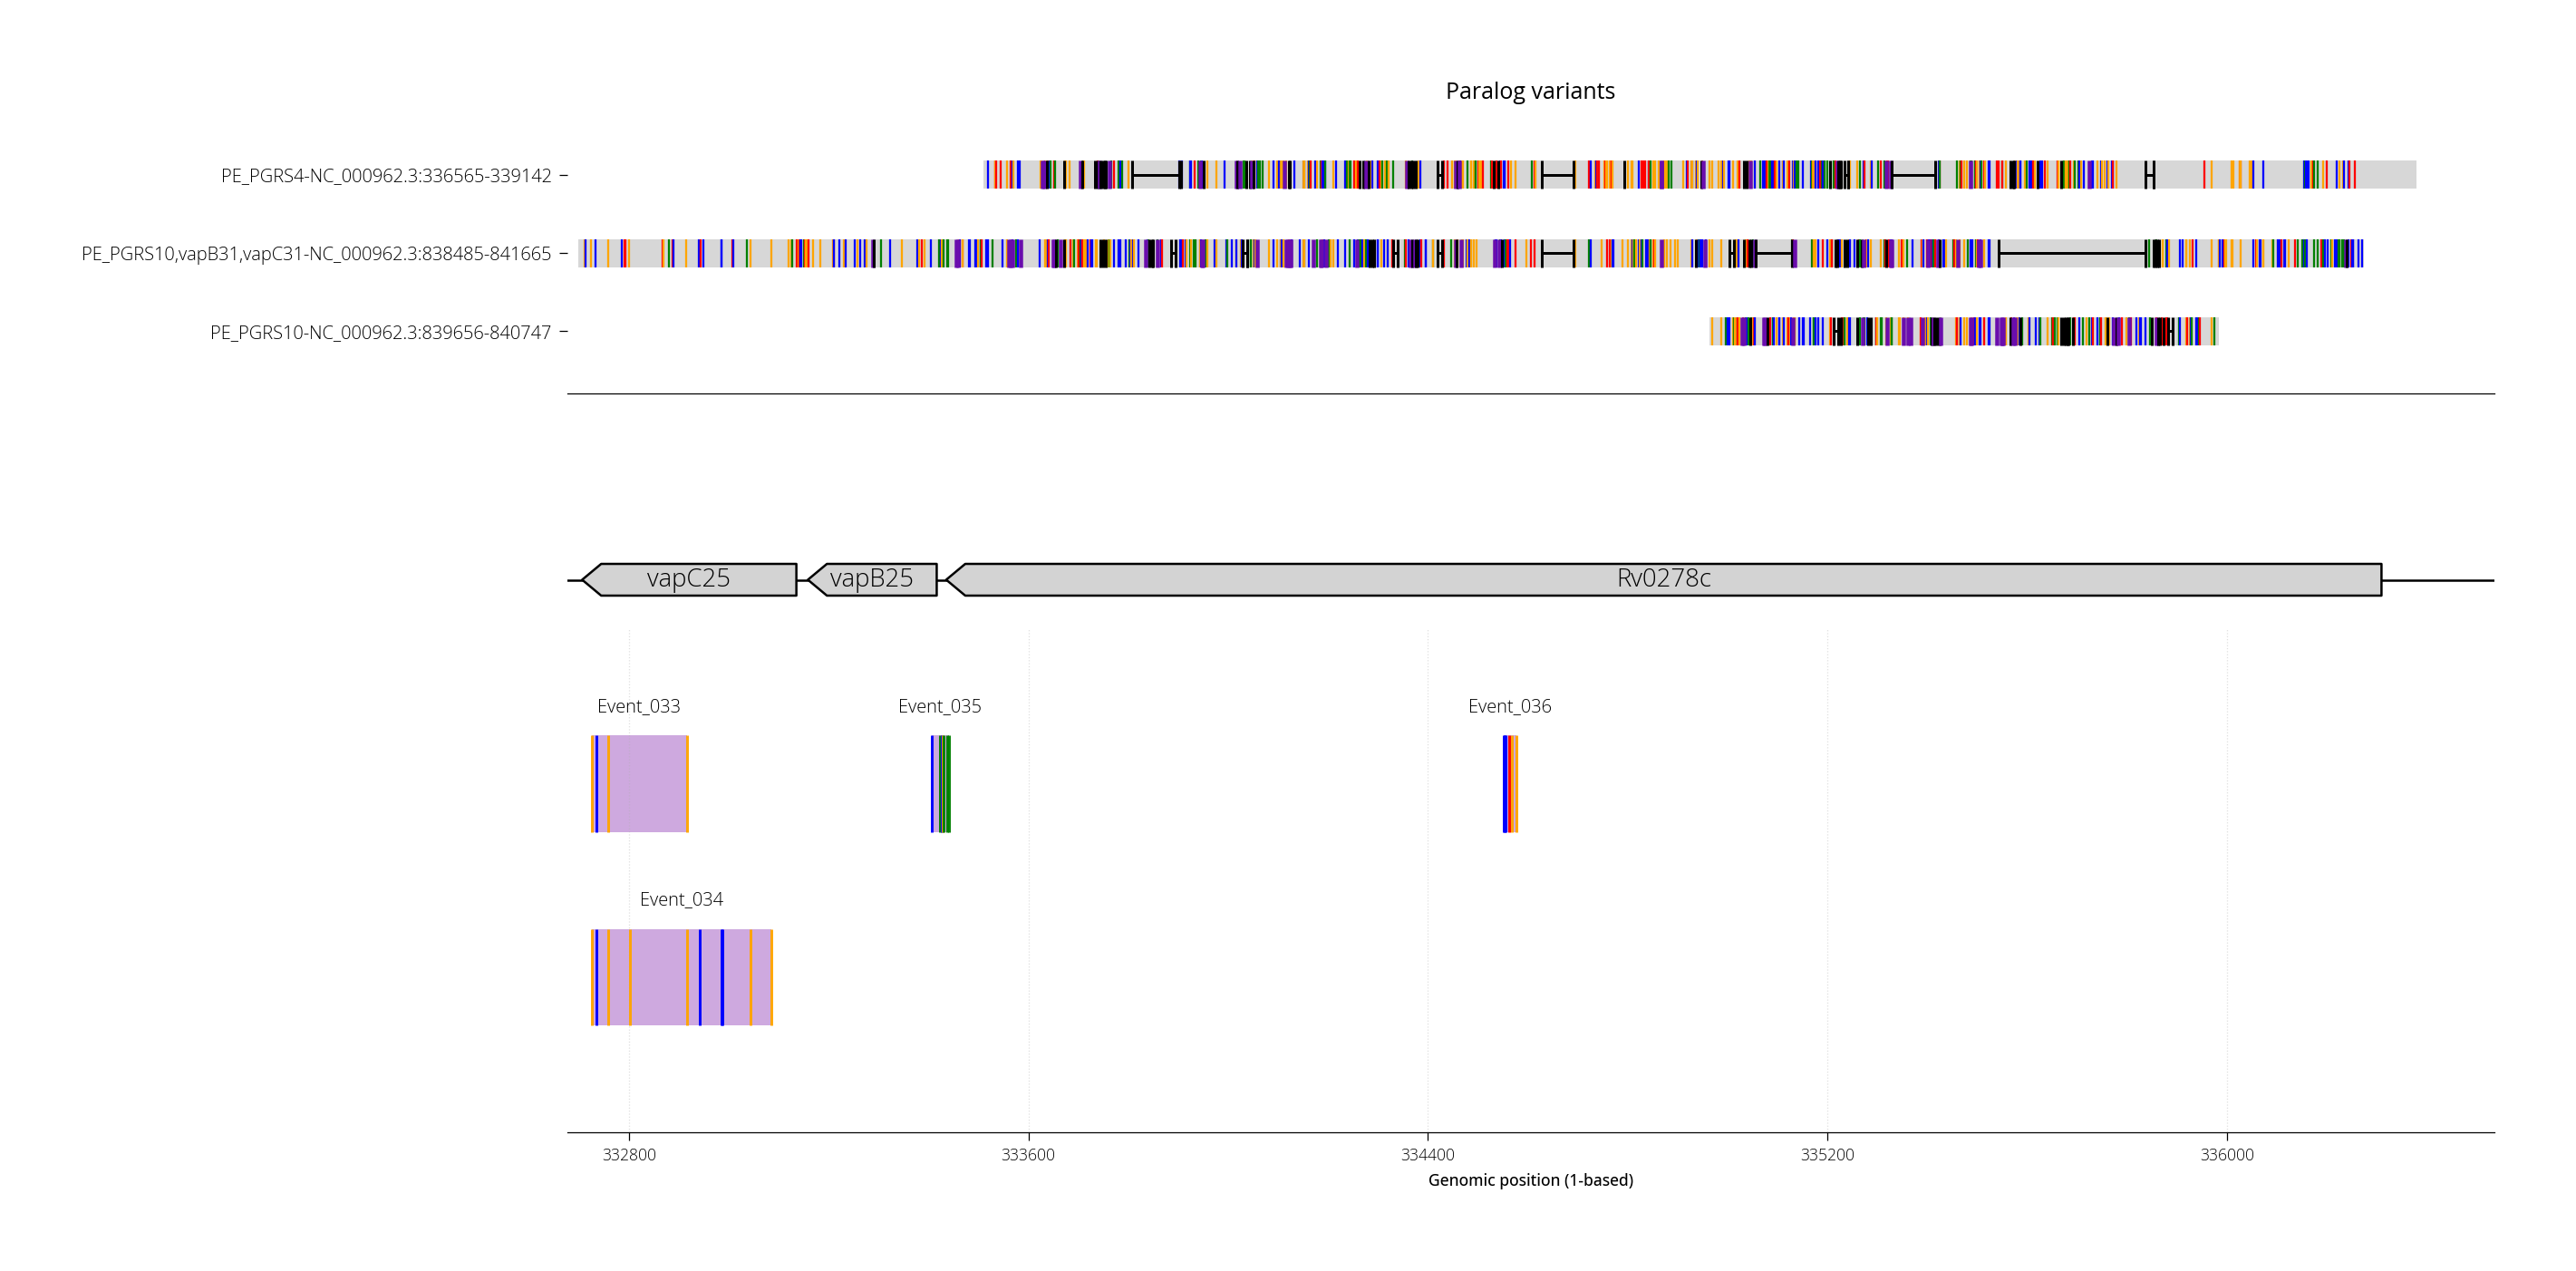

In [916]:
i_Symbol = "vapC25"

GeneInfo_DF = H37Rv_GenomeAnno_Genes_DF.query(f"Symbol == '{i_Symbol}'")
i_Gene_Start = GeneInfo_DF["Start"].values[0]
i_Gene_End = GeneInfo_DF["End"].values[0]
Viz_Start, Viz_End =  i_Gene_Start - 30 , i_Gene_End + 3400

fig, axes = plot_ParalogVars_Anno_with_GCE(Viz_Start, Viz_End,
    in_Genome_Graphic_Record = Mtb_H37rv_Graphic_Record,
    pGCE_df = GCE_All_DF,
    snps_df = Gub_SNPs_V2_DF,
    ParalogVar_df = Mtb_HM_Var_PR_DF,
    GCE_color_by_CDSeffect = False,
    ShowVariant_Legend = False,
)


In [917]:
subset_EventsDF_ForGenes(GRE_ABM_DF, "vapC25")

,seqname,start_1based,end_1based,strand,Parent_Node,Child_Node,neg_log_likelihood,snp_count,taxa_List,start_0based,CenterOfRegion,EventLen,Lineage,Num_Tips_Downstream,Overlap_Genes,Overlap_Gene_RvIDs,EventID,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,Overlap_HHRs,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMap_ParalogReg,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMap_LocalRepeat,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmapRegion,LenOfTaxaList,IsTermNode,Freq_SNP_FoundInAnyPR,NumHmTargets,NumHm_AtMaxKmerMatch,Top_KmerMatch_HomologTarIDs,Top_KmerMatch_HomologGeneIDs,Max_KmerMatch_ToHm,DistToHm_TopKmatch,TotalKmers_Eval,NumHm_AtMaxSNPMatch,Top_SNPMatch_HomologTarIDs,Top_SNPMatch_HomologGeneIDs,Max_SNPMatch_ToHm,DistToHm_TopSNPmatch,MappedEvent,N_NucDivHotSpots,chrom,start,end
32,NC_000962.3,332726,332916,.,Node_17,TB3334,946.590720,4,[TB3334],332725,332820.5,191,lineage4,0,vapC25,Rv0277c,Event_033,False,False,False,True,PR_HmRegion_009,1,1,0,0,0,0,1,1,1,True,0.0,1,1,"PE_PGRS10,vapB31,vapC31-H37Rv-838485-841665","PE_PGRS10,vapB31,vapC31",1.0000,507254.5,38,1,"PE_PGRS10,vapB31,vapC31-H37Rv-838485-841665","PE_PGRS10,vapB31,vapC31",1.0,507254.5,True,0,NC_000962.3,332725,332916
33,NC_000962.3,332726,333086,.,Node_144,mada_1-10,1590.558219,10,[mada_1-10],332725,332905.5,361,lineage1,0,vapC25,Rv0277c,Event_034,False,False,False,True,PR_HmRegion_009,1,1,0,0,0,0,1,1,1,True,0.1,1,1,"PE_PGRS10,vapB31,vapC31-H37Rv-838485-841665","PE_PGRS10,vapB31,vapC31",0.8191,507169.5,94,1,"PE_PGRS10,vapB31,vapC31-H37Rv-838485-841665","PE_PGRS10,vapB31,vapC31",1.0,507169.5,True,0,NC_000962.3,332725,333086


In [918]:
GCE_KeyCols = ["EventID", "snp_count", "Overlap_Genes", "Overlap_HHRs", "Top_KmerMatch_HomologGeneIDs", "MappedEvent"]


In [919]:
# Event_033 belongs to vapC31-vapB31 ('PR_HmRegion_032_B') to vapC25-vapB25 ('PR_HmRegion_009_B')
GCE_All_DF.query("EventID == 'Event_033'")[GCE_KeyCols]

,EventID,snp_count,Overlap_Genes,Overlap_HHRs,Top_KmerMatch_HomologGeneIDs,MappedEvent
32,Event_033,4,vapC25,PR_HmRegion_009,"PE_PGRS10,vapB31,vapC31",True


In [920]:
# Event_034 belongs to vapC31-vapB31 ('PR_HmRegion_032_B') to vapC25-vapB25 ('PR_HmRegion_009_B')
GCE_All_DF.query("EventID == 'Event_034'")[GCE_KeyCols]

,EventID,snp_count,Overlap_Genes,Overlap_HHRs,Top_KmerMatch_HomologGeneIDs,MappedEvent
33,Event_034,10,vapC25,PR_HmRegion_009,"PE_PGRS10,vapB31,vapC31",True


In [921]:
# Event_035 belongs to PE_PGRS10 ('PR_HmRegion_032') to PE_PGRS3 ('PR_HmRegion_009')
GCE_All_DF.query("EventID == 'Event_035'")[GCE_KeyCols]

,EventID,snp_count,Overlap_Genes,Overlap_HHRs,Top_KmerMatch_HomologGeneIDs,MappedEvent
34,Event_035,7,"vapB25,PE_PGRS3",PR_HmRegion_009,"PE_PGRS10,vapB31,vapC31",True


In [922]:
#Gub_SNPs_V2_DF.query("EventID == 'Event_035'")

In [923]:
# Event_037 belongs  to PGRS4 ('PR_HmRegion_010') to PE_PGRS3 ('PR_HmRegion_009')
GCE_All_DF.query("EventID == 'Event_036'")[GCE_KeyCols]

,EventID,snp_count,Overlap_Genes,Overlap_HHRs,Top_KmerMatch_HomologGeneIDs,MappedEvent
35,Event_036,6,PE_PGRS3,"PR_HmRegion_009,LR_HmRegion_000",PE_PGRS4,True


/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomeviz_utils.py:1399: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events.loc[:, "__start1__"]     = events["start"].astype(float) + 1.0
/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomeviz_utils.py:1400: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events.loc[:, "__end1__"]       = events["end"].astype(float)
/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomev

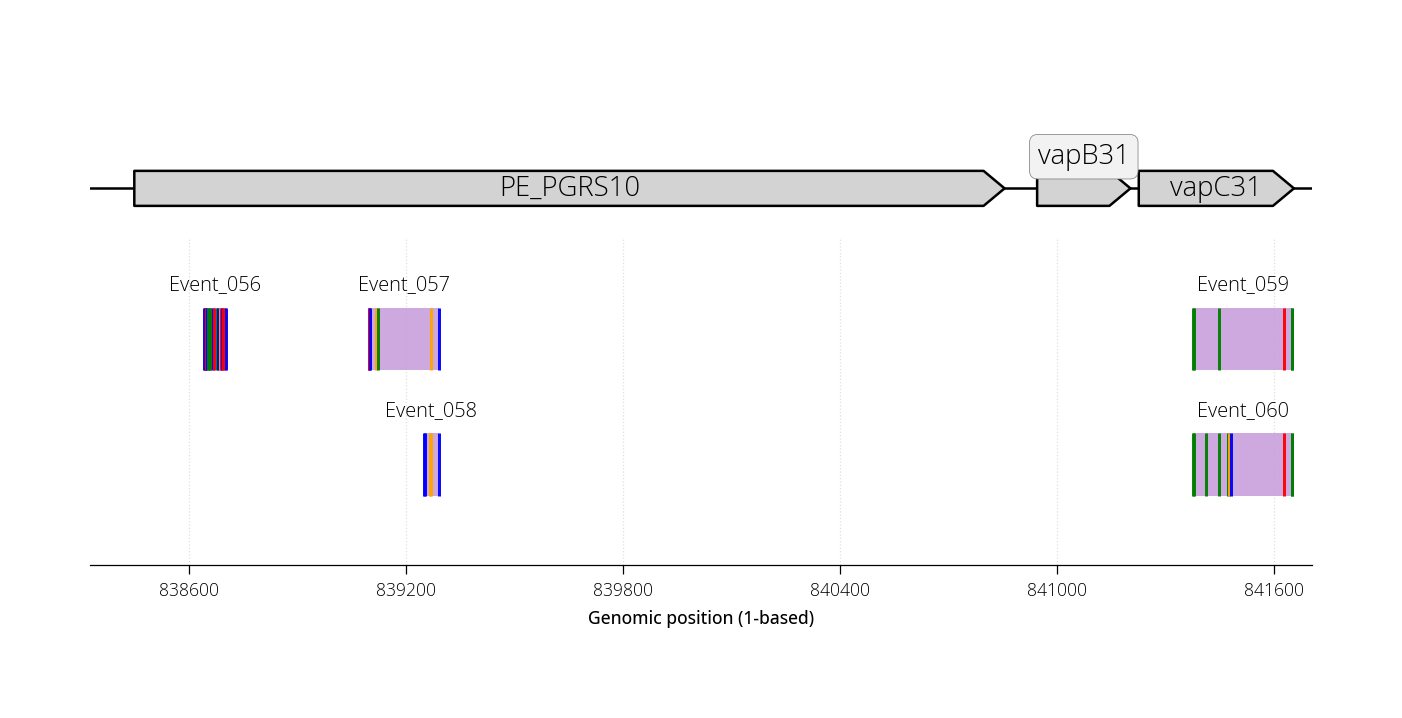

In [924]:
i_Symbol = "vapC31"

GeneInfo_DF = H37Rv_GenomeAnno_Genes_DF.query(f"Symbol == '{i_Symbol}'")
i_Gene_Start = GeneInfo_DF["Start"].values[0]
i_Gene_End = GeneInfo_DF["End"].values[0]
Viz_Start, Viz_End =  i_Gene_Start - 2900 , i_Gene_End + 50

fig, axes = plot_Anno_with_GCE_V3(Viz_Start, Viz_End,
                              in_Genome_Graphic_Record=Mtb_H37rv_Graphic_Record,
                              pGCE_df = GCE_All_DF,
                              figsize=(7, 3.2),
                              GCE_color_by_CDSeffect = False,
                              snps_df = Gub_SNPs_V2_DF)

fig.show()

In [925]:
# Event_056 belongs to PE_PGRS4 ('PR_HmRegion_010') to PE_PGRS10 ('PR_HmRegion_032')
GCE_All_DF.query("EventID == 'Event_056'")[GCE_KeyCols]

,EventID,snp_count,Overlap_Genes,Overlap_HHRs,Top_KmerMatch_HomologGeneIDs,MappedEvent
55,Event_056,18,PE_PGRS10,"PR_HmRegion_032,LR_HmRegion_006",PE_PGRS4,True


In [926]:
# Event_057 belongs to PE_PGRS10 ('PR_HmRegion_032'), NOT MAPPED THOUGH

GCE_All_DF.query("EventID == 'Event_057'")[GCE_KeyCols]

,EventID,snp_count,Overlap_Genes,Overlap_HHRs,Top_KmerMatch_HomologGeneIDs,MappedEvent
56,Event_057,7,PE_PGRS10,"PR_HmRegion_032,LR_HmRegion_006","vapC25,vapB25,PE_PGRS3-PE_PGRS3",False


In [927]:
# Event_058 belongs to PE_PGRS10 ('PR_HmRegion_032'), NOT MAPPED THOUGH

GCE_All_DF.query("EventID == 'Event_058'")[GCE_KeyCols]

,EventID,snp_count,Overlap_Genes,Overlap_HHRs,Top_KmerMatch_HomologGeneIDs,MappedEvent
57,Event_058,5,PE_PGRS10,"PR_HmRegion_032,LR_HmRegion_006","PE_PGRS12,PE_PGRS13",False


In [928]:
# Event_060 belongs to vapC25-vapB25 ('PR_HmRegion_009_B') to vapC31-vapB31 ('PR_HmRegion_032_B')

GCE_All_DF.query("EventID == 'Event_059'")[GCE_KeyCols]

,EventID,snp_count,Overlap_Genes,Overlap_HHRs,Top_KmerMatch_HomologGeneIDs,MappedEvent
58,Event_059,6,vapC31,PR_HmRegion_032,"vapC25,vapB25,PE_PGRS3",True


In [929]:
# Event_060 belongs to vapC25-vapB25 ('PR_HmRegion_009_B') to vapC31-vapB31 ('PR_HmRegion_032_B')
GCE_All_DF.query("EventID == 'Event_060'")[GCE_KeyCols]

,EventID,snp_count,Overlap_Genes,Overlap_HHRs,Top_KmerMatch_HomologGeneIDs,MappedEvent
59,Event_060,10,vapC31,PR_HmRegion_032,"vapC25,vapB25,PE_PGRS3",True


# Part X: Investigate `ParalogNetwork-10` - w/ vapBC gene paralogs + `PE-PGRS` paralogs

Goal is to split vapB31-C31 and vapB25-C25 into their own paralog network


#### Gameplan
```



```

In [930]:
HmMapRegs_ParaRegs_k19w19_DF.shape

(200, 15)

In [931]:
HmRegions_DonorAndEventCt_DF.shape

(200, 24)

In [932]:
HmPair_EventCt_DF.shape

(640, 51)

In [933]:
HmRegions_DonorAndEventCt_DF[  HmRegions_DonorAndEventCt_DF["Overlap_Genes"].str.contains("vapB") ] 

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID,Norm_Donor_Count,N_Events_Mapped,N_Events_Putative,EventSkew,DonAccCt,EventSkew_Norm,GCE_FractionMapped,Num_PR_SNPs_All,Num_PR_SNPs_Unq
9,9,NC_000962.3,332698,336379,334538.5,3681,"vapC25,vapB25,PE_PGRS3",0,4,4,4,9,PR_HmRegion_009,0,PR_Set_10,8.0,4,4,-4.0,12.0,-0.333333,1.0,960,838
32,32,NC_000962.3,838485,841665,840075.0,3180,"PE_PGRS10,vapB31,vapC31",0,8,8,8,32,PR_HmRegion_032,0,PR_Set_10,3.0,3,5,0.0,6.0,0.000000,0.6,2272,1272


In [934]:
HmPair_EventCt_DF[  HmPair_EventCt_DF["QueryOverlap_Genes"].str.contains("vapB") ] 

,Query_Name,Query_Start,Query_End,Strand,Target_Name,Target_Start,Target_End,Num_ResidueMatches,Aln_BlockLength,cs,SeqID,Target_Middle,Query_Middle,Dist_Middles,Query_Length,Target_Length,QueryOverlap_Genes,TargetOverlap_Genes,AlnOverlapsWithSelf,PerfectRepeat,Query_NOvrlap_Transposase,Target_NOvrlap_Transposase,QueryCoords,TargetCoords,QueryToTarget_ID,Query_Cluster,Query_Cluster_Start,Query_Cluster_End,Target_Cluster,Target_Cluster_Start,Target_Cluster_End,Query_HmRegionID,Target_HmRegionID,Query_HmRegionNum,Target_HmRegionNum,Query_NOvrlap_IS6110_Label,Target_NOvrlap_IS6110_Label,PR_SetID,EventsMapped,Dist_Bin,Dist_Bin_Mid,DonorGenes,AcceptorGenes,Normalized_EventsMapped,N_Ovrlap_pGCE_ToTarget,Aln_N_SNPs,SNPs_Per1kb_Aln,N_Ovrlap_ParalogAlns,Dist,Distance_kb,GC_Content
12,NC_000962.3,332698,336275,-,NC_000962.3,838485,841665,2601.0,3723.0,:3*ga:6*ga:10*gc*ga:1*gt*ac:4*ga:3+a:2-g:2*tc:...,0.698630,840075.0,334486.5,505588.5,3577,3180,"vapC25,vapB25,PE_PGRS3","PE_PGRS10,vapB31,vapC31",False,False,0,0,NC_000962.3:332698-336275,NC_000962.3:838485-841665,NC_000962.3:332698-336275;NC_000962.3:838485-8...,9,332698,336379,31,838485,841665,PR_HmRegion_009,PR_HmRegion_032,9,32,0,0,PR_Set_10,2.0,"(500000, 550000]",525000.0,"vapC25,vapB25,PE_PGRS3","PE_PGRS10,vapB31,vapC31",0.105263,5,433,116.304056,9,505588.5,505.5885,75.699466
40,NC_000962.3,838485,841665,-,NC_000962.3,332698,336275,2599.0,3725.0,:14*tg*tc:11*ag:8*ac:23*ag:27*tc:4*gt:2*gt:6*c...,0.697718,334486.5,840075.0,505588.5,3180,3577,"PE_PGRS10,vapB31,vapC31","vapC25,vapB25,PE_PGRS3",False,False,0,0,NC_000962.3:838485-841665,NC_000962.3:332698-336275,NC_000962.3:838485-841665;NC_000962.3:332698-3...,31,838485,841665,9,332698,336379,PR_HmRegion_032,PR_HmRegion_009,32,9,0,0,PR_Set_10,3.0,"(500000, 550000]",525000.0,"PE_PGRS10,vapB31,vapC31","vapC25,vapB25,PE_PGRS3",0.157895,4,433,116.241611,3,505588.5,505.5885,74.482951


In [935]:
HmPair_EventCt_DF[  HmPair_EventCt_DF["TargetOverlap_Genes"].str.contains("vapB") ] 

,Query_Name,Query_Start,Query_End,Strand,Target_Name,Target_Start,Target_End,Num_ResidueMatches,Aln_BlockLength,cs,SeqID,Target_Middle,Query_Middle,Dist_Middles,Query_Length,Target_Length,QueryOverlap_Genes,TargetOverlap_Genes,AlnOverlapsWithSelf,PerfectRepeat,Query_NOvrlap_Transposase,Target_NOvrlap_Transposase,QueryCoords,TargetCoords,QueryToTarget_ID,Query_Cluster,Query_Cluster_Start,Query_Cluster_End,Target_Cluster,Target_Cluster_Start,Target_Cluster_End,Query_HmRegionID,Target_HmRegionID,Query_HmRegionNum,Target_HmRegionNum,Query_NOvrlap_IS6110_Label,Target_NOvrlap_IS6110_Label,PR_SetID,EventsMapped,Dist_Bin,Dist_Bin_Mid,DonorGenes,AcceptorGenes,Normalized_EventsMapped,N_Ovrlap_pGCE_ToTarget,Aln_N_SNPs,SNPs_Per1kb_Aln,N_Ovrlap_ParalogAlns,Dist,Distance_kb,GC_Content
12,NC_000962.3,332698,336275,-,NC_000962.3,838485,841665,2601.0,3723.0,:3*ga:6*ga:10*gc*ga:1*gt*ac:4*ga:3+a:2-g:2*tc:...,0.698630,840075.0,334486.5,505588.5,3577,3180,"vapC25,vapB25,PE_PGRS3","PE_PGRS10,vapB31,vapC31",False,False,0,0,NC_000962.3:332698-336275,NC_000962.3:838485-841665,NC_000962.3:332698-336275;NC_000962.3:838485-8...,9,332698,336379,31,838485,841665,PR_HmRegion_009,PR_HmRegion_032,9,32,0,0,PR_Set_10,2.0,"(500000, 550000]",525000.0,"vapC25,vapB25,PE_PGRS3","PE_PGRS10,vapB31,vapC31",0.105263,5,433,116.304056,9,505588.5,505.5885,75.699466
40,NC_000962.3,838485,841665,-,NC_000962.3,332698,336275,2599.0,3725.0,:14*tg*tc:11*ag:8*ac:23*ag:27*tc:4*gt:2*gt:6*c...,0.697718,334486.5,840075.0,505588.5,3180,3577,"PE_PGRS10,vapB31,vapC31","vapC25,vapB25,PE_PGRS3",False,False,0,0,NC_000962.3:838485-841665,NC_000962.3:332698-336275,NC_000962.3:838485-841665;NC_000962.3:332698-3...,31,838485,841665,9,332698,336379,PR_HmRegion_032,PR_HmRegion_009,32,9,0,0,PR_Set_10,3.0,"(500000, 550000]",525000.0,"PE_PGRS10,vapB31,vapC31","vapC25,vapB25,PE_PGRS3",0.157895,4,433,116.241611,3,505588.5,505.5885,74.482951


In [936]:
HmPair_EventCt_DF[  HmPair_EventCt_DF["QueryOverlap_Genes"].str.contains("PGRS10") ] 

,Query_Name,Query_Start,Query_End,Strand,Target_Name,Target_Start,Target_End,Num_ResidueMatches,Aln_BlockLength,cs,SeqID,Target_Middle,Query_Middle,Dist_Middles,Query_Length,Target_Length,QueryOverlap_Genes,TargetOverlap_Genes,AlnOverlapsWithSelf,PerfectRepeat,Query_NOvrlap_Transposase,Target_NOvrlap_Transposase,QueryCoords,TargetCoords,QueryToTarget_ID,Query_Cluster,Query_Cluster_Start,Query_Cluster_End,Target_Cluster,Target_Cluster_Start,Target_Cluster_End,Query_HmRegionID,Target_HmRegionID,Query_HmRegionNum,Target_HmRegionNum,Query_NOvrlap_IS6110_Label,Target_NOvrlap_IS6110_Label,PR_SetID,EventsMapped,Dist_Bin,Dist_Bin_Mid,DonorGenes,AcceptorGenes,Normalized_EventsMapped,N_Ovrlap_pGCE_ToTarget,Aln_N_SNPs,SNPs_Per1kb_Aln,N_Ovrlap_ParalogAlns,Dist,Distance_kb,GC_Content
39,NC_000962.3,838485,840847,-,NC_000962.3,336565,339038,1734.0,2732.0,:6*gc:11*ga:4*tg*gc:1*tg:8*tc:2*tc:9+gccgctggg...,0.634700,337801.5,839666.0,501864.5,2362,2473,PE_PGRS10,PE_PGRS4,False,False,0,0,NC_000962.3:838485-840847,NC_000962.3:336565-339038,NC_000962.3:838485-840847;NC_000962.3:336565-3...,31,838485,841665,10,336565,339142,PR_HmRegion_032,PR_HmRegion_010,32,10,0,0,PR_Set_10,0.0,"(500000, 550000]",525000.0,PE_PGRS10,PE_PGRS4,0.000000,10,369,135.065886,2,501864.5,501.8645,78.092158
40,NC_000962.3,838485,841665,-,NC_000962.3,332698,336275,2599.0,3725.0,:14*tg*tc:11*ag:8*ac:23*ag:27*tc:4*gt:2*gt:6*c...,0.697718,334486.5,840075.0,505588.5,3180,3577,"PE_PGRS10,vapB31,vapC31","vapC25,vapB25,PE_PGRS3",False,False,0,0,NC_000962.3:838485-841665,NC_000962.3:332698-336275,NC_000962.3:838485-841665;NC_000962.3:332698-3...,31,838485,841665,9,332698,336379,PR_HmRegion_032,PR_HmRegion_009,32,9,0,0,PR_Set_10,3.0,"(500000, 550000]",525000.0,"PE_PGRS10,vapB31,vapC31","vapC25,vapB25,PE_PGRS3",0.157895,4,433,116.241611,3,505588.5,505.5885,74.482951
41,NC_000962.3,838571,840652,+,NC_000962.3,925071,927514,1599.0,2541.0,:6*cg*ct:2*gc:12*ga:1*ga:5*ct:2*tg:3*ct:4*tc*t...,0.629280,926292.5,839611.5,86681.0,2081,2443,PE_PGRS10,"PE_PGRS12,PE_PGRS13",False,False,0,0,NC_000962.3:838571-840652,NC_000962.3:925071-927514,NC_000962.3:838571-840652;NC_000962.3:925071-9...,31,838485,841665,36,925071,927514,PR_HmRegion_032,PR_HmRegion_037,32,37,0,0,PR_Set_10,0.0,"(50000, 100000]",75000.0,PE_PGRS10,"PE_PGRS12,PE_PGRS13",0.000000,1,384,151.121606,3,86681.0,86.6810,80.482815
42,NC_000962.3,838915,840652,+,NC_000962.3,925780,927514,1315.0,1839.0,:8*ac:10*cg*tc:8*cg:2*tc:7+cctcca:3*ga:2*gt*gc...,0.715063,926647.0,839783.5,86863.5,1737,1734,PE_PGRS10,PE_PGRS13,False,False,0,0,NC_000962.3:838915-840652,NC_000962.3:925780-927514,NC_000962.3:838915-840652;NC_000962.3:925780-9...,31,838485,841665,36,925071,927514,PR_HmRegion_032,PR_HmRegion_037,32,37,0,0,PR_Set_10,0.0,"(50000, 100000]",75000.0,PE_PGRS10,PE_PGRS13,0.000000,1,317,172.376291,3,86863.5,86.8635,81.556196
43,NC_000962.3,839158,839900,+,NC_000962.3,3935705,3936438,523.0,818.0,:28*gc:3-c:3+act*gc:2*gc:2+t:2-ct:1*tg:2-c:5-g...,0.639364,3936071.5,839529.0,1314989.5,742,733,PE_PGRS10,PE_PGRS54,False,False,0,0,NC_000962.3:839158-839900,NC_000962.3:3935705-3936438,NC_000962.3:839158-839900;NC_000962.3:3935705-...,31,838485,841665,180,3930988,3936438,PR_HmRegion_032,PR_HmRegion_183,32,183,0,0,PR_Set_10,0.0,"(1300000, 1350000]",1325000.0,PE_PGRS10,PE_PGRS54,0.000000,0,134,163.814181,3,1314989.5,1314.9895,82.288828
44,NC_000962.3,839167,839513,+,NC_000962.3,3949543,3949970,283.0,432.0,:23*cg:2*ca*gc*gt:2-gca:3-acgg:2-cc:2*ct:1*ca*...,0.655093,3949756.5,839340.0,1301115.5,346,427,PE_PGRS10,PE_PGRS57,False,False,0,0,NC_000962.3:839167-839513,NC_000962.3:3949543-3949970,NC_000962.3:839167-839513;NC_000962.3:3949543-...,31,838485,841665,182,3945777,3951329,PR_HmRegion_032,PR_HmRegion_185,32,185,0,0,PR_Set_10,0.0,"(1300000, 1350000]",1325000.0,PE_PGRS10,PE_PGRS57,0.000000,0,58,134.259259,4,1301115.5,1301.1155,81.542056
45,NC_000962.3,839656,840747,-,NC_000962.3,334964,335983,787.0,1159.0,:5*ag:17*ag:9*ca:3*gc:1*gc:7*ag*ga:1*cg:2*ag:2...,0.679034,3

In [937]:
HmPair_EventCt_DF.head()

,Query_Name,Query_Start,Query_End,Strand,Target_Name,Target_Start,Target_End,Num_ResidueMatches,Aln_BlockLength,cs,SeqID,Target_Middle,Query_Middle,Dist_Middles,Query_Length,Target_Length,QueryOverlap_Genes,TargetOverlap_Genes,AlnOverlapsWithSelf,PerfectRepeat,Query_NOvrlap_Transposase,Target_NOvrlap_Transposase,QueryCoords,TargetCoords,QueryToTarget_ID,Query_Cluster,Query_Cluster_Start,Query_Cluster_End,Target_Cluster,Target_Cluster_Start,Target_Cluster_End,Query_HmRegionID,Target_HmRegionID,Query_HmRegionNum,Target_HmRegionNum,Query_NOvrlap_IS6110_Label,Target_NOvrlap_IS6110_Label,PR_SetID,EventsMapped,Dist_Bin,Dist_Bin_Mid,DonorGenes,AcceptorGenes,Normalized_EventsMapped,N_Ovrlap_pGCE_ToTarget,Aln_N_SNPs,SNPs_Per1kb_Aln,N_Ovrlap_ParalogAlns,Dist,Distance_kb,GC_Content
0,NC_000962.3,80184,80523,+,NC_000962.3,3082465,3082769,283.0,340.0,:187+gcggctcaaccgatatcgacaaactcaccttcacct:5*tc...,0.832353,3082617.0,80353.5,1409268.5,339,304,Rv0071,Rv2774c,False,False,0,0,NC_000962.3:80184-80523,NC_000962.3:3082465-3082769,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,0,80184,80523,134,3082465,3082769,PR_HmRegion_000,PR_HmRegion_136,0,136,0,0,PR_Set_1,0.0,"(1400000, 1450000]",1425000.0,Rv0071,Rv2774c,0.000000,0,20,58.823529,1,1409268.5,1409.2685,64.262295
1,NC_000962.3,80623,82664,+,NC_000962.3,2882289,2884330,1650.0,2058.0,:5*tc:2*tc:5*tc*tc:7*tc*ga:1*cg:6*ca:4*ag:2*ac...,0.801749,2883309.5,81643.5,1609866.0,2041,2041,"Rv0072,Rv0073","Rv2563,glnQ",False,False,0,0,NC_000962.3:80623-82664,NC_000962.3:2882289-2884330,NC_000962.3:80623-82664;NC_000962.3:2882289-28...,1,80623,82664,124,2882289,2884330,PR_HmRegion_001,PR_HmRegion_126,1,126,0,0,PR_Set_2,0.0,"(1600000, 1650000]",1625000.0,"Rv0072,Rv0073","Rv2563,glnQ",0.000000,0,374,181.729835,1,1609866.0,1609.8660,65.328110
2,NC_000962.3,103705,105090,-,NC_000962.3,3883535,3884921,1346.0,1390.0,:6*cg:2-ac:3+gc:13*tc:2*tc:14*gc:23*tc:9*tc:3*...,0.968345,3884228.0,104397.5,631701.5,1385,1386,"Rv0094c,Rv0095c","Rv3466,Rv3467",False,False,0,0,NC_000962.3:103705-105090,NC_000962.3:3883535-3884921,NC_000962.3:103705-105090;NC_000962.3:3883535-...,2,103705,105130,177,3883535,3884921,PR_HmRegion_002,PR_HmRegion_180,2,180,0,0,PR_Set_3,8.0,"(600000, 650000]",625000.0,"Rv0094c,Rv0095c","Rv3466,Rv3467",0.421053,17,35,25.179856,2,631701.5,631.7015,67.123288
3,NC_000962.3,103779,105130,+,NC_000962.3,1788513,1789865,1316.0,1354.0,:987*tc:5*tc:1*ga:6*ag:2*ga:5*tc:2*tc:5*at*gt:...,0.971935,1789189.0,104454.5,1684734.5,1351,1352,"Rv0094c,Rv0095c","Rv1587c,Rv1588c",False,False,0,0,NC_000962.3:103779-105130,NC_000962.3:1788513-1789865,NC_000962.3:103779-105130;NC_000962.3:1788513-...,2,103705,105130,73,1788513,1789865,PR_HmRegion_002,PR_HmRegion_074,2,74,0,0,PR_Set_3,2.5,"(1650000, 1700000]",1675000.0,"Rv0094c,Rv0095c","Rv1587c,Rv1588c",0.131579,10,33,24.372230,2,1684734.5,1684.7345,67.036216
4,NC_000962.3,149571,149808,-,NC_000962.3,1357376,1357613,195.0,241.0,:3*tc:5*ag:8*gt:2+t:2+ag:5-gcg:4*tc*ca:2*gc:1*...,0.809129,1357494.5,149689.5,1207805.0,237,237,PE_PGRS2,PE14,False,False,0,0,NC_000962.3:149571-149808,NC_000962.3:1357376-1357613,NC_000962.3:149571-149808;NC_000962.3:1357376-...,3,149571,149808,55,1357376,1357613,PR_HmRegion_003,PR_HmRegion_056,3,56,0,0,PR_Set_4,0.0,"(1200000, 1250000]",1225000.0,PE_PGRS2,PE14,0.000000,0,38,157.676349,1,1207805.0,1207.8050,67.647059


In [938]:
HmRegions_DonorAndEventCt_DF.head(1)

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID,Norm_Donor_Count,N_Events_Mapped,N_Events_Putative,EventSkew,DonAccCt,EventSkew_Norm,GCE_FractionMapped,Num_PR_SNPs_All,Num_PR_SNPs_Unq
0,0,NC_000962.3,80184,80523,80353.5,339,Rv0071,0,1,1,1,0,PR_HmRegion_000,0,PR_Set_1,0.0,0,0,0.0,0.0,0.0,0.0,20,20


In [939]:
HmPair_EventCt_DF.head(2)

,Query_Name,Query_Start,Query_End,Strand,Target_Name,Target_Start,Target_End,Num_ResidueMatches,Aln_BlockLength,cs,SeqID,Target_Middle,Query_Middle,Dist_Middles,Query_Length,Target_Length,QueryOverlap_Genes,TargetOverlap_Genes,AlnOverlapsWithSelf,PerfectRepeat,Query_NOvrlap_Transposase,Target_NOvrlap_Transposase,QueryCoords,TargetCoords,QueryToTarget_ID,Query_Cluster,Query_Cluster_Start,Query_Cluster_End,Target_Cluster,Target_Cluster_Start,Target_Cluster_End,Query_HmRegionID,Target_HmRegionID,Query_HmRegionNum,Target_HmRegionNum,Query_NOvrlap_IS6110_Label,Target_NOvrlap_IS6110_Label,PR_SetID,EventsMapped,Dist_Bin,Dist_Bin_Mid,DonorGenes,AcceptorGenes,Normalized_EventsMapped,N_Ovrlap_pGCE_ToTarget,Aln_N_SNPs,SNPs_Per1kb_Aln,N_Ovrlap_ParalogAlns,Dist,Distance_kb,GC_Content
0,NC_000962.3,80184,80523,+,NC_000962.3,3082465,3082769,283.0,340.0,:187+gcggctcaaccgatatcgacaaactcaccttcacct:5*tc...,0.832353,3082617.0,80353.5,1409268.5,339,304,Rv0071,Rv2774c,False,False,0,0,NC_000962.3:80184-80523,NC_000962.3:3082465-3082769,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,0,80184,80523,134,3082465,3082769,PR_HmRegion_000,PR_HmRegion_136,0,136,0,0,PR_Set_1,0.0,"(1400000, 1450000]",1425000.0,Rv0071,Rv2774c,0.0,0,20,58.823529,1,1409268.5,1409.2685,64.262295
1,NC_000962.3,80623,82664,+,NC_000962.3,2882289,2884330,1650.0,2058.0,:5*tc:2*tc:5*tc*tc:7*tc*ga:1*cg:6*ca:4*ag:2*ac...,0.801749,2883309.5,81643.5,1609866.0,2041,2041,"Rv0072,Rv0073","Rv2563,glnQ",False,False,0,0,NC_000962.3:80623-82664,NC_000962.3:2882289-2884330,NC_000962.3:80623-82664;NC_000962.3:2882289-28...,1,80623,82664,124,2882289,2884330,PR_HmRegion_001,PR_HmRegion_126,1,126,0,0,PR_Set_2,0.0,"(1600000, 1650000]",1625000.0,"Rv0072,Rv0073","Rv2563,glnQ",0.0,0,374,181.729835,1,1609866.0,1609.8660,65.328110


### First, let's look at the per GCE mapping info we have

In [940]:
GCE_ABM_DF.head()

,seqname,start_1based,end_1based,strand,Parent_Node,Child_Node,neg_log_likelihood,snp_count,taxa_List,start_0based,CenterOfRegion,EventLen,Lineage,Num_Tips_Downstream,Overlap_Genes,Overlap_Gene_RvIDs,EventID,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,Overlap_HHRs,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMap_ParalogReg,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMap_LocalRepeat,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmapRegion,LenOfTaxaList,IsTermNode,Freq_SNP_FoundInAnyPR,NumHmTargets,NumHm_AtMaxKmerMatch,Top_KmerMatch_HomologTarIDs,Top_KmerMatch_HomologGeneIDs,Max_KmerMatch_ToHm,DistToHm_TopKmatch,TotalKmers_Eval,NumHm_AtMaxSNPMatch,Top_SNPMatch_HomologTarIDs,Top_SNPMatch_HomologGeneIDs,Max_SNPMatch_ToHm,DistToHm_TopSNPmatch,MappedEvent,N_NucDivHotSpots,chrom,start,end
0,NC_000962.3,103600,104478,.,Node_148,Node_133,1737.432787,10,"[mada_2-31, mada_1-41, MT_0080, mada_102, TB33...",103599,104038.5,879,NaN,130,"Rv0093c,Rv0094c","Rv0093c,Rv0094c",Event_001,False,False,True,False,PR_HmRegion_002,2,1,0,0,0,0,1,1,130,False,0.0,2,2,"Rv1587c,Rv1588c-H37Rv-1788513-1789865-Rv3466,R...","Rv1587c,Rv1588c-Rv3466,Rv3467",0.8608,NaN,79,2,"Rv1587c,Rv1588c-H37Rv-1788513-1789865-Rv3466,R...","Rv1587c,Rv1588c-Rv3466,Rv3467",0.0,NaN,True,2,NC_000962.3,103599,104478
1,NC_000962.3,103676,103930,.,Node_3,N1177,1950.228311,5,[N1177],103675,103802.5,255,lineage6,0,Rv0094c,Rv0094c,Event_002,False,False,True,False,PR_HmRegion_002,2,1,0,0,0,0,1,1,1,True,0.0,2,2,"Rv1587c,Rv1588c-H37Rv-1788513-1789865-Rv3466,R...","Rv1587c,Rv1588c-Rv3466,Rv3467",0.0000,NaN,46,2,"Rv1587c,Rv1588c-H37Rv-1788513-1789865-Rv3466,R...","Rv1587c,Rv1588c-Rv3466,Rv3467",0.0,NaN,False,1,NC_000962.3,103675,103930
2,NC_000962.3,103823,103846,.,Node_146,N0153,1944.165722,4,[N0153],103822,103834.0,24,lineage1,0,Rv0094c,Rv0094c,Event_003,False,False,True,False,PR_HmRegion_002,2,1,0,0,0,0,1,1,1,True,0.0,2,2,"Rv1587c,Rv1588c-H37Rv-1788513-1789865-Rv3466,R...","Rv1587c,Rv1588c-Rv3466,Rv3467",0.0000,NaN,28,2,"Rv1587c,Rv1588c-H37Rv-1788513-1789865-Rv3466,R...","Rv1587c,Rv1588c-Rv3466,Rv3467",0.0,NaN,False,1,NC_000962.3,103822,103846
3,NC_000962.3,103823,104065,.,Node_134,R27252,2067.461166,6,[R27252],103822,103943.5,243,lineage1,0,Rv0094c,Rv0094c,Event_004,False,False,True,False,PR_HmRegion_002,2,1,0,0,0,0,1,1,1,True,0.0,2,2,"Rv1587c,Rv1588c-H37Rv-1788513-1789865-Rv3466,R...","Rv1587c,Rv1588c-Rv3466,Rv3467",0.0000,NaN,50,2,"Rv1587c,Rv1588c-H37Rv-1788513-1789865-Rv3466,R...","Rv1587c,Rv1588c-Rv3466,Rv3467",0.0,NaN,False,2,NC_000962.3,103822,104065
4,NC_000962.3,103823,104712,.,Node_4,Node_3,3155.350126,7,"[N1177, N1202, N0091]",103822,104267.0,890,lineage6,3,Rv0094c,Rv0094c,Event_005,False,False,True,False,PR_HmRegion_002,2,1,0,0,0,0,1,1,3,False,0.0,2,2,"Rv1587c,Rv1588c-H37Rv-1788513-1789865-Rv3466,R...","Rv1587c,Rv1588c-Rv3466,Rv3467",0.1528,NaN,72,2,"Rv1587c,Rv1588c-H37Rv-1788513-1789865-Rv3466,R...","Rv1587c,Rv1588c-Rv3466,Rv3467",0.0,NaN,False,2,NC_000962.3,103822,104712


In [941]:
HmMapRegs_ParaRegs_k19w19_DF.query("PR_SetID == 'PR_Set_10' ")

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID
9,9,NC_000962.3,332698,336379,334538.5,3681,"vapC25,vapB25,PE_PGRS3",0,4,4,4,9,PR_HmRegion_009,0,PR_Set_10
10,10,NC_000962.3,336565,339142,337853.5,2577,PE_PGRS4,0,2,2,2,10,PR_HmRegion_010,0,PR_Set_10
32,32,NC_000962.3,838485,841665,840075.0,3180,"PE_PGRS10,vapB31,vapC31",0,8,8,8,32,PR_HmRegion_032,0,PR_Set_10
37,37,NC_000962.3,925071,927514,926292.5,2443,"PE_PGRS12,PE_PGRS13",0,3,3,3,37,PR_HmRegion_037,0,PR_Set_10
59,59,NC_000962.3,1489087,1489833,1489460.0,746,PE_PGRS24,0,1,1,1,59,PR_HmRegion_059,0,PR_Set_10
176,176,NC_000962.3,3802143,3802720,3802431.5,577,PE_PGRS52,0,1,1,1,176,PR_HmRegion_176,0,PR_Set_10
183,183,NC_000962.3,3930988,3936438,3933713.0,5450,PE_PGRS54,0,6,6,6,183,PR_HmRegion_183,0,PR_Set_10
184,184,NC_000962.3,3941407,3945597,3943502.0,4190,"PE_PGRS55,PE_PGRS56,fadD18",0,1,1,1,184,PR_HmRegion_184,0,PR_Set_10
185,185,NC_000962.3,3945777,3951329,3948553.0,5552,"PE_PGRS57,fadD19",0,4,4,4,185,PR_HmRegion_185,0,PR_Set_10


In [942]:
HmMapRegs_ParaRegs_k19w19_DF.query("HmRegionID == 'PR_HmRegion_009' ")

# The OG range is 332698 to 336379 for 'PR_HmRegion_009'

# Create a new region A that runs from 332698 to 333417 (vapC25,vapB25)
# Create a new region B that runs from 333418 to 336379 (PE_PGRS3)

# The new HmRegionID should become PR_HmRegion_009_A (vapC25,vapB25)
# The new HmRegionID should become PR_HmRegion_009_B (PE_PGRS3)


,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID
9,9,NC_000962.3,332698,336379,334538.5,3681,"vapC25,vapB25,PE_PGRS3",0,4,4,4,9,PR_HmRegion_009,0,PR_Set_10


In [943]:
HmMapRegs_ParaRegs_k19w19_DF.query("HmRegionID == 'PR_HmRegion_032' ")

# The OG range is 838485 to 841665 for 'PR_HmRegion_032'

# Create a new region B that runs from 838485 to 840945 (PE_PGRS10)
# Create a new region A that runs from 840946 to 841665 (vapB31,vapC31)

# The OG range was 838485 to 841665

# The new HmRegionID should become PR_HmRegion_032_A (vapB31,vapC31)
# The new HmRegionID should become PR_HmRegion_032_B (PE_PGRS10)


,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID
32,32,NC_000962.3,838485,841665,840075.0,3180,"PE_PGRS10,vapB31,vapC31",0,8,8,8,32,PR_HmRegion_032,0,PR_Set_10


In [944]:
H37Rv_GenomeAnno_Genes_DF.query("Symbol == 'vapB25'")

,Chrom,Start,End,Strand,H37rv_GeneID,Symbol,Feature,Functional_Category,Is_Pseudogene,Product,PEandPPE_Subfamily,ExcludedGroup_Category,Gene_Cat_V2
287,NC_000962.3,333159,333417,-,Rv0277A,vapB25,CDS,"virulence, detoxification, adaptation",Yes,Possible antitoxin VapB25,NaN,NotExcluded,"virulence, detoxification, adaptation"


In [945]:
H37Rv_GenomeAnno_Genes_DF.query("Symbol == 'PE_PGRS3'")

,Chrom,Start,End,Strand,H37rv_GeneID,Symbol,Feature,Functional_Category,Is_Pseudogene,Product,PEandPPE_Subfamily,ExcludedGroup_Category,Gene_Cat_V2
288,NC_000962.3,333436,336310,-,Rv0278c,PE_PGRS3,CDS,PE/PPE,No,PE-PGRS family protein PE_PGRS3,PE_V_PGRS,PE/PPEs,PE/PPE


In [946]:
H37Rv_GenomeAnno_Genes_DF.query("Symbol == 'PE_PGRS10'")

,Chrom,Start,End,Strand,H37rv_GeneID,Symbol,Feature,Functional_Category,Is_Pseudogene,Product,PEandPPE_Subfamily,ExcludedGroup_Category,Gene_Cat_V2
777,NC_000962.3,838450,840856,+,Rv0747,PE_PGRS10,CDS,PE/PPE,No,PE-PGRS family protein PE_PGRS10,PE_V_PGRS,PE/PPEs,PE/PPE


In [947]:
H37Rv_GenomeAnno_Genes_DF.query("Symbol == 'vapB31'")

,Chrom,Start,End,Strand,H37rv_GeneID,Symbol,Feature,Functional_Category,Is_Pseudogene,Product,PEandPPE_Subfamily,ExcludedGroup_Category,Gene_Cat_V2
778,NC_000962.3,840946,841204,+,Rv0748,vapB31,CDS,"virulence, detoxification, adaptation",No,Possible antitoxin VapB31,NaN,NotExcluded,"virulence, detoxification, adaptation"


In [948]:
GCE_ABM_DF.query("EventID == 'Event_035'")

,seqname,start_1based,end_1based,strand,Parent_Node,Child_Node,neg_log_likelihood,snp_count,taxa_List,start_0based,CenterOfRegion,EventLen,Lineage,Num_Tips_Downstream,Overlap_Genes,Overlap_Gene_RvIDs,EventID,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,Overlap_HHRs,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMap_ParalogReg,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMap_LocalRepeat,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmapRegion,LenOfTaxaList,IsTermNode,Freq_SNP_FoundInAnyPR,NumHmTargets,NumHm_AtMaxKmerMatch,Top_KmerMatch_HomologTarIDs,Top_KmerMatch_HomologGeneIDs,Max_KmerMatch_ToHm,DistToHm_TopKmatch,TotalKmers_Eval,NumHm_AtMaxSNPMatch,Top_SNPMatch_HomologTarIDs,Top_SNPMatch_HomologGeneIDs,Max_SNPMatch_ToHm,DistToHm_TopSNPmatch,MappedEvent,N_NucDivHotSpots,chrom,start,end
34,NC_000962.3,333406,333441,.,Node_34,M0010874_7,612.115174,7,[M0010874_7],333405,333423.0,36,lineage4,0,"vapB25,PE_PGRS3","Rv0277A,Rv0278c",Event_035,False,True,False,False,PR_HmRegion_009,1,1,0,0,0,0,0,0,1,True,0.571429,1,1,"PE_PGRS10,vapB31,vapC31-H37Rv-838485-841665","PE_PGRS10,vapB31,vapC31",1.0,506652.0,40,1,"PE_PGRS10,vapB31,vapC31-H37Rv-838485-841665","PE_PGRS10,vapB31,vapC31",1.0,506652.0,True,0,NC_000962.3,333405,333441


In [949]:
GubSNPs_All_DF.query("EventID == 'Event_035'")

,Pos_1based,Parent_Node,Child_Node,Parent_Call,Child_Call,taxa_List,Lineage,EventID,Pos_0based,Chrom,Num_ParalogAln_Ovrlap,PR_HmOvrlap,RegionType
15067,333406,Node_34,M0010874_7,G,C,M0010874_7,lineage4,Event_035,333405,NC_000962.3,1,1,PR
15068,333423,Node_34,M0010874_7,T,A,M0010874_7,lineage4,Event_035,333422,NC_000962.3,1,1,PR
15069,333426,Node_34,M0010874_7,G,C,M0010874_7,lineage4,Event_035,333425,NC_000962.3,1,1,PR
15070,333428,Node_34,M0010874_7,A,G,M0010874_7,lineage4,Event_035,333427,NC_000962.3,1,1,PR
15071,333431,Node_34,M0010874_7,G,A,M0010874_7,lineage4,Event_035,333430,NC_000962.3,1,1,PR
15072,333438,Node_34,M0010874_7,T,A,M0010874_7,lineage4,Event_035,333437,NC_000962.3,1,1,PR
15073,333441,Node_34,M0010874_7,G,A,M0010874_7,lineage4,Event_035,333440,NC_000962.3,1,1,PR


In [950]:
subset_EventsDF_ForGenes(GCE_ABM_DF, "vapB25")

,seqname,start_1based,end_1based,strand,Parent_Node,Child_Node,neg_log_likelihood,snp_count,taxa_List,start_0based,CenterOfRegion,EventLen,Lineage,Num_Tips_Downstream,Overlap_Genes,Overlap_Gene_RvIDs,EventID,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,Overlap_HHRs,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMap_ParalogReg,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMap_LocalRepeat,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmapRegion,LenOfTaxaList,IsTermNode,Freq_SNP_FoundInAnyPR,NumHmTargets,NumHm_AtMaxKmerMatch,Top_KmerMatch_HomologTarIDs,Top_KmerMatch_HomologGeneIDs,Max_KmerMatch_ToHm,DistToHm_TopKmatch,TotalKmers_Eval,NumHm_AtMaxSNPMatch,Top_SNPMatch_HomologTarIDs,Top_SNPMatch_HomologGeneIDs,Max_SNPMatch_ToHm,DistToHm_TopSNPmatch,MappedEvent,N_NucDivHotSpots,chrom,start,end
34,NC_000962.3,333406,333441,.,Node_34,M0010874_7,612.115174,7,[M0010874_7],333405,333423.0,36,lineage4,0,"vapB25,PE_PGRS3","Rv0277A,Rv0278c",Event_035,False,True,False,False,PR_HmRegion_009,1,1,0,0,0,0,0,0,1,True,0.571429,1,1,"PE_PGRS10,vapB31,vapC31-H37Rv-838485-841665","PE_PGRS10,vapB31,vapC31",1.0,506652.0,40,1,"PE_PGRS10,vapB31,vapC31-H37Rv-838485-841665","PE_PGRS10,vapB31,vapC31",1.0,506652.0,True,0,NC_000962.3,333405,333441


In [951]:
subset_EventsDF_ForGenes(GCE_ABM_DF, "vapC31")

,seqname,start_1based,end_1based,strand,Parent_Node,Child_Node,neg_log_likelihood,snp_count,taxa_List,start_0based,CenterOfRegion,EventLen,Lineage,Num_Tips_Downstream,Overlap_Genes,Overlap_Gene_RvIDs,EventID,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,Overlap_HHRs,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMap_ParalogReg,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMap_LocalRepeat,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmapRegion,LenOfTaxaList,IsTermNode,Freq_SNP_FoundInAnyPR,NumHmTargets,NumHm_AtMaxKmerMatch,Top_KmerMatch_HomologTarIDs,Top_KmerMatch_HomologGeneIDs,Max_KmerMatch_ToHm,DistToHm_TopKmatch,TotalKmers_Eval,NumHm_AtMaxSNPMatch,Top_SNPMatch_HomologTarIDs,Top_SNPMatch_HomologGeneIDs,Max_SNPMatch_ToHm,DistToHm_TopSNPmatch,MappedEvent,N_NucDivHotSpots,chrom,start,end
58,NC_000962.3,841377,841651,.,Node_27,Node_5,1591.478718,6,"[mada_2-31, mada_1-41]",841376,841513.5,275,lineage4,2,vapC31,Rv0749,Event_059,False,False,False,True,PR_HmRegion_032,1,1,0,0,0,0,1,1,2,False,0.0,1,1,"vapC25,vapB25,PE_PGRS3-H37Rv-332698-336275","vapC25,vapB25,PE_PGRS3",0.9565,507027.0,46,1,"vapC25,vapB25,PE_PGRS3-H37Rv-332698-336275","vapC25,vapB25,PE_PGRS3",1.0,507027.0,True,0,NC_000962.3,841376,841651
59,NC_000962.3,841377,841651,.,Node_53,mada_123,691.198422,10,[mada_123],841376,841513.5,275,lineage4,0,vapC31,Rv0749,Event_060,False,False,False,True,PR_HmRegion_032,1,1,0,0,0,0,1,1,1,True,0.0,1,1,"vapC25,vapB25,PE_PGRS3-H37Rv-332698-336275","vapC25,vapB25,PE_PGRS3",0.9079,507027.0,76,1,"vapC25,vapB25,PE_PGRS3-H37Rv-332698-336275","vapC25,vapB25,PE_PGRS3",1.0,507027.0,True,0,NC_000962.3,841376,841651


In [952]:
subset_EventsDF_ForGenes(GCE_ABM_DF, "PE_PGRS3")

,seqname,start_1based,end_1based,strand,Parent_Node,Child_Node,neg_log_likelihood,snp_count,taxa_List,start_0based,CenterOfRegion,EventLen,Lineage,Num_Tips_Downstream,Overlap_Genes,Overlap_Gene_RvIDs,EventID,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,Overlap_HHRs,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMap_ParalogReg,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMap_LocalRepeat,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmapRegion,LenOfTaxaList,IsTermNode,Freq_SNP_FoundInAnyPR,NumHmTargets,NumHm_AtMaxKmerMatch,Top_KmerMatch_HomologTarIDs,Top_KmerMatch_HomologGeneIDs,Max_KmerMatch_ToHm,DistToHm_TopKmatch,TotalKmers_Eval,NumHm_AtMaxSNPMatch,Top_SNPMatch_HomologTarIDs,Top_SNPMatch_HomologGeneIDs,Max_SNPMatch_ToHm,DistToHm_TopSNPmatch,MappedEvent,N_NucDivHotSpots,chrom,start,end
34,NC_000962.3,333406,333441,.,Node_34,M0010874_7,612.115174,7,[M0010874_7],333405,333423.0,36,lineage4,0,"vapB25,PE_PGRS3","Rv0277A,Rv0278c",Event_035,False,True,False,False,PR_HmRegion_009,1,1,0,0,0,0,0,0,1,True,0.571429,1,1,"PE_PGRS10,vapB31,vapC31-H37Rv-838485-841665","PE_PGRS10,vapB31,vapC31",1.0,506652.0,40,1,"PE_PGRS10,vapB31,vapC31-H37Rv-838485-841665","PE_PGRS10,vapB31,vapC31",1.0,506652.0,True,0,NC_000962.3,333405,333441
35,NC_000962.3,334552,334577,.,Node_15,Node_14,610.509286,6,"[02_R1708, 02_R0894]",334551,334564.0,26,lineage4,2,PE_PGRS3,Rv0278c,Event_036,False,True,False,False,"PR_HmRegion_009,LR_HmRegion_000",3,1,1,1,1,1,1,1,2,False,0.000000,2,1,PE_PGRS4-H37Rv-336565-339142,PE_PGRS4,1.0,3289.5,24,1,PE_PGRS4-H37Rv-336565-339142,PE_PGRS4,1.0,3289.5,True,0,NC_000962.3,334551,334577


In [953]:
subset_EventsDF_ForGenes(GCE_ABM_DF, "PE_PGRS10")

,seqname,start_1based,end_1based,strand,Parent_Node,Child_Node,neg_log_likelihood,snp_count,taxa_List,start_0based,CenterOfRegion,EventLen,Lineage,Num_Tips_Downstream,Overlap_Genes,Overlap_Gene_RvIDs,EventID,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,Overlap_HHRs,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMap_ParalogReg,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMap_LocalRepeat,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmapRegion,LenOfTaxaList,IsTermNode,Freq_SNP_FoundInAnyPR,NumHmTargets,NumHm_AtMaxKmerMatch,Top_KmerMatch_HomologTarIDs,Top_KmerMatch_HomologGeneIDs,Max_KmerMatch_ToHm,DistToHm_TopKmatch,TotalKmers_Eval,NumHm_AtMaxSNPMatch,Top_SNPMatch_HomologTarIDs,Top_SNPMatch_HomologGeneIDs,Max_SNPMatch_ToHm,DistToHm_TopSNPmatch,MappedEvent,N_NucDivHotSpots,chrom,start,end
55,NC_000962.3,838643,838702,.,Node_146,N0153,2031.217925,18,[N0153],838642,838672.0,60,lineage1,0,PE_PGRS10,Rv0747,Event_056,False,True,False,False,"PR_HmRegion_032,LR_HmRegion_006",3,1,1,1,0,0,1,1,1,True,0.277778,4,1,PE_PGRS4-H37Rv-336565-339038,PE_PGRS4,0.5857,500870.5,70,1,PE_PGRS4-H37Rv-336565-339038,PE_PGRS4,0.8333,500870.5,True,0,NC_000962.3,838642,838702
56,NC_000962.3,839098,839291,.,Node_4,Node_3,3211.012559,7,"[N1177, N1202, N0091]",839097,839194.0,194,lineage6,3,PE_PGRS10,Rv0747,Event_057,False,True,False,False,"PR_HmRegion_032,LR_HmRegion_006",6,1,1,1,1,1,1,1,3,False,0.285714,7,2,"vapC25,vapB25,PE_PGRS3-H37Rv-332698-336275-PE_...","vapC25,vapB25,PE_PGRS3-PE_PGRS3",0.2000,NaN,30,4,"vapC25,vapB25,PE_PGRS3-H37Rv-332698-336275-PE_...","vapC25,vapB25,PE_PGRS3-PE_PGRS3-PE_PGRS12,PE_P...",0.4286,NaN,False,0,NC_000962.3,839097,839291
57,NC_000962.3,839251,839291,.,Node_144,mada_1-10,1511.404547,5,[mada_1-10],839250,839270.5,41,lineage1,0,PE_PGRS10,Rv0747,Event_058,False,True,False,False,"PR_HmRegion_032,LR_HmRegion_006",6,1,1,1,1,1,1,1,1,True,0.200000,7,1,"PE_PGRS12,PE_PGRS13-H37Rv-925071-927514","PE_PGRS12,PE_PGRS13",0.4643,87022.0,28,2,"PE_PGRS12,PE_PGRS13-H37Rv-925071-927514-PE_PGR...","PE_PGRS12,PE_PGRS13-PE_PGRS13",0.6000,NaN,False,0,NC_000962.3,839250,839291


# Inspect individual regions and paralog mappings related to vapBC paralogs

In [954]:
HmPair_EventCt_DF.query("Query_HmRegionID == 'PR_HmRegion_009' ")

,Query_Name,Query_Start,Query_End,Strand,Target_Name,Target_Start,Target_End,Num_ResidueMatches,Aln_BlockLength,cs,SeqID,Target_Middle,Query_Middle,Dist_Middles,Query_Length,Target_Length,QueryOverlap_Genes,TargetOverlap_Genes,AlnOverlapsWithSelf,PerfectRepeat,Query_NOvrlap_Transposase,Target_NOvrlap_Transposase,QueryCoords,TargetCoords,QueryToTarget_ID,Query_Cluster,Query_Cluster_Start,Query_Cluster_End,Target_Cluster,Target_Cluster_Start,Target_Cluster_End,Query_HmRegionID,Target_HmRegionID,Query_HmRegionNum,Target_HmRegionNum,Query_NOvrlap_IS6110_Label,Target_NOvrlap_IS6110_Label,PR_SetID,EventsMapped,Dist_Bin,Dist_Bin_Mid,DonorGenes,AcceptorGenes,Normalized_EventsMapped,N_Ovrlap_pGCE_ToTarget,Aln_N_SNPs,SNPs_Per1kb_Aln,N_Ovrlap_ParalogAlns,Dist,Distance_kb,GC_Content
12,NC_000962.3,332698,336275,-,NC_000962.3,838485,841665,2601.0,3723.0,:3*ga:6*ga:10*gc*ga:1*gt*ac:4*ga:3+a:2-g:2*tc:...,0.698630,840075.0,334486.5,505588.5,3577,3180,"vapC25,vapB25,PE_PGRS3","PE_PGRS10,vapB31,vapC31",False,False,0,0,NC_000962.3:332698-336275,NC_000962.3:838485-841665,NC_000962.3:332698-336275;NC_000962.3:838485-8...,9,332698,336379,31,838485,841665,PR_HmRegion_009,PR_HmRegion_032,9,32,0,0,PR_Set_10,2.0,"(500000, 550000]",525000.0,"vapC25,vapB25,PE_PGRS3","PE_PGRS10,vapB31,vapC31",0.105263,5,433,116.304056,9,505588.5,505.5885,75.699466
13,NC_000962.3,333510,336379,+,NC_000962.3,336565,339142,2150.0,2933.0,:9*ct:13*tg*gc:1*tg:8*tc:12*ga:5*tc:3*cg:1*gc:...,0.733038,337853.5,334944.5,2909.0,2869,2577,PE_PGRS3,PE_PGRS4,False,False,0,0,NC_000962.3:333510-336379,NC_000962.3:336565-339142,NC_000962.3:333510-336379;NC_000962.3:336565-3...,9,332698,336379,10,336565,339142,PR_HmRegion_009,PR_HmRegion_010,9,10,0,0,PR_Set_10,6.0,"(0, 50000]",25000.0,PE_PGRS3,PE_PGRS4,0.315789,10,363,123.764064,2,2909.0,2.9090,77.269201
14,NC_000962.3,333603,336275,-,NC_000962.3,838485,840727,1806.0,2771.0,:3*ga:6*ga:10*gc*ga:1*gt*ac:4*ga:3+a:2-g:2*tc:...,0.651750,839606.0,334939.0,504667.0,2672,2242,PE_PGRS3,PE_PGRS10,False,False,0,0,NC_000962.3:333603-336275,NC_000962.3:838485-840727,NC_000962.3:333603-336275;NC_000962.3:838485-8...,9,332698,336379,31,838485,841665,PR_HmRegion_009,PR_HmRegion_032,9,32,0,0,PR_Set_10,0.0,"(500000, 550000]",525000.0,PE_PGRS3,PE_PGRS10,0.000000,3,337,121.616745,9,504667.0,504.6670,79.402586
15,NC_000962.3,334966,335983,-,NC_000962.3,839656,840754,786.0,1165.0,:8*tc:3*ct:23*ag:1*tc:2*gc:2*gc:8*tc*ga:1*ct:5...,0.674678,840205.0,335474.5,504730.5,1017,1098,PE_PGRS3,PE_PGRS10,False,False,0,0,NC_000962.3:334966-335983,NC_000962.3:839656-840754,NC_000962.3:334966-335983;NC_000962.3:839656-8...,9,332698,336379,31,838485,841665,PR_HmRegion_009,PR_HmRegion_032,9,32,0,0,PR_Set_10,0.0,"(500000, 550000]",525000.0,PE_PGRS3,PE_PGRS10,0.000000,0,164,140.772532,8,504730.5,504.7305,81.164695


In [955]:
HmPair_EventCt_DF.query("Query_HmRegionID == 'PR_HmRegion_032' ")

,Query_Name,Query_Start,Query_End,Strand,Target_Name,Target_Start,Target_End,Num_ResidueMatches,Aln_BlockLength,cs,SeqID,Target_Middle,Query_Middle,Dist_Middles,Query_Length,Target_Length,QueryOverlap_Genes,TargetOverlap_Genes,AlnOverlapsWithSelf,PerfectRepeat,Query_NOvrlap_Transposase,Target_NOvrlap_Transposase,QueryCoords,TargetCoords,QueryToTarget_ID,Query_Cluster,Query_Cluster_Start,Query_Cluster_End,Target_Cluster,Target_Cluster_Start,Target_Cluster_End,Query_HmRegionID,Target_HmRegionID,Query_HmRegionNum,Target_HmRegionNum,Query_NOvrlap_IS6110_Label,Target_NOvrlap_IS6110_Label,PR_SetID,EventsMapped,Dist_Bin,Dist_Bin_Mid,DonorGenes,AcceptorGenes,Normalized_EventsMapped,N_Ovrlap_pGCE_ToTarget,Aln_N_SNPs,SNPs_Per1kb_Aln,N_Ovrlap_ParalogAlns,Dist,Distance_kb,GC_Content
39,NC_000962.3,838485,840847,-,NC_000962.3,336565,339038,1734.0,2732.0,:6*gc:11*ga:4*tg*gc:1*tg:8*tc:2*tc:9+gccgctggg...,0.634700,337801.5,839666.0,501864.5,2362,2473,PE_PGRS10,PE_PGRS4,False,False,0,0,NC_000962.3:838485-840847,NC_000962.3:336565-339038,NC_000962.3:838485-840847;NC_000962.3:336565-3...,31,838485,841665,10,336565,339142,PR_HmRegion_032,PR_HmRegion_010,32,10,0,0,PR_Set_10,0.0,"(500000, 550000]",525000.0,PE_PGRS10,PE_PGRS4,0.000000,10,369,135.065886,2,501864.5,501.8645,78.092158
40,NC_000962.3,838485,841665,-,NC_000962.3,332698,336275,2599.0,3725.0,:14*tg*tc:11*ag:8*ac:23*ag:27*tc:4*gt:2*gt:6*c...,0.697718,334486.5,840075.0,505588.5,3180,3577,"PE_PGRS10,vapB31,vapC31","vapC25,vapB25,PE_PGRS3",False,False,0,0,NC_000962.3:838485-841665,NC_000962.3:332698-336275,NC_000962.3:838485-841665;NC_000962.3:332698-3...,31,838485,841665,9,332698,336379,PR_HmRegion_032,PR_HmRegion_009,32,9,0,0,PR_Set_10,3.0,"(500000, 550000]",525000.0,"PE_PGRS10,vapB31,vapC31","vapC25,vapB25,PE_PGRS3",0.157895,4,433,116.241611,3,505588.5,505.5885,74.482951
41,NC_000962.3,838571,840652,+,NC_000962.3,925071,927514,1599.0,2541.0,:6*cg*ct:2*gc:12*ga:1*ga:5*ct:2*tg:3*ct:4*tc*t...,0.629280,926292.5,839611.5,86681.0,2081,2443,PE_PGRS10,"PE_PGRS12,PE_PGRS13",False,False,0,0,NC_000962.3:838571-840652,NC_000962.3:925071-927514,NC_000962.3:838571-840652;NC_000962.3:925071-9...,31,838485,841665,36,925071,927514,PR_HmRegion_032,PR_HmRegion_037,32,37,0,0,PR_Set_10,0.0,"(50000, 100000]",75000.0,PE_PGRS10,"PE_PGRS12,PE_PGRS13",0.000000,1,384,151.121606,3,86681.0,86.6810,80.482815
42,NC_000962.3,838915,840652,+,NC_000962.3,925780,927514,1315.0,1839.0,:8*ac:10*cg*tc:8*cg:2*tc:7+cctcca:3*ga:2*gt*gc...,0.715063,926647.0,839783.5,86863.5,1737,1734,PE_PGRS10,PE_PGRS13,False,False,0,0,NC_000962.3:838915-840652,NC_000962.3:925780-927514,NC_000962.3:838915-840652;NC_000962.3:925780-9...,31,838485,841665,36,925071,927514,PR_HmRegion_032,PR_HmRegion_037,32,37,0,0,PR_Set_10,0.0,"(50000, 100000]",75000.0,PE_PGRS10,PE_PGRS13,0.000000,1,317,172.376291,3,86863.5,86.8635,81.556196
43,NC_000962.3,839158,839900,+,NC_000962.3,3935705,3936438,523.0,818.0,:28*gc:3-c:3+act*gc:2*gc:2+t:2-ct:1*tg:2-c:5-g...,0.639364,3936071.5,839529.0,1314989.5,742,733,PE_PGRS10,PE_PGRS54,False,False,0,0,NC_000962.3:839158-839900,NC_000962.3:3935705-3936438,NC_000962.3:839158-839900;NC_000962.3:3935705-...,31,838485,841665,180,3930988,3936438,PR_HmRegion_032,PR_HmRegion_183,32,183,0,0,PR_Set_10,0.0,"(1300000, 1350000]",1325000.0,PE_PGRS10,PE_PGRS54,0.000000,0,134,163.814181,3,1314989.5,1314.9895,82.288828
44,NC_000962.3,839167,839513,+,NC_000962.3,3949543,3949970,283.0,432.0,:23*cg:2*ca*gc*gt:2-gca:3-acgg:2-cc:2*ct:1*ca*...,0.655093,3949756.5,839340.0,1301115.5,346,427,PE_PGRS10,PE_PGRS57,False,False,0,0,NC_000962.3:839167-839513,NC_000962.3:3949543-3949970,NC_000962.3:839167-839513;NC_000962.3:3949543-...,31,838485,841665,182,3945777,3951329,PR_HmRegion_032,PR_HmRegion_185,32,185,0,0,PR_Set_10,0.0,"(1300000, 1350000]",1325000.0,PE_PGRS10,PE_PGRS57,0.000000,0,58,134.259259,4,1301115.5,1301.1155,81.542056
45,NC_000962.3,839656,840747,-,NC_000962.3,334964,335983,787.0,1159.0,:5*ag:17*ag:9*ca:3*gc:1*gc:7*ag*ga:1*cg:2*ag:2...,0.679034,3

In [956]:
HmPair_EventCt_DF.query("Query_HmRegionID == 'PR_HmRegion_009' ")

,Query_Name,Query_Start,Query_End,Strand,Target_Name,Target_Start,Target_End,Num_ResidueMatches,Aln_BlockLength,cs,SeqID,Target_Middle,Query_Middle,Dist_Middles,Query_Length,Target_Length,QueryOverlap_Genes,TargetOverlap_Genes,AlnOverlapsWithSelf,PerfectRepeat,Query_NOvrlap_Transposase,Target_NOvrlap_Transposase,QueryCoords,TargetCoords,QueryToTarget_ID,Query_Cluster,Query_Cluster_Start,Query_Cluster_End,Target_Cluster,Target_Cluster_Start,Target_Cluster_End,Query_HmRegionID,Target_HmRegionID,Query_HmRegionNum,Target_HmRegionNum,Query_NOvrlap_IS6110_Label,Target_NOvrlap_IS6110_Label,PR_SetID,EventsMapped,Dist_Bin,Dist_Bin_Mid,DonorGenes,AcceptorGenes,Normalized_EventsMapped,N_Ovrlap_pGCE_ToTarget,Aln_N_SNPs,SNPs_Per1kb_Aln,N_Ovrlap_ParalogAlns,Dist,Distance_kb,GC_Content
12,NC_000962.3,332698,336275,-,NC_000962.3,838485,841665,2601.0,3723.0,:3*ga:6*ga:10*gc*ga:1*gt*ac:4*ga:3+a:2-g:2*tc:...,0.698630,840075.0,334486.5,505588.5,3577,3180,"vapC25,vapB25,PE_PGRS3","PE_PGRS10,vapB31,vapC31",False,False,0,0,NC_000962.3:332698-336275,NC_000962.3:838485-841665,NC_000962.3:332698-336275;NC_000962.3:838485-8...,9,332698,336379,31,838485,841665,PR_HmRegion_009,PR_HmRegion_032,9,32,0,0,PR_Set_10,2.0,"(500000, 550000]",525000.0,"vapC25,vapB25,PE_PGRS3","PE_PGRS10,vapB31,vapC31",0.105263,5,433,116.304056,9,505588.5,505.5885,75.699466
13,NC_000962.3,333510,336379,+,NC_000962.3,336565,339142,2150.0,2933.0,:9*ct:13*tg*gc:1*tg:8*tc:12*ga:5*tc:3*cg:1*gc:...,0.733038,337853.5,334944.5,2909.0,2869,2577,PE_PGRS3,PE_PGRS4,False,False,0,0,NC_000962.3:333510-336379,NC_000962.3:336565-339142,NC_000962.3:333510-336379;NC_000962.3:336565-3...,9,332698,336379,10,336565,339142,PR_HmRegion_009,PR_HmRegion_010,9,10,0,0,PR_Set_10,6.0,"(0, 50000]",25000.0,PE_PGRS3,PE_PGRS4,0.315789,10,363,123.764064,2,2909.0,2.9090,77.269201
14,NC_000962.3,333603,336275,-,NC_000962.3,838485,840727,1806.0,2771.0,:3*ga:6*ga:10*gc*ga:1*gt*ac:4*ga:3+a:2-g:2*tc:...,0.651750,839606.0,334939.0,504667.0,2672,2242,PE_PGRS3,PE_PGRS10,False,False,0,0,NC_000962.3:333603-336275,NC_000962.3:838485-840727,NC_000962.3:333603-336275;NC_000962.3:838485-8...,9,332698,336379,31,838485,841665,PR_HmRegion_009,PR_HmRegion_032,9,32,0,0,PR_Set_10,0.0,"(500000, 550000]",525000.0,PE_PGRS3,PE_PGRS10,0.000000,3,337,121.616745,9,504667.0,504.6670,79.402586
15,NC_000962.3,334966,335983,-,NC_000962.3,839656,840754,786.0,1165.0,:8*tc:3*ct:23*ag:1*tc:2*gc:2*gc:8*tc*ga:1*ct:5...,0.674678,840205.0,335474.5,504730.5,1017,1098,PE_PGRS3,PE_PGRS10,False,False,0,0,NC_000962.3:334966-335983,NC_000962.3:839656-840754,NC_000962.3:334966-335983;NC_000962.3:839656-8...,9,332698,336379,31,838485,841665,PR_HmRegion_009,PR_HmRegion_032,9,32,0,0,PR_Set_10,0.0,"(500000, 550000]",525000.0,PE_PGRS3,PE_PGRS10,0.000000,0,164,140.772532,8,504730.5,504.7305,81.164695


In [957]:
HmPair_ImportantCols = ["Query_Start", "Query_End", "Target_Start", "Target_End", "Query_HmRegionID", "Target_HmRegionID", "PR_SetID", "DonorGenes", "AcceptorGenes", "EventsMapped", "N_Ovrlap_pGCE_ToTarget" ]


In [958]:
HmPair_EventCt_DF.query("Query_HmRegionID == 'PR_HmRegion_032' & Target_HmRegionID == 'PR_HmRegion_009'")[HmPair_ImportantCols]

,Query_Start,Query_End,Target_Start,Target_End,Query_HmRegionID,Target_HmRegionID,PR_SetID,DonorGenes,AcceptorGenes,EventsMapped,N_Ovrlap_pGCE_ToTarget
40,838485,841665,332698,336275,PR_HmRegion_032,PR_HmRegion_009,PR_Set_10,"PE_PGRS10,vapB31,vapC31","vapC25,vapB25,PE_PGRS3",3.0,4
45,839656,840747,334964,335983,PR_HmRegion_032,PR_HmRegion_009,PR_Set_10,PE_PGRS10,PE_PGRS3,0.0,0


In [959]:
HmPair_EventCt_DF.query("Query_HmRegionID == 'PR_HmRegion_009' & Target_HmRegionID == 'PR_HmRegion_032'")[HmPair_ImportantCols]

,Query_Start,Query_End,Target_Start,Target_End,Query_HmRegionID,Target_HmRegionID,PR_SetID,DonorGenes,AcceptorGenes,EventsMapped,N_Ovrlap_pGCE_ToTarget
12,332698,336275,838485,841665,PR_HmRegion_009,PR_HmRegion_032,PR_Set_10,"vapC25,vapB25,PE_PGRS3","PE_PGRS10,vapB31,vapC31",2.0,5
14,333603,336275,838485,840727,PR_HmRegion_009,PR_HmRegion_032,PR_Set_10,PE_PGRS3,PE_PGRS10,0.0,3
15,334966,335983,839656,840754,PR_HmRegion_009,PR_HmRegion_032,PR_Set_10,PE_PGRS3,PE_PGRS10,0.0,0


In [960]:
HmPair_EventCt_DF.query("Query_HmRegionID == 'PR_HmRegion_032' & Target_HmRegionID == 'PR_HmRegion_009' & DonorGenes == 'PE_PGRS10,vapB31,vapC31' & AcceptorGenes == 'vapC25,vapB25,PE_PGRS3' ")[HmPair_ImportantCols]

,Query_Start,Query_End,Target_Start,Target_End,Query_HmRegionID,Target_HmRegionID,PR_SetID,DonorGenes,AcceptorGenes,EventsMapped,N_Ovrlap_pGCE_ToTarget
40,838485,841665,332698,336275,PR_HmRegion_032,PR_HmRegion_009,PR_Set_10,"PE_PGRS10,vapB31,vapC31","vapC25,vapB25,PE_PGRS3",3.0,4


In [961]:
HmPair_EventCt_DF.query("Query_HmRegionID == 'PR_HmRegion_009' & Target_HmRegionID == 'PR_HmRegion_032' & DonorGenes == 'vapC25,vapB25,PE_PGRS3' & AcceptorGenes == 'PE_PGRS10,vapB31,vapC31' ")[HmPair_ImportantCols]

,Query_Start,Query_End,Target_Start,Target_End,Query_HmRegionID,Target_HmRegionID,PR_SetID,DonorGenes,AcceptorGenes,EventsMapped,N_Ovrlap_pGCE_ToTarget
12,332698,336275,838485,841665,PR_HmRegion_009,PR_HmRegion_032,PR_Set_10,"vapC25,vapB25,PE_PGRS3","PE_PGRS10,vapB31,vapC31",2.0,5


In [962]:
# Key thing to update in the pairwise DF is

#### 1) 
# - the case where Query_HmRegionID == 'PR_HmRegion_032' and Target_HmRegionID == 'PR_HmRegion_009' and DonorGenes == 'PE_PGRS10,vapB31,vapC31' and AcceptorGenes == 'vapC25,vapB25,PE_PGRS3'


#### List of updates for Query_HmRegionID == 'PR_HmRegion_032' and Target_HmRegionID == 'PR_HmRegion_009' and DonorGenes == 'PE_PGRS10,vapB31,vapC31'  and AcceptorGenes == 'vapC25,vapB25,PE_PGRS3'

# The number of "Mapped_Events" between 'PR_HmRegion_032_B' to 'PR_HmRegion_009_B' should become 2
# The number of "N_Ovrlap_pGCE_ToTarget" between 'PR_HmRegion_032_B' to 'PR_HmRegion_009_B' should become 2
# have the "DonorGenes" updated to "vapB31,vapC31" and AcceptorGenes updated to "vapC25,vapB25"


# The number of "Mapped_Events" between 'PR_HmRegion_032' to 'PR_HmRegion_009' should become 1
# The number of "N_Ovrlap_pGCE_ToTarget" between 'PR_HmRegion_032' to 'PR_HmRegion_009' should become 2
# have the "DonorGenes" updated to PE_PGRS10 and AcceptorGenes updated to PE_PGRS3

#### 2) 
# - the case where Query_HmRegionID == 'PR_HmRegion_009' and Target_HmRegionID == 'PR_HmRegion_032' and DonorGenes == 'vapC25,vapB25,PE_PGRS3'  and AcceptorGenes == 'PE_PGRS10,vapB31,vapC31'

#### List of updates for Query_HmRegionID == 'PR_HmRegion_009' and Target_HmRegionID == 'PR_HmRegion_032' and DonorGenes == 'vapC25,vapB25,PE_PGRS3' and AcceptorGenes ==  'PE_PGRS10,vapB31,vapC31'

# The number of "Mapped_Events" between 'PR_HmRegion_009_B' to 'PR_HmRegion_032_B' should become 2
# The number of "N_Ovrlap_pGCE_ToTarget" between 'PR_HmRegion_009_B' to 'PR_HmRegion_032_B' should become 2
# have the "DonorGenes" updated to "vapC25,vapB25" and AcceptorGenes updated to "vapB31,vapC31"


# The number of "Mapped_Events" between 'PR_HmRegion_009' to 'PR_HmRegion_032' should become 0
# The number of "N_Ovrlap_pGCE_ToTarget" between 'PR_HmRegion_009' to 'PR_HmRegion_032' should become 3 
# have the "DonorGenes" updated to "PE_PGRS3" and AcceptorGenes updated to "PE_PGRS10"




# Part 3: Update GCE paralog mapping results related to `ParalogNetwork-10` and `vapBC` paralogs


We need to update the following:
- `PR_HmRegion_009` to become `PR_HmRegion_009` and  `PR_HmRegion_009_B`
- `PR_HmRegion_032` to become `PR_HmRegion_032` and  `PR_HmRegion_032_B`


In [963]:
HmMapRegs_ParaRegs_k19w19_DF.query("HmRegionID == 'PR_HmRegion_009' ")

# The OG range is 332698 to 336379 for 'PR_HmRegion_009'

# Create a new region A that runs from 332698 to 333417 (vapC25,vapB25)
# Create a new region B that runs from 333418 to 336379 (PE_PGRS3)

# The new HmRegionID should become PR_HmRegion_009_A (vapC25,vapB25)
# The new HmRegionID should become PR_HmRegion_009_B (PE_PGRS3)

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID
9,9,NC_000962.3,332698,336379,334538.5,3681,"vapC25,vapB25,PE_PGRS3",0,4,4,4,9,PR_HmRegion_009,0,PR_Set_10


In [964]:
HmMapRegs_ParaRegs_k19w19_DF.query("HmRegionID == 'PR_HmRegion_032' ")

# The OG range is 838485 to 841665 for 'PR_HmRegion_032'

# Create a new region B that runs from 838485 to 840945 (PE_PGRS10)
# Create a new region A that runs from 840946 to 841665 (vapB31,vapC31)

# The OG range was 838485 to 841665

# The new HmRegionID should become PR_HmRegion_032_A (vapB31,vapC31)
# The new HmRegionID should become PR_HmRegion_032_B (PE_PGRS10)


,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID
32,32,NC_000962.3,838485,841665,840075.0,3180,"PE_PGRS10,vapB31,vapC31",0,8,8,8,32,PR_HmRegion_032,0,PR_Set_10


In [965]:
# -------------------------
# Define Paralog Region split info
# -------------------------

# PR_HmRegion_009
splits_009 = [
    {   "HmRegion_Num": 1000,
        "HmRegionNum": 1000,
        "HmRegionID": "PR_HmRegion_009_B", #"HmRegionID": "PR_HmRegion_009_A",
        "Start": 332698,
        "End": 333417,          # end-exclusive
        "Overlap_Genes": "vapC25,vapB25",
        "PR_SetID": "PR_Set_10_B",
    },
    {
        "HmRegionID": "PR_HmRegion_009",
        "Start": 333418,
        "End": 336379,
        "Overlap_Genes": "PE_PGRS3",
    },
]

# PR_HmRegion_032
splits_032 = [
    {
        "HmRegionID": "PR_HmRegion_032",
        "Start": 838485,
        "End": 840945,
        "Overlap_Genes": "PE_PGRS10",
    },
    {   "HmRegion_Num": 1001,
        "HmRegionNum": 1001,
        "HmRegionID": "PR_HmRegion_032_B", #"HmRegionID": "PR_HmRegion_032_A",
        "Start": 840946,
        "End": 841665,
        "Overlap_Genes": "vapB31,vapC31",
        "PR_SetID": "PR_Set_10_B",
    },
]

# -------------------------
# Apply splits
# -------------------------
HmRegions_DonorAndEventCt_ModPN10_DF = HmRegions_DonorAndEventCt_DF.copy()

HmRegions_DonorAndEventCt_ModPN10_DF = splitAndUpdate_ParalogRegion_V3(
    HmRegions_DonorAndEventCt_ModPN10_DF,
    "PR_HmRegion_009",
    splits_009
)

HmRegions_DonorAndEventCt_ModPN10_DF = splitAndUpdate_ParalogRegion_V3(
    HmRegions_DonorAndEventCt_ModPN10_DF,
    "PR_HmRegion_032",
    splits_032
)

# Optional: sort back into genomic order
HmRegions_DonorAndEventCt_ModPN10_DF = (
    HmRegions_DonorAndEventCt_ModPN10_DF
    .sort_values(["Chr", "Start", "End"])
    .reset_index(drop=True)
)



In [966]:

# Inspect updated and split rows
HmRegions_DonorAndEventCt_ModPN10_DF.query(
    "HmRegionID in ['PR_HmRegion_009','PR_HmRegion_009_B','PR_HmRegion_032','PR_HmRegion_032_B']"
)

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID,Norm_Donor_Count,N_Events_Mapped,N_Events_Putative,EventSkew,DonAccCt,EventSkew_Norm,GCE_FractionMapped,Num_PR_SNPs_All,Num_PR_SNPs_Unq
9,1000,NC_000962.3,332698,333417,333057.5,719,"vapC25,vapB25",0,4,4,4,1000,PR_HmRegion_009_B,0,PR_Set_10_B,8.0,4,4,-4.0,12.0,-0.333333,1.0,960,838
10,9,NC_000962.3,333418,336379,334898.5,2961,PE_PGRS3,0,4,4,4,9,PR_HmRegion_009,0,PR_Set_10,8.0,4,4,-4.0,12.0,-0.333333,1.0,960,838
33,32,NC_000962.3,838485,840945,839715.0,2460,PE_PGRS10,0,8,8,8,32,PR_HmRegion_032,0,PR_Set_10,3.0,3,5,0.0,6.0,0.000000,0.6,2272,1272
34,1001,NC_000962.3,840946,841665,841305.5,719,"vapB31,vapC31",0,8,8,8,1001,PR_HmRegion_032_B,0,PR_Set_10_B,3.0,3,5,0.0,6.0,0.000000,0.6,2272,1272


## Update Pairwise Aln DF w/ GCE info

In [967]:
match_1 = {
    "Query_HmRegionID": "PR_HmRegion_032",
    "Target_HmRegionID": "PR_HmRegion_009",
    "DonorGenes": "PE_PGRS10,vapB31,vapC31",
    "AcceptorGenes": "vapC25,vapB25,PE_PGRS3",
}

new_rows_1 = [
    # B → B (vap-only)
    {
        "Query_HmRegionID": "PR_HmRegion_032_B",
        "Target_HmRegionID": "PR_HmRegion_009_B",
        "Query_HmRegionNum": 1001,
        "Target_HmRegionNum": 1000,
        "DonorGenes": "vapB31,vapC31",
        "AcceptorGenes": "vapC25,vapB25",
        "EventsMapped": 2,
        "N_Ovrlap_pGCE_ToTarget": 2,
        "PR_SetID": "PR_Set_10_B",
    },
    # A → A (PGRS-only, original IDs)
    {
        "Query_HmRegionID": "PR_HmRegion_032",
        "Target_HmRegionID": "PR_HmRegion_009",
        "DonorGenes": "PE_PGRS10",
        "AcceptorGenes": "PE_PGRS3",
        "EventsMapped": 1,
        "N_Ovrlap_pGCE_ToTarget": 2,
    },
]



match_2 = {
    "Query_HmRegionID": "PR_HmRegion_009",
    "Target_HmRegionID": "PR_HmRegion_032",
    "DonorGenes": "vapC25,vapB25,PE_PGRS3",
    "AcceptorGenes": "PE_PGRS10,vapB31,vapC31",
}

new_rows_2 = [
    # B → B (vap-only)
    {
        "Query_HmRegionID": "PR_HmRegion_009_B",
        "Target_HmRegionID": "PR_HmRegion_032_B",
        "Query_HmRegionNum": 1000,
        "Target_HmRegionNum": 1001,
        "DonorGenes": "vapC25,vapB25",
        "AcceptorGenes": "vapB31,vapC31",
        "EventsMapped": 2,
        "N_Ovrlap_pGCE_ToTarget": 2,
        "PR_SetID": "PR_Set_10_B",
    },
    # A → A (PGRS-only, original IDs)
    {
        "Query_HmRegionID": "PR_HmRegion_009",
        "Target_HmRegionID": "PR_HmRegion_032",
        "DonorGenes": "PE_PGRS3",
        "AcceptorGenes": "PE_PGRS10",
        "EventsMapped": 0,
        "N_Ovrlap_pGCE_ToTarget": 3,
    },
]

print(HmPair_EventCt_DF.shape)


HmPair_EventCt_ModPN10_DF = splitAndUpdate_PairwiseRow_V2(
    HmPair_EventCt_DF,
    match=match_1,
    new_rows=new_rows_1,
)
print(HmPair_EventCt_ModPN10_DF.shape)


HmPair_EventCt_ModPN10_DF = splitAndUpdate_PairwiseRow_V2(
    HmPair_EventCt_ModPN10_DF,
    match=match_2,
    new_rows=new_rows_2,
)


print(HmPair_EventCt_ModPN10_DF.shape)


(640, 51)
(641, 51)
(642, 51)


In [968]:
HmPair_EventCt_ModPN10_DF.head(1)

,Query_Name,Query_Start,Query_End,Strand,Target_Name,Target_Start,Target_End,Num_ResidueMatches,Aln_BlockLength,cs,SeqID,Target_Middle,Query_Middle,Dist_Middles,Query_Length,Target_Length,QueryOverlap_Genes,TargetOverlap_Genes,AlnOverlapsWithSelf,PerfectRepeat,Query_NOvrlap_Transposase,Target_NOvrlap_Transposase,QueryCoords,TargetCoords,QueryToTarget_ID,Query_Cluster,Query_Cluster_Start,Query_Cluster_End,Target_Cluster,Target_Cluster_Start,Target_Cluster_End,Query_HmRegionID,Target_HmRegionID,Query_HmRegionNum,Target_HmRegionNum,Query_NOvrlap_IS6110_Label,Target_NOvrlap_IS6110_Label,PR_SetID,EventsMapped,Dist_Bin,Dist_Bin_Mid,DonorGenes,AcceptorGenes,Normalized_EventsMapped,N_Ovrlap_pGCE_ToTarget,Aln_N_SNPs,SNPs_Per1kb_Aln,N_Ovrlap_ParalogAlns,Dist,Distance_kb,GC_Content
0,NC_000962.3,80184,80523,+,NC_000962.3,3082465,3082769,283.0,340.0,:187+gcggctcaaccgatatcgacaaactcaccttcacct:5*tc...,0.832353,3082617.0,80353.5,1409268.5,339,304,Rv0071,Rv2774c,False,False,0,0,NC_000962.3:80184-80523,NC_000962.3:3082465-3082769,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,0,80184,80523,134,3082465,3082769,PR_HmRegion_000,PR_HmRegion_136,0,136,0,0,PR_Set_1,0.0,"(1400000, 1450000]",1425000.0,Rv0071,Rv2774c,0.0,0,20,58.823529,1,1409268.5,1409.2685,64.262295


In [969]:
HmPair_TarCols = ["Query_Cluster", "Target_Cluster",
                  "QueryOverlap_Genes", "TargetOverlap_Genes",
                  "Query_HmRegionID", "Target_HmRegionID", "PR_SetID", "DonorGenes", "AcceptorGenes", "N_Ovrlap_pGCE_ToTarget", "EventsMapped" ]

In [970]:
# Inspect updated and split rows
HmPair_EventCt_ModPN10_DF.query("Query_HmRegionID in ['PR_HmRegion_009','PR_HmRegion_009_B','PR_HmRegion_032','PR_HmRegion_032_B']")[HmPair_TarCols] 

,Query_Cluster,Target_Cluster,QueryOverlap_Genes,TargetOverlap_Genes,Query_HmRegionID,Target_HmRegionID,PR_SetID,DonorGenes,AcceptorGenes,N_Ovrlap_pGCE_ToTarget,EventsMapped
12,9,10,PE_PGRS3,PE_PGRS4,PR_HmRegion_009,PR_HmRegion_010,PR_Set_10,PE_PGRS3,PE_PGRS4,10,6.0
13,9,31,PE_PGRS3,PE_PGRS10,PR_HmRegion_009,PR_HmRegion_032,PR_Set_10,PE_PGRS3,PE_PGRS10,3,0.0
14,9,31,PE_PGRS3,PE_PGRS10,PR_HmRegion_009,PR_HmRegion_032,PR_Set_10,PE_PGRS3,PE_PGRS10,0,0.0
38,31,10,PE_PGRS10,PE_PGRS4,PR_HmRegion_032,PR_HmRegion_010,PR_Set_10,PE_PGRS10,PE_PGRS4,10,0.0
39,31,36,PE_PGRS10,"PE_PGRS12,PE_PGRS13",PR_HmRegion_032,PR_HmRegion_037,PR_Set_10,PE_PGRS10,"PE_PGRS12,PE_PGRS13",1,0.0
40,31,36,PE_PGRS10,PE_PGRS13,PR_HmRegion_032,PR_HmRegion_037,PR_Set_10,PE_PGRS10,PE_PGRS13,1,0.0
41,31,180,PE_PGRS10,PE_PGRS54,PR_HmRegion_032,PR_HmRegion_183,PR_Set_10,PE_PGRS10,PE_PGRS54,0,0.0
42,31,182,PE_PGRS10,PE_PGRS57,PR_HmRegion_032,PR_HmRegion_185,PR_Set_10,PE_PGRS10,PE_PGRS57,0,0.0
43,31,9,PE_PGRS10,PE_PGRS3,PR_HmRegion_032,PR_HmRegion_009,PR_Set_10,PE_PGRS10,PE_PGRS3,0,0.0
44,31,173,PE_PGRS10,PE_PGRS52,PR_HmRegion_032,PR_HmRegion_176,PR_Set_10,PE_PGRS10,PE_PGRS52,0,0.0


In [971]:
HmPair_EventCt_DF.head(1)

,Query_Name,Query_Start,Query_End,Strand,Target_Name,Target_Start,Target_End,Num_ResidueMatches,Aln_BlockLength,cs,SeqID,Target_Middle,Query_Middle,Dist_Middles,Query_Length,Target_Length,QueryOverlap_Genes,TargetOverlap_Genes,AlnOverlapsWithSelf,PerfectRepeat,Query_NOvrlap_Transposase,Target_NOvrlap_Transposase,QueryCoords,TargetCoords,QueryToTarget_ID,Query_Cluster,Query_Cluster_Start,Query_Cluster_End,Target_Cluster,Target_Cluster_Start,Target_Cluster_End,Query_HmRegionID,Target_HmRegionID,Query_HmRegionNum,Target_HmRegionNum,Query_NOvrlap_IS6110_Label,Target_NOvrlap_IS6110_Label,PR_SetID,EventsMapped,Dist_Bin,Dist_Bin_Mid,DonorGenes,AcceptorGenes,Normalized_EventsMapped,N_Ovrlap_pGCE_ToTarget,Aln_N_SNPs,SNPs_Per1kb_Aln,N_Ovrlap_ParalogAlns,Dist,Distance_kb,GC_Content
0,NC_000962.3,80184,80523,+,NC_000962.3,3082465,3082769,283.0,340.0,:187+gcggctcaaccgatatcgacaaactcaccttcacct:5*tc...,0.832353,3082617.0,80353.5,1409268.5,339,304,Rv0071,Rv2774c,False,False,0,0,NC_000962.3:80184-80523,NC_000962.3:3082465-3082769,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,0,80184,80523,134,3082465,3082769,PR_HmRegion_000,PR_HmRegion_136,0,136,0,0,PR_Set_1,0.0,"(1400000, 1450000]",1425000.0,Rv0071,Rv2774c,0.0,0,20,58.823529,1,1409268.5,1409.2685,64.262295


# inspect results

In [972]:

# Inspect updated and split rows
HmRegions_DonorAndEventCt_ModPN10_DF.query(
    "HmRegionID in ['PR_HmRegion_009','PR_HmRegion_009_B','PR_HmRegion_032','PR_HmRegion_032_B']"
)

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID,Norm_Donor_Count,N_Events_Mapped,N_Events_Putative,EventSkew,DonAccCt,EventSkew_Norm,GCE_FractionMapped,Num_PR_SNPs_All,Num_PR_SNPs_Unq
9,1000,NC_000962.3,332698,333417,333057.5,719,"vapC25,vapB25",0,4,4,4,1000,PR_HmRegion_009_B,0,PR_Set_10_B,8.0,4,4,-4.0,12.0,-0.333333,1.0,960,838
10,9,NC_000962.3,333418,336379,334898.5,2961,PE_PGRS3,0,4,4,4,9,PR_HmRegion_009,0,PR_Set_10,8.0,4,4,-4.0,12.0,-0.333333,1.0,960,838
33,32,NC_000962.3,838485,840945,839715.0,2460,PE_PGRS10,0,8,8,8,32,PR_HmRegion_032,0,PR_Set_10,3.0,3,5,0.0,6.0,0.000000,0.6,2272,1272
34,1001,NC_000962.3,840946,841665,841305.5,719,"vapB31,vapC31",0,8,8,8,1001,PR_HmRegion_032_B,0,PR_Set_10_B,3.0,3,5,0.0,6.0,0.000000,0.6,2272,1272


In [973]:
HmPair_EventCt_ModPN10_DF[  HmPair_EventCt_ModPN10_DF["QueryOverlap_Genes"].str.contains("vapB") ] 

,Query_Name,Query_Start,Query_End,Strand,Target_Name,Target_Start,Target_End,Num_ResidueMatches,Aln_BlockLength,cs,SeqID,Target_Middle,Query_Middle,Dist_Middles,Query_Length,Target_Length,QueryOverlap_Genes,TargetOverlap_Genes,AlnOverlapsWithSelf,PerfectRepeat,Query_NOvrlap_Transposase,Target_NOvrlap_Transposase,QueryCoords,TargetCoords,QueryToTarget_ID,Query_Cluster,Query_Cluster_Start,Query_Cluster_End,Target_Cluster,Target_Cluster_Start,Target_Cluster_End,Query_HmRegionID,Target_HmRegionID,Query_HmRegionNum,Target_HmRegionNum,Query_NOvrlap_IS6110_Label,Target_NOvrlap_IS6110_Label,PR_SetID,EventsMapped,Dist_Bin,Dist_Bin_Mid,DonorGenes,AcceptorGenes,Normalized_EventsMapped,N_Ovrlap_pGCE_ToTarget,Aln_N_SNPs,SNPs_Per1kb_Aln,N_Ovrlap_ParalogAlns,Dist,Distance_kb,GC_Content
638,NC_000962.3,838485,841665,-,NC_000962.3,332698,336275,2599.0,3725.0,:14*tg*tc:11*ag:8*ac:23*ag:27*tc:4*gt:2*gt:6*c...,0.697718,334486.5,840075.0,505588.5,3180,3577,"PE_PGRS10,vapB31,vapC31","vapC25,vapB25,PE_PGRS3",False,False,0,0,NC_000962.3:838485-841665,NC_000962.3:332698-336275,NC_000962.3:838485-841665;NC_000962.3:332698-3...,31,838485,841665,9,332698,336379,PR_HmRegion_032_B,PR_HmRegion_009_B,1001,1000,0,0,PR_Set_10_B,2.0,"(500000, 550000]",525000.0,"vapB31,vapC31","vapC25,vapB25",0.157895,2,433,116.241611,3,505588.5,505.5885,74.482951
639,NC_000962.3,838485,841665,-,NC_000962.3,332698,336275,2599.0,3725.0,:14*tg*tc:11*ag:8*ac:23*ag:27*tc:4*gt:2*gt:6*c...,0.697718,334486.5,840075.0,505588.5,3180,3577,"PE_PGRS10,vapB31,vapC31","vapC25,vapB25,PE_PGRS3",False,False,0,0,NC_000962.3:838485-841665,NC_000962.3:332698-336275,NC_000962.3:838485-841665;NC_000962.3:332698-3...,31,838485,841665,9,332698,336379,PR_HmRegion_032,PR_HmRegion_009,32,9,0,0,PR_Set_10,1.0,"(500000, 550000]",525000.0,PE_PGRS10,PE_PGRS3,0.157895,2,433,116.241611,3,505588.5,505.5885,74.482951
640,NC_000962.3,332698,336275,-,NC_000962.3,838485,841665,2601.0,3723.0,:3*ga:6*ga:10*gc*ga:1*gt*ac:4*ga:3+a:2-g:2*tc:...,0.698630,840075.0,334486.5,505588.5,3577,3180,"vapC25,vapB25,PE_PGRS3","PE_PGRS10,vapB31,vapC31",False,False,0,0,NC_000962.3:332698-336275,NC_000962.3:838485-841665,NC_000962.3:332698-336275;NC_000962.3:838485-8...,9,332698,336379,31,838485,841665,PR_HmRegion_009_B,PR_HmRegion_032_B,1000,1001,0,0,PR_Set_10_B,2.0,"(500000, 550000]",525000.0,"vapC25,vapB25","vapB31,vapC31",0.105263,2,433,116.304056,9,505588.5,505.5885,75.699466
641,NC_000962.3,332698,336275,-,NC_000962.3,838485,841665,2601.0,3723.0,:3*ga:6*ga:10*gc*ga:1*gt*ac:4*ga:3+a:2-g:2*tc:...,0.698630,840075.0,334486.5,505588.5,3577,3180,"vapC25,vapB25,PE_PGRS3","PE_PGRS10,vapB31,vapC31",False,False,0,0,NC_000962.3:332698-336275,NC_000962.3:838485-841665,NC_000962.3:332698-336275;NC_000962.3:838485-8...,9,332698,336379,31,838485,841665,PR_HmRegion_009,PR_HmRegion_032,9,32,0,0,PR_Set_10,0.0,"(500000, 550000]",525000.0,PE_PGRS3,PE_PGRS10,0.105263,3,433,116.304056,9,505588.5,505.5885,75.699466


In [974]:
HmPair_EventCt_ModPN10_DF[  HmPair_EventCt_ModPN10_DF["TargetOverlap_Genes"].str.contains("vapB") ] 

,Query_Name,Query_Start,Query_End,Strand,Target_Name,Target_Start,Target_End,Num_ResidueMatches,Aln_BlockLength,cs,SeqID,Target_Middle,Query_Middle,Dist_Middles,Query_Length,Target_Length,QueryOverlap_Genes,TargetOverlap_Genes,AlnOverlapsWithSelf,PerfectRepeat,Query_NOvrlap_Transposase,Target_NOvrlap_Transposase,QueryCoords,TargetCoords,QueryToTarget_ID,Query_Cluster,Query_Cluster_Start,Query_Cluster_End,Target_Cluster,Target_Cluster_Start,Target_Cluster_End,Query_HmRegionID,Target_HmRegionID,Query_HmRegionNum,Target_HmRegionNum,Query_NOvrlap_IS6110_Label,Target_NOvrlap_IS6110_Label,PR_SetID,EventsMapped,Dist_Bin,Dist_Bin_Mid,DonorGenes,AcceptorGenes,Normalized_EventsMapped,N_Ovrlap_pGCE_ToTarget,Aln_N_SNPs,SNPs_Per1kb_Aln,N_Ovrlap_ParalogAlns,Dist,Distance_kb,GC_Content
638,NC_000962.3,838485,841665,-,NC_000962.3,332698,336275,2599.0,3725.0,:14*tg*tc:11*ag:8*ac:23*ag:27*tc:4*gt:2*gt:6*c...,0.697718,334486.5,840075.0,505588.5,3180,3577,"PE_PGRS10,vapB31,vapC31","vapC25,vapB25,PE_PGRS3",False,False,0,0,NC_000962.3:838485-841665,NC_000962.3:332698-336275,NC_000962.3:838485-841665;NC_000962.3:332698-3...,31,838485,841665,9,332698,336379,PR_HmRegion_032_B,PR_HmRegion_009_B,1001,1000,0,0,PR_Set_10_B,2.0,"(500000, 550000]",525000.0,"vapB31,vapC31","vapC25,vapB25",0.157895,2,433,116.241611,3,505588.5,505.5885,74.482951
639,NC_000962.3,838485,841665,-,NC_000962.3,332698,336275,2599.0,3725.0,:14*tg*tc:11*ag:8*ac:23*ag:27*tc:4*gt:2*gt:6*c...,0.697718,334486.5,840075.0,505588.5,3180,3577,"PE_PGRS10,vapB31,vapC31","vapC25,vapB25,PE_PGRS3",False,False,0,0,NC_000962.3:838485-841665,NC_000962.3:332698-336275,NC_000962.3:838485-841665;NC_000962.3:332698-3...,31,838485,841665,9,332698,336379,PR_HmRegion_032,PR_HmRegion_009,32,9,0,0,PR_Set_10,1.0,"(500000, 550000]",525000.0,PE_PGRS10,PE_PGRS3,0.157895,2,433,116.241611,3,505588.5,505.5885,74.482951
640,NC_000962.3,332698,336275,-,NC_000962.3,838485,841665,2601.0,3723.0,:3*ga:6*ga:10*gc*ga:1*gt*ac:4*ga:3+a:2-g:2*tc:...,0.698630,840075.0,334486.5,505588.5,3577,3180,"vapC25,vapB25,PE_PGRS3","PE_PGRS10,vapB31,vapC31",False,False,0,0,NC_000962.3:332698-336275,NC_000962.3:838485-841665,NC_000962.3:332698-336275;NC_000962.3:838485-8...,9,332698,336379,31,838485,841665,PR_HmRegion_009_B,PR_HmRegion_032_B,1000,1001,0,0,PR_Set_10_B,2.0,"(500000, 550000]",525000.0,"vapC25,vapB25","vapB31,vapC31",0.105263,2,433,116.304056,9,505588.5,505.5885,75.699466
641,NC_000962.3,332698,336275,-,NC_000962.3,838485,841665,2601.0,3723.0,:3*ga:6*ga:10*gc*ga:1*gt*ac:4*ga:3+a:2-g:2*tc:...,0.698630,840075.0,334486.5,505588.5,3577,3180,"vapC25,vapB25,PE_PGRS3","PE_PGRS10,vapB31,vapC31",False,False,0,0,NC_000962.3:332698-336275,NC_000962.3:838485-841665,NC_000962.3:332698-336275;NC_000962.3:838485-8...,9,332698,336379,31,838485,841665,PR_HmRegion_009,PR_HmRegion_032,9,32,0,0,PR_Set_10,0.0,"(500000, 550000]",525000.0,PE_PGRS3,PE_PGRS10,0.105263,3,433,116.304056,9,505588.5,505.5885,75.699466


In [975]:
HmPair_EventCt_ModPN10_DF.shape

(642, 51)

In [976]:
HmPair_EventCt_ModPN10_DF["SeqID"].describe()

count    642.000000
mean       0.908593
std        0.113909
min        0.599430
25%        0.817116
50%        0.982036
75%        1.000000
max        1.000000
Name: SeqID, dtype: float64

In [977]:
HmPair_EventCt_DF["SeqID"].describe()

count    640.000000
mean       0.909251
std        0.113476
min        0.599430
25%        0.817760
50%        0.982940
75%        1.000000
max        1.000000
Name: SeqID, dtype: float64

In [978]:
HmPair_EventCt_DF.query("Query_HmRegionID == 'PR_HmRegion_009' ")

,Query_Name,Query_Start,Query_End,Strand,Target_Name,Target_Start,Target_End,Num_ResidueMatches,Aln_BlockLength,cs,SeqID,Target_Middle,Query_Middle,Dist_Middles,Query_Length,Target_Length,QueryOverlap_Genes,TargetOverlap_Genes,AlnOverlapsWithSelf,PerfectRepeat,Query_NOvrlap_Transposase,Target_NOvrlap_Transposase,QueryCoords,TargetCoords,QueryToTarget_ID,Query_Cluster,Query_Cluster_Start,Query_Cluster_End,Target_Cluster,Target_Cluster_Start,Target_Cluster_End,Query_HmRegionID,Target_HmRegionID,Query_HmRegionNum,Target_HmRegionNum,Query_NOvrlap_IS6110_Label,Target_NOvrlap_IS6110_Label,PR_SetID,EventsMapped,Dist_Bin,Dist_Bin_Mid,DonorGenes,AcceptorGenes,Normalized_EventsMapped,N_Ovrlap_pGCE_ToTarget,Aln_N_SNPs,SNPs_Per1kb_Aln,N_Ovrlap_ParalogAlns,Dist,Distance_kb,GC_Content
12,NC_000962.3,332698,336275,-,NC_000962.3,838485,841665,2601.0,3723.0,:3*ga:6*ga:10*gc*ga:1*gt*ac:4*ga:3+a:2-g:2*tc:...,0.698630,840075.0,334486.5,505588.5,3577,3180,"vapC25,vapB25,PE_PGRS3","PE_PGRS10,vapB31,vapC31",False,False,0,0,NC_000962.3:332698-336275,NC_000962.3:838485-841665,NC_000962.3:332698-336275;NC_000962.3:838485-8...,9,332698,336379,31,838485,841665,PR_HmRegion_009,PR_HmRegion_032,9,32,0,0,PR_Set_10,2.0,"(500000, 550000]",525000.0,"vapC25,vapB25,PE_PGRS3","PE_PGRS10,vapB31,vapC31",0.105263,5,433,116.304056,9,505588.5,505.5885,75.699466
13,NC_000962.3,333510,336379,+,NC_000962.3,336565,339142,2150.0,2933.0,:9*ct:13*tg*gc:1*tg:8*tc:12*ga:5*tc:3*cg:1*gc:...,0.733038,337853.5,334944.5,2909.0,2869,2577,PE_PGRS3,PE_PGRS4,False,False,0,0,NC_000962.3:333510-336379,NC_000962.3:336565-339142,NC_000962.3:333510-336379;NC_000962.3:336565-3...,9,332698,336379,10,336565,339142,PR_HmRegion_009,PR_HmRegion_010,9,10,0,0,PR_Set_10,6.0,"(0, 50000]",25000.0,PE_PGRS3,PE_PGRS4,0.315789,10,363,123.764064,2,2909.0,2.9090,77.269201
14,NC_000962.3,333603,336275,-,NC_000962.3,838485,840727,1806.0,2771.0,:3*ga:6*ga:10*gc*ga:1*gt*ac:4*ga:3+a:2-g:2*tc:...,0.651750,839606.0,334939.0,504667.0,2672,2242,PE_PGRS3,PE_PGRS10,False,False,0,0,NC_000962.3:333603-336275,NC_000962.3:838485-840727,NC_000962.3:333603-336275;NC_000962.3:838485-8...,9,332698,336379,31,838485,841665,PR_HmRegion_009,PR_HmRegion_032,9,32,0,0,PR_Set_10,0.0,"(500000, 550000]",525000.0,PE_PGRS3,PE_PGRS10,0.000000,3,337,121.616745,9,504667.0,504.6670,79.402586
15,NC_000962.3,334966,335983,-,NC_000962.3,839656,840754,786.0,1165.0,:8*tc:3*ct:23*ag:1*tc:2*gc:2*gc:8*tc*ga:1*ct:5...,0.674678,840205.0,335474.5,504730.5,1017,1098,PE_PGRS3,PE_PGRS10,False,False,0,0,NC_000962.3:334966-335983,NC_000962.3:839656-840754,NC_000962.3:334966-335983;NC_000962.3:839656-8...,9,332698,336379,31,838485,841665,PR_HmRegion_009,PR_HmRegion_032,9,32,0,0,PR_Set_10,0.0,"(500000, 550000]",525000.0,PE_PGRS3,PE_PGRS10,0.000000,0,164,140.772532,8,504730.5,504.7305,81.164695


In [979]:
HmPair_EventCt_DF.shape

(640, 51)

In [980]:
HmPair_EventCt_ModPN10_DF.shape

(642, 51)

In [981]:
HmPair_EventCt_ModPN10_DF.query("Query_HmRegionID == 'PR_HmRegion_009' ")

,Query_Name,Query_Start,Query_End,Strand,Target_Name,Target_Start,Target_End,Num_ResidueMatches,Aln_BlockLength,cs,SeqID,Target_Middle,Query_Middle,Dist_Middles,Query_Length,Target_Length,QueryOverlap_Genes,TargetOverlap_Genes,AlnOverlapsWithSelf,PerfectRepeat,Query_NOvrlap_Transposase,Target_NOvrlap_Transposase,QueryCoords,TargetCoords,QueryToTarget_ID,Query_Cluster,Query_Cluster_Start,Query_Cluster_End,Target_Cluster,Target_Cluster_Start,Target_Cluster_End,Query_HmRegionID,Target_HmRegionID,Query_HmRegionNum,Target_HmRegionNum,Query_NOvrlap_IS6110_Label,Target_NOvrlap_IS6110_Label,PR_SetID,EventsMapped,Dist_Bin,Dist_Bin_Mid,DonorGenes,AcceptorGenes,Normalized_EventsMapped,N_Ovrlap_pGCE_ToTarget,Aln_N_SNPs,SNPs_Per1kb_Aln,N_Ovrlap_ParalogAlns,Dist,Distance_kb,GC_Content
12,NC_000962.3,333510,336379,+,NC_000962.3,336565,339142,2150.0,2933.0,:9*ct:13*tg*gc:1*tg:8*tc:12*ga:5*tc:3*cg:1*gc:...,0.733038,337853.5,334944.5,2909.0,2869,2577,PE_PGRS3,PE_PGRS4,False,False,0,0,NC_000962.3:333510-336379,NC_000962.3:336565-339142,NC_000962.3:333510-336379;NC_000962.3:336565-3...,9,332698,336379,10,336565,339142,PR_HmRegion_009,PR_HmRegion_010,9,10,0,0,PR_Set_10,6.0,"(0, 50000]",25000.0,PE_PGRS3,PE_PGRS4,0.315789,10,363,123.764064,2,2909.0,2.9090,77.269201
13,NC_000962.3,333603,336275,-,NC_000962.3,838485,840727,1806.0,2771.0,:3*ga:6*ga:10*gc*ga:1*gt*ac:4*ga:3+a:2-g:2*tc:...,0.651750,839606.0,334939.0,504667.0,2672,2242,PE_PGRS3,PE_PGRS10,False,False,0,0,NC_000962.3:333603-336275,NC_000962.3:838485-840727,NC_000962.3:333603-336275;NC_000962.3:838485-8...,9,332698,336379,31,838485,841665,PR_HmRegion_009,PR_HmRegion_032,9,32,0,0,PR_Set_10,0.0,"(500000, 550000]",525000.0,PE_PGRS3,PE_PGRS10,0.000000,3,337,121.616745,9,504667.0,504.6670,79.402586
14,NC_000962.3,334966,335983,-,NC_000962.3,839656,840754,786.0,1165.0,:8*tc:3*ct:23*ag:1*tc:2*gc:2*gc:8*tc*ga:1*ct:5...,0.674678,840205.0,335474.5,504730.5,1017,1098,PE_PGRS3,PE_PGRS10,False,False,0,0,NC_000962.3:334966-335983,NC_000962.3:839656-840754,NC_000962.3:334966-335983;NC_000962.3:839656-8...,9,332698,336379,31,838485,841665,PR_HmRegion_009,PR_HmRegion_032,9,32,0,0,PR_Set_10,0.0,"(500000, 550000]",525000.0,PE_PGRS3,PE_PGRS10,0.000000,0,164,140.772532,8,504730.5,504.7305,81.164695
641,NC_000962.3,332698,336275,-,NC_000962.3,838485,841665,2601.0,3723.0,:3*ga:6*ga:10*gc*ga:1*gt*ac:4*ga:3+a:2-g:2*tc:...,0.698630,840075.0,334486.5,505588.5,3577,3180,"vapC25,vapB25,PE_PGRS3","PE_PGRS10,vapB31,vapC31",False,False,0,0,NC_000962.3:332698-336275,NC_000962.3:838485-841665,NC_000962.3:332698-336275;NC_000962.3:838485-8...,9,332698,336379,31,838485,841665,PR_HmRegion_009,PR_HmRegion_032,9,32,0,0,PR_Set_10,0.0,"(500000, 550000]",525000.0,PE_PGRS3,PE_PGRS10,0.105263,3,433,116.304056,9,505588.5,505.5885,75.699466


In [982]:
HmPair_EventCt_ModPN10_DF.query("Query_HmRegionID == 'PR_HmRegion_032' ")

,Query_Name,Query_Start,Query_End,Strand,Target_Name,Target_Start,Target_End,Num_ResidueMatches,Aln_BlockLength,cs,SeqID,Target_Middle,Query_Middle,Dist_Middles,Query_Length,Target_Length,QueryOverlap_Genes,TargetOverlap_Genes,AlnOverlapsWithSelf,PerfectRepeat,Query_NOvrlap_Transposase,Target_NOvrlap_Transposase,QueryCoords,TargetCoords,QueryToTarget_ID,Query_Cluster,Query_Cluster_Start,Query_Cluster_End,Target_Cluster,Target_Cluster_Start,Target_Cluster_End,Query_HmRegionID,Target_HmRegionID,Query_HmRegionNum,Target_HmRegionNum,Query_NOvrlap_IS6110_Label,Target_NOvrlap_IS6110_Label,PR_SetID,EventsMapped,Dist_Bin,Dist_Bin_Mid,DonorGenes,AcceptorGenes,Normalized_EventsMapped,N_Ovrlap_pGCE_ToTarget,Aln_N_SNPs,SNPs_Per1kb_Aln,N_Ovrlap_ParalogAlns,Dist,Distance_kb,GC_Content
38,NC_000962.3,838485,840847,-,NC_000962.3,336565,339038,1734.0,2732.0,:6*gc:11*ga:4*tg*gc:1*tg:8*tc:2*tc:9+gccgctggg...,0.634700,337801.5,839666.0,501864.5,2362,2473,PE_PGRS10,PE_PGRS4,False,False,0,0,NC_000962.3:838485-840847,NC_000962.3:336565-339038,NC_000962.3:838485-840847;NC_000962.3:336565-3...,31,838485,841665,10,336565,339142,PR_HmRegion_032,PR_HmRegion_010,32,10,0,0,PR_Set_10,0.0,"(500000, 550000]",525000.0,PE_PGRS10,PE_PGRS4,0.000000,10,369,135.065886,2,501864.5,501.8645,78.092158
39,NC_000962.3,838571,840652,+,NC_000962.3,925071,927514,1599.0,2541.0,:6*cg*ct:2*gc:12*ga:1*ga:5*ct:2*tg:3*ct:4*tc*t...,0.629280,926292.5,839611.5,86681.0,2081,2443,PE_PGRS10,"PE_PGRS12,PE_PGRS13",False,False,0,0,NC_000962.3:838571-840652,NC_000962.3:925071-927514,NC_000962.3:838571-840652;NC_000962.3:925071-9...,31,838485,841665,36,925071,927514,PR_HmRegion_032,PR_HmRegion_037,32,37,0,0,PR_Set_10,0.0,"(50000, 100000]",75000.0,PE_PGRS10,"PE_PGRS12,PE_PGRS13",0.000000,1,384,151.121606,3,86681.0,86.6810,80.482815
40,NC_000962.3,838915,840652,+,NC_000962.3,925780,927514,1315.0,1839.0,:8*ac:10*cg*tc:8*cg:2*tc:7+cctcca:3*ga:2*gt*gc...,0.715063,926647.0,839783.5,86863.5,1737,1734,PE_PGRS10,PE_PGRS13,False,False,0,0,NC_000962.3:838915-840652,NC_000962.3:925780-927514,NC_000962.3:838915-840652;NC_000962.3:925780-9...,31,838485,841665,36,925071,927514,PR_HmRegion_032,PR_HmRegion_037,32,37,0,0,PR_Set_10,0.0,"(50000, 100000]",75000.0,PE_PGRS10,PE_PGRS13,0.000000,1,317,172.376291,3,86863.5,86.8635,81.556196
41,NC_000962.3,839158,839900,+,NC_000962.3,3935705,3936438,523.0,818.0,:28*gc:3-c:3+act*gc:2*gc:2+t:2-ct:1*tg:2-c:5-g...,0.639364,3936071.5,839529.0,1314989.5,742,733,PE_PGRS10,PE_PGRS54,False,False,0,0,NC_000962.3:839158-839900,NC_000962.3:3935705-3936438,NC_000962.3:839158-839900;NC_000962.3:3935705-...,31,838485,841665,180,3930988,3936438,PR_HmRegion_032,PR_HmRegion_183,32,183,0,0,PR_Set_10,0.0,"(1300000, 1350000]",1325000.0,PE_PGRS10,PE_PGRS54,0.000000,0,134,163.814181,3,1314989.5,1314.9895,82.288828
42,NC_000962.3,839167,839513,+,NC_000962.3,3949543,3949970,283.0,432.0,:23*cg:2*ca*gc*gt:2-gca:3-acgg:2-cc:2*ct:1*ca*...,0.655093,3949756.5,839340.0,1301115.5,346,427,PE_PGRS10,PE_PGRS57,False,False,0,0,NC_000962.3:839167-839513,NC_000962.3:3949543-3949970,NC_000962.3:839167-839513;NC_000962.3:3949543-...,31,838485,841665,182,3945777,3951329,PR_HmRegion_032,PR_HmRegion_185,32,185,0,0,PR_Set_10,0.0,"(1300000, 1350000]",1325000.0,PE_PGRS10,PE_PGRS57,0.000000,0,58,134.259259,4,1301115.5,1301.1155,81.542056
43,NC_000962.3,839656,840747,-,NC_000962.3,334964,335983,787.0,1159.0,:5*ag:17*ag:9*ca:3*gc:1*gc:7*ag*ga:1*cg:2*ag:2...,0.679034,335473.5,840201.5,504728.0,1091,1019,PE_PGRS10,PE_PGRS3,False,False,0,0,NC_000962.3:839656-840747,NC_000962.3:334964-335983,NC_000962.3:839656-840747;NC_000962.3:334964-3...,31,838485,841665,9,332698,336379,PR_HmRegion_032,PR_HmRegion_009,32,9,0,0,PR_Set_10,0.0,"(500000, 550000]",525000.0,PE_PGRS10,PE_PGRS3,0.000000,0,164,141.501294,3,504728.0,504.7280,81.568627
44,NC_000962.3,839696,840277,+,NC_000962.3,3802143,3802720,431.0,646.0,:5+a:4-c:3+t:1*ga:6*ga:7-cc:2*ct:2+ttgtt:4*ca*...,0.667183,3802431.5,839986.5,1449087.0,581,577,PE_PGRS10,PE_PGRS52,False,Fa

In [983]:
HmPair_EventCt_ModPN10_DF["SeqID"].describe()

count    642.000000
mean       0.908593
std        0.113909
min        0.599430
25%        0.817116
50%        0.982036
75%        1.000000
max        1.000000
Name: SeqID, dtype: float64

# Output PR Region GCE Info (Per Region and Per Pair) - Updated for paralog network 10

In [984]:
print(Target_Output_Dir)

/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V10/250201.WGA151CI.V10


In [985]:
RecombEvent_To_HmRegion_CompDir = f"{Target_Output_Dir}/RecombEvent-To-HmRegion-Comparison-V3"
!mkdir $RecombEvent_To_HmRegion_CompDir

HmPairs_GCE_Info_WiModPN10_TSV   = f"{RecombEvent_To_HmRegion_CompDir}/GCE.Stats.PerPairwiseAln.PRs.ModPN10.tsv"
HmRegions_GCE_Info_WiModPN10_TSV = f"{RecombEvent_To_HmRegion_CompDir}/GCE.Stats.PerMergedHmRegion.PRs.ModPN10.tsv"  


HmPair_EventCt_ModPN10_DF.to_csv(HmPairs_GCE_Info_WiModPN10_TSV, sep = "\t", index = False)

HmRegions_DonorAndEventCt_ModPN10_DF.to_csv(HmRegions_GCE_Info_WiModPN10_TSV, sep = "\t", index = False)


mkdir: cannot create directory ‘/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V10/250201.WGA151CI.V10/RecombEvent-To-HmRegion-Comparison-V3’: File exists


In [986]:
HmPair_EventCt_ModPN10_DF.head(2)

,Query_Name,Query_Start,Query_End,Strand,Target_Name,Target_Start,Target_End,Num_ResidueMatches,Aln_BlockLength,cs,SeqID,Target_Middle,Query_Middle,Dist_Middles,Query_Length,Target_Length,QueryOverlap_Genes,TargetOverlap_Genes,AlnOverlapsWithSelf,PerfectRepeat,Query_NOvrlap_Transposase,Target_NOvrlap_Transposase,QueryCoords,TargetCoords,QueryToTarget_ID,Query_Cluster,Query_Cluster_Start,Query_Cluster_End,Target_Cluster,Target_Cluster_Start,Target_Cluster_End,Query_HmRegionID,Target_HmRegionID,Query_HmRegionNum,Target_HmRegionNum,Query_NOvrlap_IS6110_Label,Target_NOvrlap_IS6110_Label,PR_SetID,EventsMapped,Dist_Bin,Dist_Bin_Mid,DonorGenes,AcceptorGenes,Normalized_EventsMapped,N_Ovrlap_pGCE_ToTarget,Aln_N_SNPs,SNPs_Per1kb_Aln,N_Ovrlap_ParalogAlns,Dist,Distance_kb,GC_Content
0,NC_000962.3,80184,80523,+,NC_000962.3,3082465,3082769,283.0,340.0,:187+gcggctcaaccgatatcgacaaactcaccttcacct:5*tc...,0.832353,3082617.0,80353.5,1409268.5,339,304,Rv0071,Rv2774c,False,False,0,0,NC_000962.3:80184-80523,NC_000962.3:3082465-3082769,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,0,80184,80523,134,3082465,3082769,PR_HmRegion_000,PR_HmRegion_136,0,136,0,0,PR_Set_1,0.0,"(1400000, 1450000]",1425000.0,Rv0071,Rv2774c,0.0,0,20,58.823529,1,1409268.5,1409.2685,64.262295
1,NC_000962.3,80623,82664,+,NC_000962.3,2882289,2884330,1650.0,2058.0,:5*tc:2*tc:5*tc*tc:7*tc*ga:1*cg:6*ca:4*ag:2*ac...,0.801749,2883309.5,81643.5,1609866.0,2041,2041,"Rv0072,Rv0073","Rv2563,glnQ",False,False,0,0,NC_000962.3:80623-82664,NC_000962.3:2882289-2884330,NC_000962.3:80623-82664;NC_000962.3:2882289-28...,1,80623,82664,124,2882289,2884330,PR_HmRegion_001,PR_HmRegion_126,1,126,0,0,PR_Set_2,0.0,"(1600000, 1650000]",1625000.0,"Rv0072,Rv0073","Rv2563,glnQ",0.0,0,374,181.729835,1,1609866.0,1609.8660,65.328110


In [987]:
HmRegions_DonorAndEventCt_ModPN10_DF.head(2)

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID,Norm_Donor_Count,N_Events_Mapped,N_Events_Putative,EventSkew,DonAccCt,EventSkew_Norm,GCE_FractionMapped,Num_PR_SNPs_All,Num_PR_SNPs_Unq
0,0,NC_000962.3,80184,80523,80353.5,339,Rv0071,0,1,1,1,0,PR_HmRegion_000,0,PR_Set_1,0.0,0,0,0.0,0.0,0.0,0.0,20,20
1,1,NC_000962.3,80623,82664,81643.5,2041,"Rv0072,Rv0073",0,1,1,1,1,PR_HmRegion_001,0,PR_Set_2,0.0,0,0,0.0,0.0,0.0,0.0,374,374


In [988]:
!wc -l $HmRegions_GCE_Info_WiModPN10_TSV $HmPairs_GCE_Info_WiModPN10_TSV

   203 /n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V10/250201.WGA151CI.V10/RecombEvent-To-HmRegion-Comparison-V3/GCE.Stats.PerMergedHmRegion.PRs.ModPN10.tsv
   643 /n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V10/250201.WGA151CI.V10/RecombEvent-To-HmRegion-Comparison-V3/GCE.Stats.PerPairwiseAln.PRs.ModPN10.tsv
   846 total


In [989]:
HmPair_EventCt_ModPN10_DF["SeqID"].describe()

count    642.000000
mean       0.908593
std        0.113909
min        0.599430
25%        0.817116
50%        0.982036
75%        1.000000
max        1.000000
Name: SeqID, dtype: float64

In [990]:
HmPair_EventCt_DF["SeqID"].describe()

count    640.000000
mean       0.909251
std        0.113476
min        0.599430
25%        0.817760
50%        0.982940
75%        1.000000
max        1.000000
Name: SeqID, dtype: float64

In [553]:
HmPair_EventCt_ModPN10_DF.shape

(642, 51)

In [554]:
HmRegions_DonorAndEventCt_ModPN10_DF.shape

(202, 24)

In [555]:
HmPair_EventCt_ModPN10_DF.head(1)

,Query_Name,Query_Start,Query_End,Strand,Target_Name,Target_Start,Target_End,Num_ResidueMatches,Aln_BlockLength,cs,SeqID,Target_Middle,Query_Middle,Dist_Middles,Query_Length,Target_Length,QueryOverlap_Genes,TargetOverlap_Genes,AlnOverlapsWithSelf,PerfectRepeat,Query_NOvrlap_Transposase,Target_NOvrlap_Transposase,QueryCoords,TargetCoords,QueryToTarget_ID,Query_Cluster,Query_Cluster_Start,Query_Cluster_End,Target_Cluster,Target_Cluster_Start,Target_Cluster_End,Query_HmRegionID,Target_HmRegionID,Query_HmRegionNum,Target_HmRegionNum,Query_NOvrlap_IS6110_Label,Target_NOvrlap_IS6110_Label,PR_SetID,EventsMapped,Dist_Bin,Dist_Bin_Mid,DonorGenes,AcceptorGenes,Normalized_EventsMapped,N_Ovrlap_pGCE_ToTarget,Aln_N_SNPs,SNPs_Per1kb_Aln,N_Ovrlap_ParalogAlns,Dist,Distance_kb,GC_Content
0,NC_000962.3,80184,80523,+,NC_000962.3,3082465,3082769,283.0,340.0,:187+gcggctcaaccgatatcgacaaactcaccttcacct:5*tc...,0.832353,3082617.0,80353.5,1409268.5,339,304,Rv0071,Rv2774c,False,False,0,0,NC_000962.3:80184-80523,NC_000962.3:3082465-3082769,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,0,80184,80523,134,3082465,3082769,PR_HmRegion_000,PR_HmRegion_136,0,136,0,0,PR_Set_1,0.0,"(1400000, 1450000]",1425000.0,Rv0071,Rv2774c,0.0,0,20,58.823529,1,1409268.5,1409.2685,64.262295


In [556]:
HmRegions_DonorAndEventCt_ModPN10_DF.head(1)

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID,Norm_Donor_Count,N_Events_Mapped,N_Events_Putative,EventSkew,DonAccCt,EventSkew_Norm,GCE_FractionMapped,Num_PR_SNPs_All,Num_PR_SNPs_Unq
0,0,NC_000962.3,80184,80523,80353.5,339,Rv0071,0,1,1,1,0,PR_HmRegion_000,0,PR_Set_1,0.0,0,0,0.0,0.0,0.0,0.0,20,20


# Create graph of just `PR_Set10`)

In [472]:
HmRegions_DonorAndEventCt_ModPN10_DF.columns

Index(['HmRegion_Num', 'Chr', 'Start', 'End', 'Center', 'Length', 'Overlap_Genes', 'NOvrlap_Transposase', 'num_HmAln_All', 'num_HmAln_PR_BelowSeqID100', 'num_HmAln_PR_MinSeqID99', 'HmRegionNum', 'HmRegionID', 'NOvrlap_IS6110_Label', 'PR_SetID', 'Norm_Donor_Count', 'N_Events_Mapped', 'N_Events_Putative', 'EventSkew', 'DonAccCt', 'EventSkew_Norm', 'GCE_FractionMapped', 'Num_PR_SNPs_All', 'Num_PR_SNPs_Unq'], dtype='object')

In [473]:
HmPair_ModPN10Only_DF.columns

Index(['Query_Name', 'Query_Start', 'Query_End', 'Strand', 'Target_Name', 'Target_Start', 'Target_End', 'Num_ResidueMatches', 'Aln_BlockLength', 'cs', 'SeqID', 'Target_Middle', 'Query_Middle', 'Dist_Middles', 'Query_Length', 'Target_Length', 'QueryOverlap_Genes', 'TargetOverlap_Genes', 'AlnOverlapsWithSelf', 'PerfectRepeat', 'Query_NOvrlap_Transposase', 'Target_NOvrlap_Transposase', 'QueryCoords', 'TargetCoords', 'QueryToTarget_ID', 'Query_Cluster', 'Query_Cluster_Start', 'Query_Cluster_End', 'Target_Cluster', 'Target_Cluster_Start', 'Target_Cluster_End', 'Query_HmRegionID', 'Target_HmRegionID', 'Query_HmRegionNum', 'Target_HmRegionNum', 'Query_NOvrlap_IS6110_Label', 'Target_NOvrlap_IS6110_Label', 'PR_SetID', 'EventsMapped', 'Dist_Bin', 'Dist_Bin_Mid', 'DonorGenes', 'AcceptorGenes', 'Normalized_EventsMapped', 'N_Ovrlap_pGCE_ToTarget', 'Aln_N_SNPs', 'SNPs_Per1kb_Aln', 'N_Ovrlap_ParalogAlns', 'Dist', 'Distance_kb', 'GC_Content'], dtype='object')

In [474]:
HmRegions_Subset_ModPN10Only_DF = HmRegions_DonorAndEventCt_ModPN10_DF.query( "PR_SetID in ['PR_Set_10','PR_Set_10_B']" )
HmRegions_Subset_ModPN10Only_DF.shape

(11, 24)

In [475]:
HmPair_Subset_ModPN10_PN10Only_DF = HmPair_EventCt_ModPN10_DF.query( "PR_SetID in ['PR_Set_10','PR_Set_10_B']" )
print( HmPair_Subset_ModPN10_PN10Only_DF.shape )

(32, 51)


In [476]:
HmRegions_Subset_ModPN10Only_DF.query( "PR_SetID == 'PR_Set_10_B'" )

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID,Norm_Donor_Count,N_Events_Mapped,N_Events_Putative,EventSkew,DonAccCt,EventSkew_Norm,GCE_FractionMapped,Num_PR_SNPs_All,Num_PR_SNPs_Unq
9,1000,NC_000962.3,332698,333417,333057.5,719,"vapC25,vapB25",0,4,4,4,1000,PR_HmRegion_009_B,0,PR_Set_10_B,8.0,4,4,-4.0,12.0,-0.333333,1.0,960,838
34,1001,NC_000962.3,840946,841665,841305.5,719,"vapB31,vapC31",0,8,8,8,1001,PR_HmRegion_032_B,0,PR_Set_10_B,3.0,3,5,0.0,6.0,0.000000,0.6,2272,1272


In [477]:
HmPair_Subset_ModPN10_PN10Only_DF.query( "PR_SetID == 'PR_Set_10_B'" )

,Query_Name,Query_Start,Query_End,Strand,Target_Name,Target_Start,Target_End,Num_ResidueMatches,Aln_BlockLength,cs,SeqID,Target_Middle,Query_Middle,Dist_Middles,Query_Length,Target_Length,QueryOverlap_Genes,TargetOverlap_Genes,AlnOverlapsWithSelf,PerfectRepeat,Query_NOvrlap_Transposase,Target_NOvrlap_Transposase,QueryCoords,TargetCoords,QueryToTarget_ID,Query_Cluster,Query_Cluster_Start,Query_Cluster_End,Target_Cluster,Target_Cluster_Start,Target_Cluster_End,Query_HmRegionID,Target_HmRegionID,Query_HmRegionNum,Target_HmRegionNum,Query_NOvrlap_IS6110_Label,Target_NOvrlap_IS6110_Label,PR_SetID,EventsMapped,Dist_Bin,Dist_Bin_Mid,DonorGenes,AcceptorGenes,Normalized_EventsMapped,N_Ovrlap_pGCE_ToTarget,Aln_N_SNPs,SNPs_Per1kb_Aln,N_Ovrlap_ParalogAlns,Dist,Distance_kb,GC_Content
638,NC_000962.3,838485,841665,-,NC_000962.3,332698,336275,2599.0,3725.0,:14*tg*tc:11*ag:8*ac:23*ag:27*tc:4*gt:2*gt:6*c...,0.697718,334486.5,840075.0,505588.5,3180,3577,"PE_PGRS10,vapB31,vapC31","vapC25,vapB25,PE_PGRS3",False,False,0,0,NC_000962.3:838485-841665,NC_000962.3:332698-336275,NC_000962.3:838485-841665;NC_000962.3:332698-3...,31,838485,841665,9,332698,336379,PR_HmRegion_032_B,PR_HmRegion_009_B,1001,1000,0,0,PR_Set_10_B,2.0,"(500000, 550000]",525000.0,"vapB31,vapC31","vapC25,vapB25",0.157895,2,433,116.241611,3,505588.5,505.5885,74.482951
640,NC_000962.3,332698,336275,-,NC_000962.3,838485,841665,2601.0,3723.0,:3*ga:6*ga:10*gc*ga:1*gt*ac:4*ga:3+a:2-g:2*tc:...,0.698630,840075.0,334486.5,505588.5,3577,3180,"vapC25,vapB25,PE_PGRS3","PE_PGRS10,vapB31,vapC31",False,False,0,0,NC_000962.3:332698-336275,NC_000962.3:838485-841665,NC_000962.3:332698-336275;NC_000962.3:838485-8...,9,332698,336379,31,838485,841665,PR_HmRegion_009_B,PR_HmRegion_032_B,1000,1001,0,0,PR_Set_10_B,2.0,"(500000, 550000]",525000.0,"vapC25,vapB25","vapB31,vapC31",0.105263,2,433,116.304056,9,505588.5,505.5885,75.699466


In [489]:
HmRegions_Subset_ModPN10Only_DF.sort_values("N_Events_Putative", ascending = False)

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID,Norm_Donor_Count,N_Events_Mapped,N_Events_Putative,EventSkew,DonAccCt,EventSkew_Norm,GCE_FractionMapped,Num_PR_SNPs_All,Num_PR_SNPs_Unq
185,183,NC_000962.3,3930988,3936438,3933713.0,5450,PE_PGRS54,0,6,6,6,183,PR_HmRegion_183,0,PR_Set_10,3.0,4,16,1.0,7.0,0.142857,0.250000,1705,1336
11,10,NC_000962.3,336565,339142,337853.5,2577,PE_PGRS4,0,2,2,2,10,PR_HmRegion_010,0,PR_Set_10,2.0,6,10,4.0,8.0,0.500000,0.600000,732,629
33,32,NC_000962.3,838485,840945,839715.0,2460,PE_PGRS10,0,8,8,8,32,PR_HmRegion_032,0,PR_Set_10,3.0,3,5,0.0,6.0,0.000000,0.600000,2272,1272
34,1001,NC_000962.3,840946,841665,841305.5,719,"vapB31,vapC31",0,8,8,8,1001,PR_HmRegion_032_B,0,PR_Set_10_B,3.0,3,5,0.0,6.0,0.000000,0.600000,2272,1272
9,1000,NC_000962.3,332698,333417,333057.5,719,"vapC25,vapB25",0,4,4,4,1000,PR_HmRegion_009_B,0,PR_Set_10_B,8.0,4,4,-4.0,12.0,-0.333333,1.000000,960,838
10,9,NC_000962.3,333418,336379,334898.5,2961,PE_PGRS3,0,4,4,4,9,PR_HmRegion_009,0,PR_Set_10,8.0,4,4,-4.0,12.0,-0.333333,1.000000,960,838
186,184,NC_000962.3,3941407,3945597,3943502.0,4190,"PE_PGRS55,PE_PGRS56,fadD18",0,1,1,1,184,PR_HmRegion_184,0,PR_Set_10,0.0,0,3,0.0,0.0,0.000000,0.000000,614,614
187,185,NC_000962.3,3945777,3951329,3948553.0,5552,"PE_PGRS57,fadD19",0,4,4,4,185,PR_HmRegion_185,0,PR_Set_10,3.0,2,3,-1.0,5.0,-0.200000,0.666667,1416,1276
39,37,NC_000962.3,925071,927514,926292.5,2443,"PE_PGRS12,PE_PGRS13",0,3,3,3,37,PR_HmRegion_037,0,PR_Set_10,0.0,0,1,0.0,0.0,0.000000,0.000000,868,582
61,59,NC_000962.3,1489087,1489833,1489460.0,746,PE_PGRS24,0,1,1,1,59,PR_HmRegion_059,0,PR_Set_10,0.0,0,0,0.0,0.0,0.000000,0.000000,153,153


In [487]:
#HmPair_Subset_ModPN10_PN10Only_DF

In [479]:
#HmRegions_Subset_ModPN10Only_DF

## Create Graph Objects

In [482]:
Subset_PN10_DiGraph_ALL = CreatePR_DiGraph(HmRegions_Subset_ModPN10Only_DF,
                                       HmPair_Subset_ModPN10_PN10Only_DF,
                                       edge_keep_mode = 'keep_all')



In [483]:
Subset_PN10_DiGraph_pGCE_Only = CreatePR_DiGraph(HmRegions_Subset_ModPN10Only_DF,
                                       HmPair_Subset_ModPN10_PN10Only_DF,
                                       edge_keep_mode = 'keep_edges_Any_GCE')



In [490]:
Subset_PN10_UniGraph_ALL = CreatePR_UGraph(HmRegions_Subset_ModPN10Only_DF,
                                       HmPair_Subset_ModPN10_PN10Only_DF,
                                       edge_keep_mode = 'keep_all')



In [491]:
Subset_PN10_UniGraph_pGCE_Only = CreatePR_UGraph(HmRegions_Subset_ModPN10Only_DF,
                                       HmPair_Subset_ModPN10_PN10Only_DF,
                                       edge_keep_mode = 'keep_edges_Any_GCE')



## Viz ModPN10 Network - All Nodes and Edges

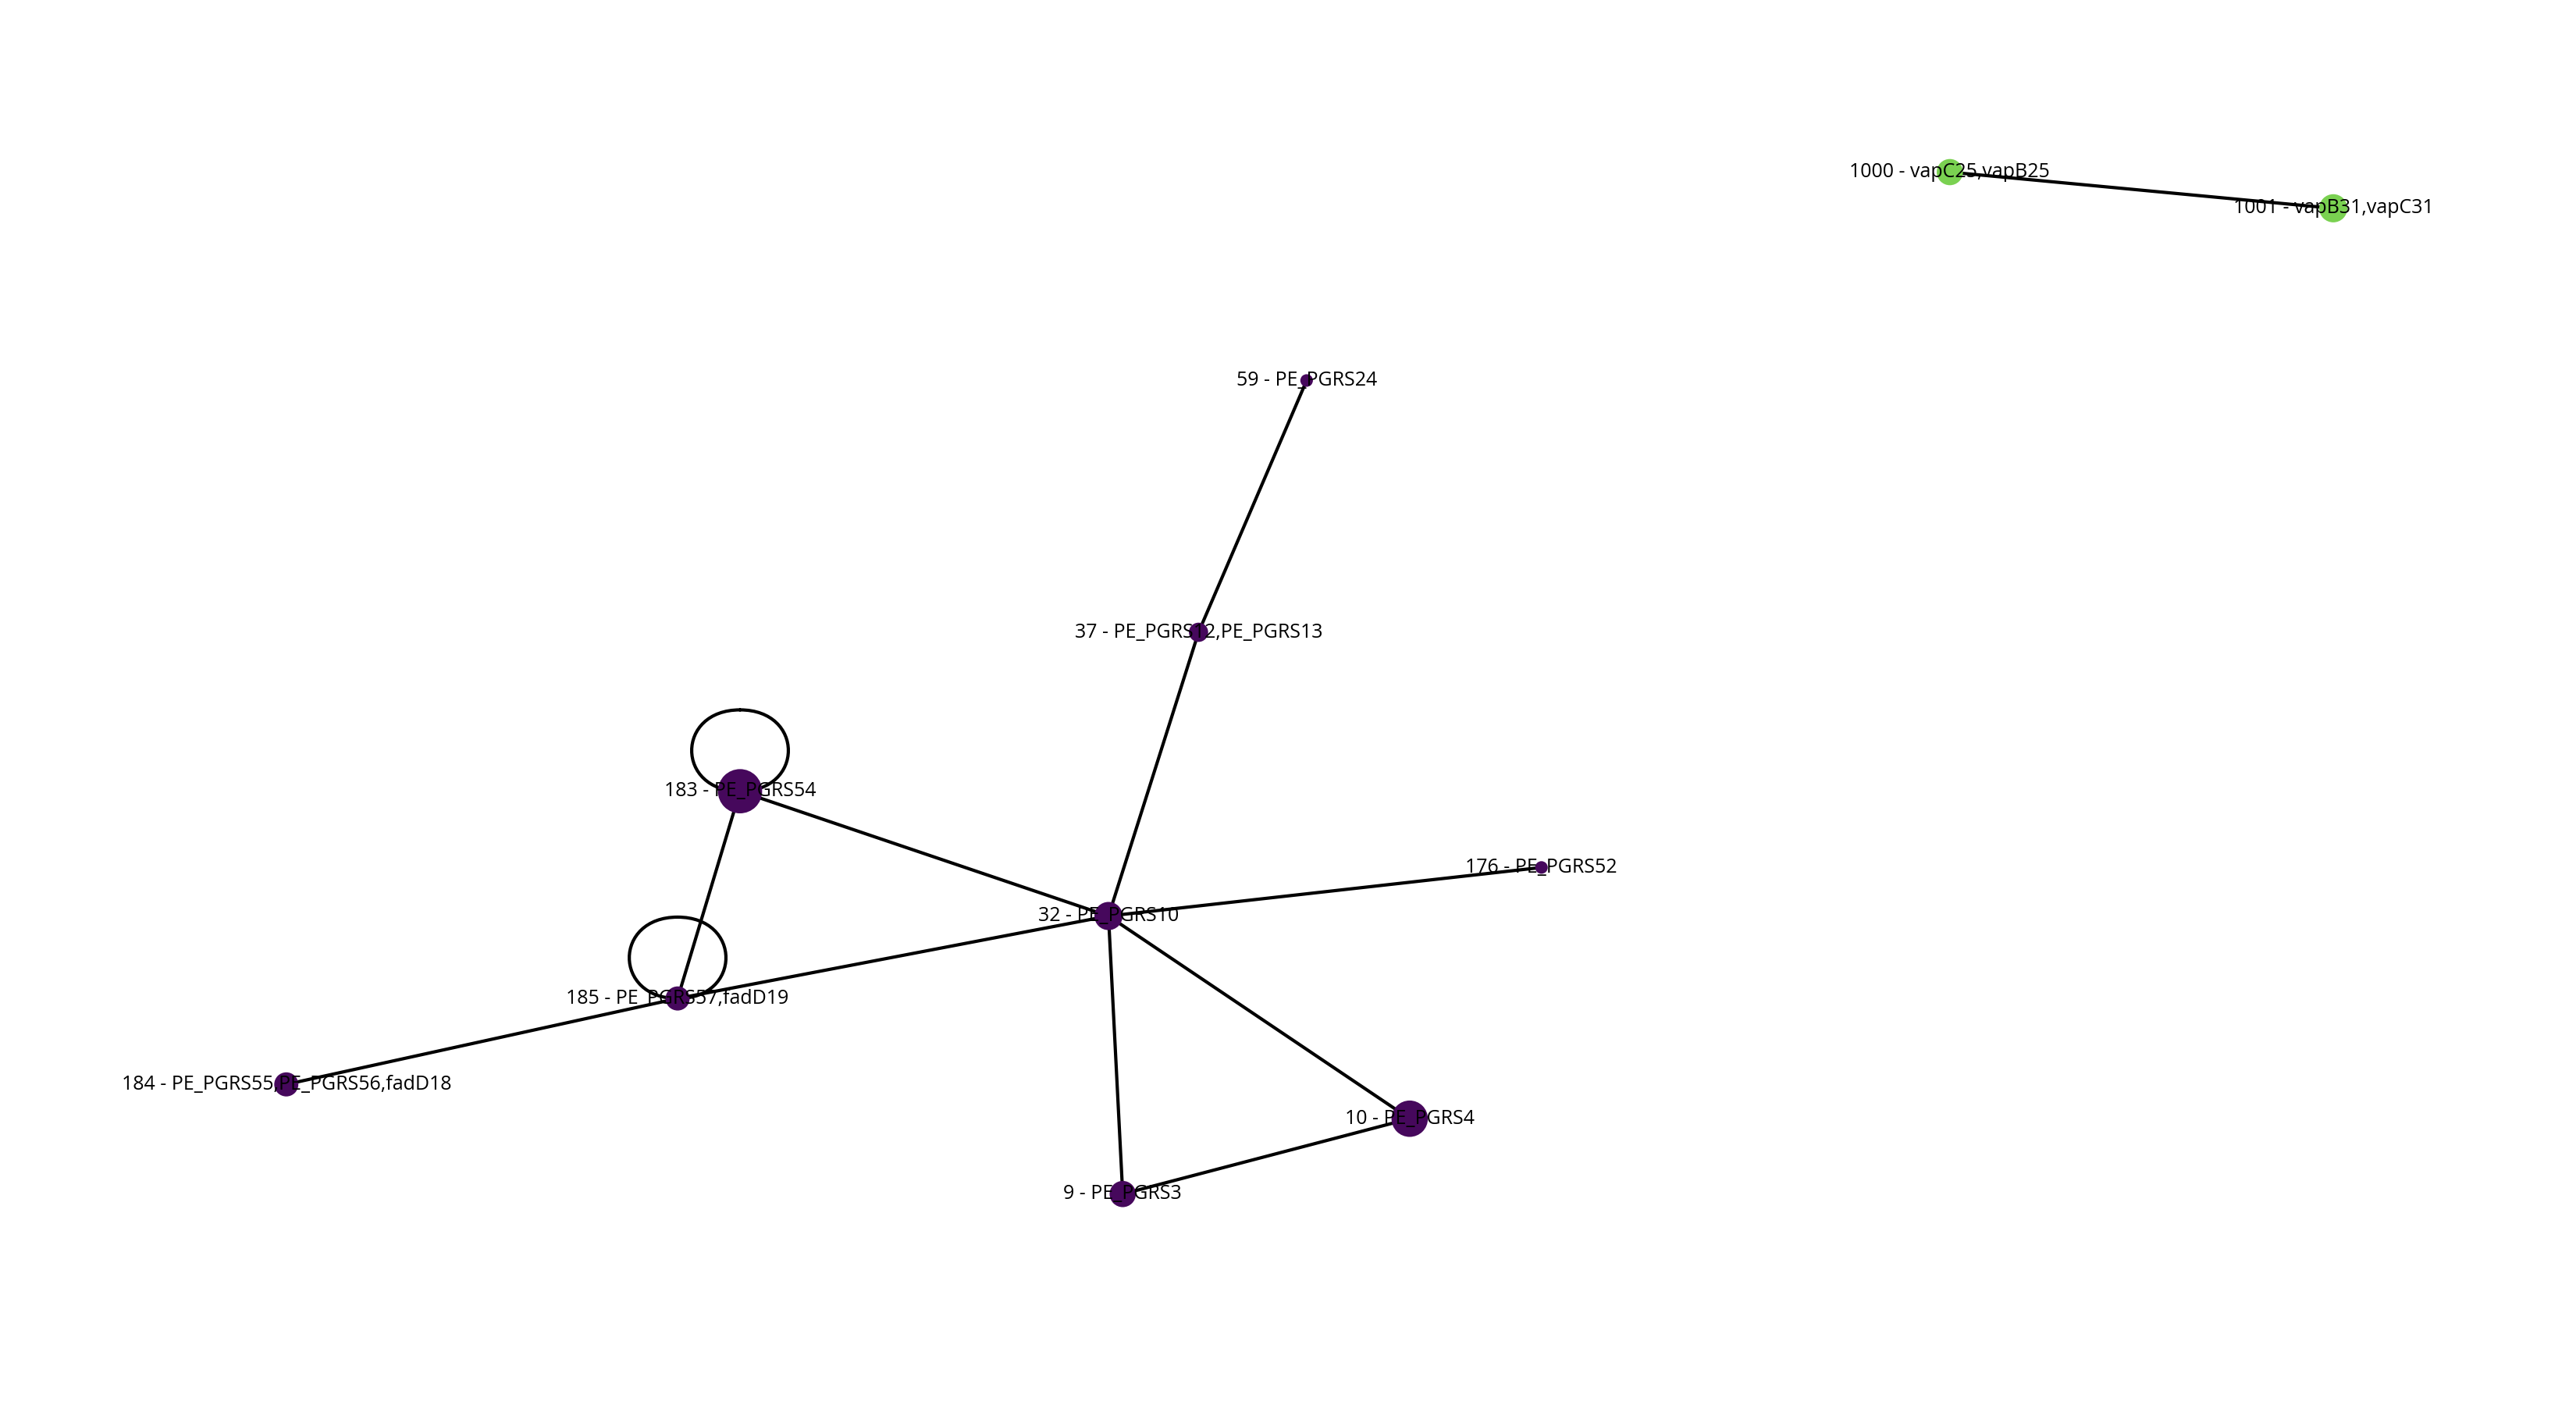

In [497]:
import networkx as nx
import matplotlib.pyplot as plt
import random

plt.figure(1, figsize=(10, 5))

in_Paralog_Graph = Subset_PN10_UniGraph_ALL
in_Paralog_Graph = in_Paralog_Graph.to_undirected()

# Layout graphs with positions using Graphviz neato
pos = nx.nx_agraph.graphviz_layout(in_Paralog_Graph, prog="neato", args='-Glen=0.2')

# Extract event counts and normalize for node size
event_counts_mGCE = nx.get_node_attributes(in_Paralog_Graph, "counts_mGCE")
event_counts_pGCE = nx.get_node_attributes(in_Paralog_Graph, "counts_pGCE")

node_sizes_mGCE = [25 + (v * 10) if v > 0 else 15 for v in event_counts_mGCE.values()]
node_sizes_pGCE = [25 + (v * 10) if v > 0 else 15 for v in event_counts_pGCE.values()]

# Color nodes the same in each connected subgraph
C = (in_Paralog_Graph.subgraph(c) for c in nx.connected_components(in_Paralog_Graph))
for g in C:
    c = [random.random()] * nx.number_of_nodes(g)  # Random color...
    nx.draw(
        g, pos,
        node_size = [node_sizes_pGCE[list(in_Paralog_Graph.nodes()).index(n)] for n in g.nodes()],  # Scale by events
        node_color=c,
        vmin=0.0, vmax=1.0,
        with_labels=True, font_size=6
    )

#plt.savefig("MappedEvents_GraphFiles/Mtb.ParalogSetNetworks.All.NX.V1.svg")
plt.show()


## Viz ModPN10 Network - Nodes w/ GCE only

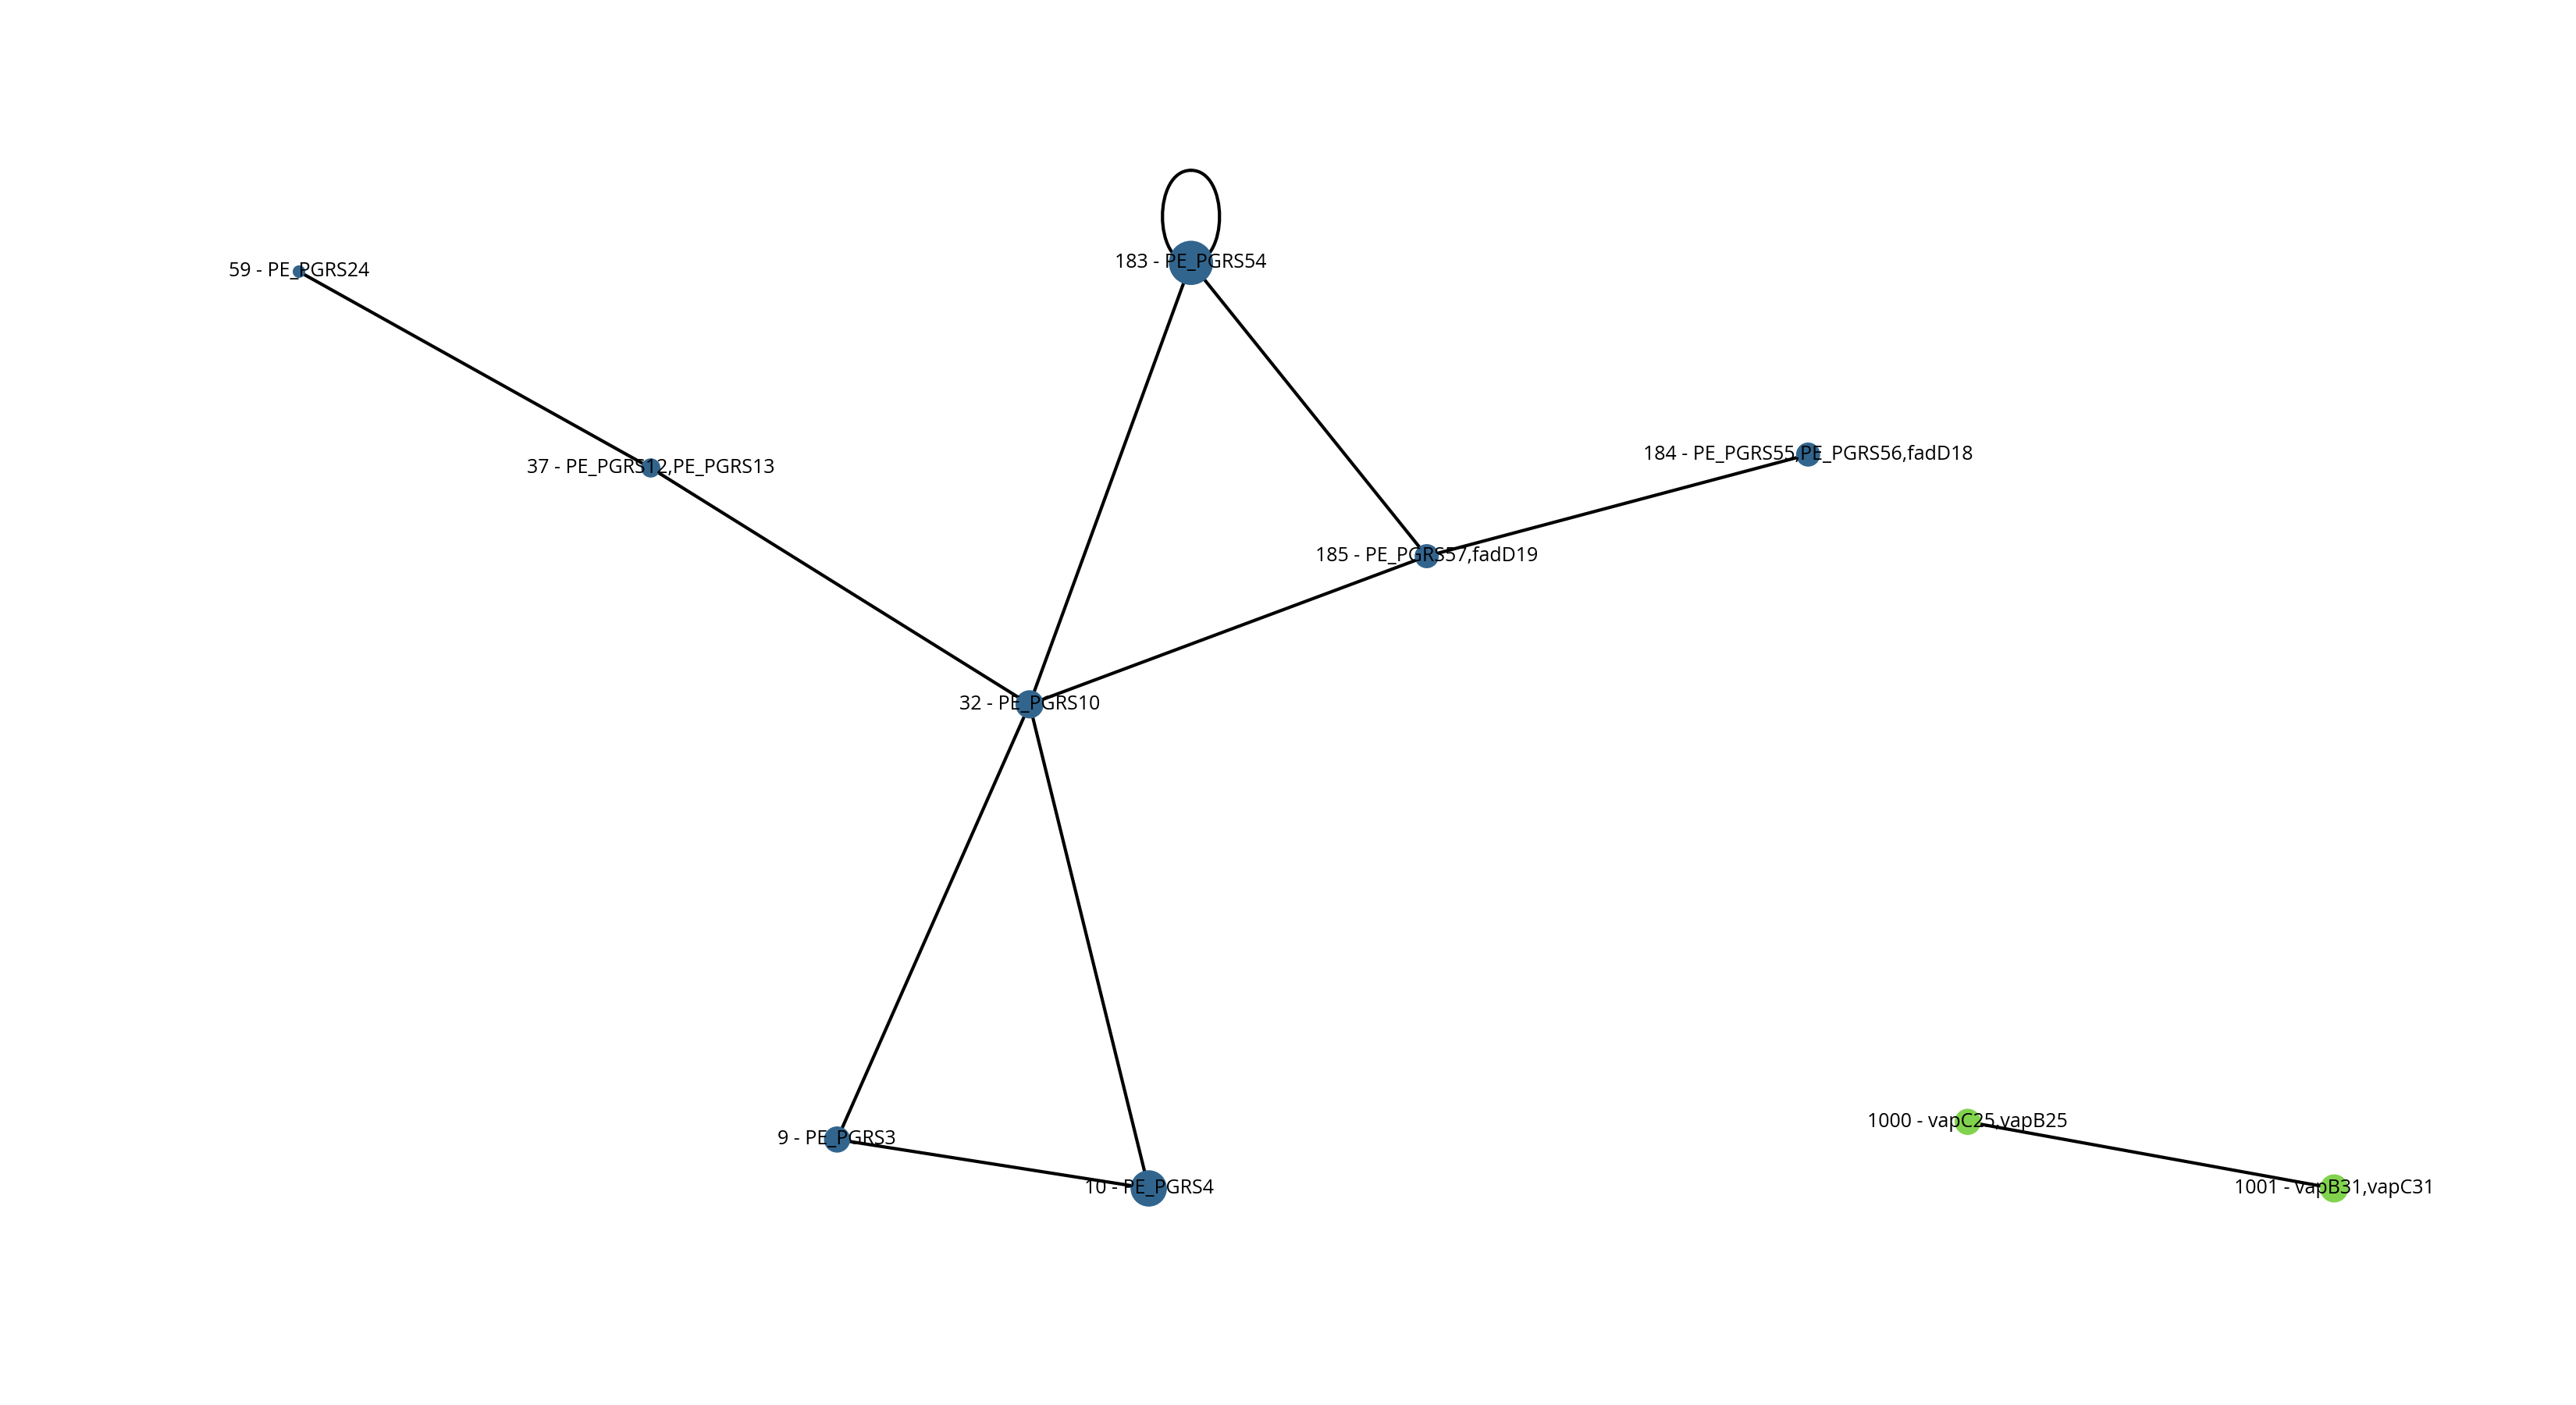

In [498]:
import networkx as nx
import matplotlib.pyplot as plt
import random

plt.figure(1, figsize=(10, 5))

in_Paralog_Graph = Subset_PN10_DiGraph_pGCE_Only
in_Paralog_Graph = in_Paralog_Graph.to_undirected()

# Layout graphs with positions using Graphviz neato
pos = nx.nx_agraph.graphviz_layout(in_Paralog_Graph, prog="neato", args='-Glen=0.2')

# Extract event counts and normalize for node size
event_counts_mGCE = nx.get_node_attributes(in_Paralog_Graph, "counts_mGCE")
event_counts_pGCE = nx.get_node_attributes(in_Paralog_Graph, "counts_pGCE")

node_sizes_mGCE = [25 + (v * 10) if v > 0 else 15 for v in event_counts_mGCE.values()]
node_sizes_pGCE = [25 + (v * 10) if v > 0 else 15 for v in event_counts_pGCE.values()]

# Color nodes the same in each connected subgraph
C = (in_Paralog_Graph.subgraph(c) for c in nx.connected_components(in_Paralog_Graph))
for g in C:
    c = [random.random()] * nx.number_of_nodes(g)  # Random color...
    nx.draw(
        g, pos,
        node_size = [node_sizes_pGCE[list(in_Paralog_Graph.nodes()).index(n)] for n in g.nodes()],  # Scale by events
        node_color=c,
        vmin=0.0, vmax=1.0,
        with_labels=True, font_size=6
    )

#plt.savefig("MappedEvents_GraphFiles/Mtb.ParalogSetNetworks.All.NX.V1.svg")
plt.show()


# Part 0:

# Create`H37Rv` Paralog Network Graphs 

## Build graphs of H37Rv paralog sets

In [531]:
PR_RegionNum_To_Genes_Dict = dict(HmRegions_DonorAndEventCt_ModPN10_DF[['HmRegion_Num', 'Overlap_Genes']].values)

In [532]:
HmPair_EventCt_ModPN10_DF.shape

(642, 51)

In [533]:
HmRegions_DonorAndEventCt_ModPN10_DF.shape

(202, 24)

### Create graph object (uni-directional) of ALL Hm-Pairs

In [534]:
PR_UniGraph_ALL = CreatePR_UGraph(HmRegions_DonorAndEventCt_ModPN10_DF,
                                  HmPair_EventCt_ModPN10_DF,
                                  edge_keep_mode = 'keep_all')


### Create graph object (uni-directional) of mapped EVENT COUNTs between Hm-Pairs

In [535]:
PR_UniGraph_mGCE_Only = CreatePR_UGraph(HmRegions_DonorAndEventCt_ModPN10_DF,
                                  HmPair_EventCt_ModPN10_DF,
                                  edge_keep_mode = 'keep_edges_Mapped_GCE')


### Create graph object (uni-directional) of putative EVENT COUNTs between Hm-Pairs

In [536]:
PR_UniGraph_pGCE_Only = CreatePR_UGraph(HmRegions_DonorAndEventCt_ModPN10_DF,
                                  HmPair_EventCt_ModPN10_DF,
                                  edge_keep_mode = 'keep_edges_Any_GCE')


### Create graph object (bi-directional) of ALL Hm-Pairs

In [537]:
PR_DiGraph_ALL = CreatePR_DiGraph(HmRegions_DonorAndEventCt_ModPN10_DF,
                                         HmPair_EventCt_ModPN10_DF,
                                         edge_keep_mode = 'keep_all')


### Create graph object (bi-directional) of mapped EVENT COUNTs between Hm-Pairs

In [538]:
PR_DiGraph_mGCE_Only = CreatePR_DiGraph(HmRegions_DonorAndEventCt_ModPN10_DF,
                                             HmPair_EventCt_ModPN10_DF,
                                             edge_keep_mode = 'keep_edges_Mapped_GCE')


### Create graph object (bi-directional) of putative EVENT COUNTs between Hm-Pairs

In [539]:
PR_DiGraph_pGCE_Only = CreatePR_DiGraph(HmRegions_DonorAndEventCt_ModPN10_DF,
                                                  HmPair_EventCt_ModPN10_DF,
                                                  edge_keep_mode = 'keep_edges_Any_GCE')


In [540]:
AllPRs_UniGraph_Stats_Dict, AllPRs_UniGraph_Stats_DF = summarize_graph_stats(PR_UniGraph_ALL)

for k in ["num_nodes", "num_edges", "num_connected_components"]:
    print(f"{k}: {AllPRs_UniGraph_Stats_Dict[k]}")
    

num_nodes: 202
num_edges: 279
num_connected_components: 71


In [541]:
AllPRs_DiGraph_Stats_Dict, AllPRs_DiGraph_Stats_DF = summarize_graph_stats(PR_DiGraph_ALL)

for k in ["num_nodes", "num_edges", "num_connected_components"]:
    print(f"{k}: {AllPRs_DiGraph_Stats_Dict[k]}")
    

num_nodes: 202
num_edges: 545
num_connected_components: 71


In [542]:
AllPRs_DiGraphToUni_Stats_Dict, AllPRs_DiGraphToUni_Stats_DF = summarize_graph_stats(PR_DiGraph_ALL.to_undirected())

for k in ["num_nodes", "num_edges", "num_connected_components"]:
    print(f"{k}: {AllPRs_DiGraphToUni_Stats_Dict[k]}")
    

num_nodes: 202
num_edges: 279
num_connected_components: 71


In [544]:
pGCE_UniGraph_Stats_Dict, pGCE_UniGraph_Stats_DF = summarize_graph_stats(PR_UniGraph_mGCE_Only)

for k in ["num_nodes", "num_edges", "num_connected_components"]:
    print(f"{k}: {pGCE_UniGraph_Stats_Dict[k]}")
    

num_nodes: 54
num_edges: 43
num_connected_components: 22


In [545]:
pGCE_DiGraph_Stats_Dict, pGCE_DiGraph_Stats_DF = summarize_graph_stats(PR_DiGraph_mGCE_Only)

for k in ["num_nodes", "num_edges", "num_connected_components"]:
    print(f"{k}: {pGCE_DiGraph_Stats_Dict[k]}")
    

num_nodes: 54
num_edges: 66
num_connected_components: 22


In [550]:
mGCE_UniGraph_Stats_Dict, mGCE_UniGraph_Stats_DF = summarize_graph_stats(PR_UniGraph_pGCE_Only)

for k in ["num_nodes", "num_edges", "num_connected_components"]:
    print(f"{k}: {mGCE_UniGraph_Stats_Dict[k]}")
    

num_nodes: 70
num_edges: 63
num_connected_components: 25


In [547]:
mGCE_DiGraph_Stats_Dict, mGCE_DiGraph_Stats_DF = summarize_graph_stats(PR_DiGraph_pGCE_Only)

for k in ["num_nodes", "num_edges", "num_connected_components"]:
    print(f"{k}: {mGCE_DiGraph_Stats_Dict[k]}")
    

num_nodes: 70
num_edges: 98
num_connected_components: 25


In [549]:
mGCE_DiGraph_Stats_Dict, mGCE_DiGraph_Stats_DF = summarize_graph_stats(PR_DiGraph_pGCE_Only.to_undirected())

for k in ["num_nodes", "num_edges", "num_connected_components"]:
    print(f"{k}: {mGCE_DiGraph_Stats_Dict[k]}")
    

num_nodes: 70
num_edges: 63
num_connected_components: 25


# Generate Paralog-Map Graph Visualizations (Non-directed)

## Viz pGCE RPS Network

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import random

plt.figure(1, figsize=(10, 5))

in_Paralog_Graph = Mtb_PR_Sets_pGCE_Ct_graph
in_Paralog_Graph = in_Paralog_Graph.to_undirected()

# Layout graphs with positions using Graphviz neato
pos = nx.nx_agraph.graphviz_layout(in_Paralog_Graph, prog="neato", args='-Glen=0.2')

# Extract event counts and normalize for node size
event_counts_mGCE = nx.get_node_attributes(in_Paralog_Graph, "counts_mGCE")
event_counts_pGCE = nx.get_node_attributes(in_Paralog_Graph, "counts_pGCE")

node_sizes_mGCE = [25 + (v * 10) if v > 0 else 10 for v in event_counts_mGCE.values()]
node_sizes_pGCE = [25 + (v * 10) if v > 0 else 10 for v in event_counts_pGCE.values()]

# Color nodes the same in each connected subgraph
C = (in_Paralog_Graph.subgraph(c) for c in nx.connected_components(in_Paralog_Graph))
for g in C:
    c = [random.random()] * nx.number_of_nodes(g)  # Random color...
    nx.draw(
        g, pos,
        node_size = [node_sizes_pGCE[list(in_Paralog_Graph.nodes()).index(n)] for n in g.nodes()],  # Scale by events
        node_color=c,
        vmin=0.0, vmax=1.0,
        with_labels=True, font_size=6
    )

#plt.savefig("MappedEvents_GraphFiles/Mtb.ParalogSetNetworks.All.NX.V1.svg")
plt.show()


# VIz graphs for specific Paralog Networks of interest

In [ ]:
PN10_B_NEW_SubG = subset_graph_by_PR_SetIDs(Mtb_PR_Sets_pGCE_Ct_graph, ["PR_Set_10_B"])
summarize_graph_stats(PN10_B_NEW_SubG)

In [ ]:
plt.figure(1, figsize=(10, 5))

in_Paralog_Graph = PN10_B_NEW_SubG
in_Paralog_Graph = in_Paralog_Graph.to_undirected()

# Remove nodes with counts_pGCE <= 0 (or missing)
# nodes_to_keep = [
#     n for n, d in in_Paralog_Graph.nodes(data=True)
#     if d.get("counts_pGCE", 0) > 0
# ]

# in_Paralog_Graph = in_Paralog_Graph.subgraph(nodes_to_keep).copy()

# Layout graphs with positions using Graphviz neato
pos = nx.nx_agraph.graphviz_layout(in_Paralog_Graph, prog="neato", args='-Glen=0.2')

# Extract event counts and normalize for node size
event_counts_mGCE = nx.get_node_attributes(in_Paralog_Graph, "counts_mGCE")
event_counts_pGCE = nx.get_node_attributes(in_Paralog_Graph, "counts_pGCE")

# Keep node order list so we can index consistently
all_nodes = list(in_Paralog_Graph.nodes())

node_sizes_mGCE = [
    35 + (event_counts_mGCE.get(n, 0) * 10) if event_counts_mGCE.get(n, 0) > 0 else 25
    for n in all_nodes
]

# Iterate over connected components
for comp_nodes in nx.connected_components(in_Paralog_Graph):
    g = in_Paralog_Graph.subgraph(comp_nodes)

    # Random color per component
    c = [random.random()] * nx.number_of_nodes(g)

    # Node sizes for this component (mapped from global order)
    comp_node_sizes = [
        node_sizes_mGCE[all_nodes.index(n)]
        for n in g.nodes()
    ]

    nx.draw(
        g, pos,
        node_size=comp_node_sizes,   # Scale by events
        node_color=c,
        vmin=0.0, vmax=1.0,
        with_labels=True, font_size=6
    )


    # ---------- Add node labels above each node ----------
    # y_offset = 10  # vertical offset in layout units; tune as needed

    # for n in g.nodes():
    #     x, y = pos[n]
    #     plt.text(
    #         x,
    #         y + y_offset,
    #         str(n),                # or use a node attribute instead
    #         ha="center",
    #         va="bottom",
    #         fontsize=6,
    #         color="black"
    #     )

plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
PN10_OG_SubG = subset_graph_by_PR_SetIDs(Mtb_PR_Sets_All_graph, ["PR_Set_10"])


In [ ]:
summarize_graph_stats(PN10_OG_SubG)

### Viz OG `ParalogNetwork-10`

In [ ]:
plt.figure(1, figsize=(10, 5))

in_Paralog_Graph = PN10_OG_SubG
in_Paralog_Graph = in_Paralog_Graph.to_undirected()

# Remove nodes with counts_pGCE <= 0 (or missing)
# nodes_to_keep = [
#     n for n, d in in_Paralog_Graph.nodes(data=True)
#     if d.get("counts_pGCE", 0) > 0
# ]

# in_Paralog_Graph = in_Paralog_Graph.subgraph(nodes_to_keep).copy()

# Layout graphs with positions using Graphviz neato
pos = nx.nx_agraph.graphviz_layout(in_Paralog_Graph, prog="neato", args='-Glen=0.2')

# Extract event counts and normalize for node size
event_counts_mGCE = nx.get_node_attributes(in_Paralog_Graph, "counts_mGCE")
event_counts_pGCE = nx.get_node_attributes(in_Paralog_Graph, "counts_pGCE")

# Keep node order list so we can index consistently
all_nodes = list(in_Paralog_Graph.nodes())

node_sizes_mGCE = [
    35 + (event_counts_mGCE.get(n, 0) * 10) if event_counts_mGCE.get(n, 0) > 0 else 25
    for n in all_nodes
]

# Iterate over connected components
for comp_nodes in nx.connected_components(in_Paralog_Graph):
    g = in_Paralog_Graph.subgraph(comp_nodes)

    # Random color per component
    c = [random.random()] * nx.number_of_nodes(g)

    # Node sizes for this component (mapped from global order)
    comp_node_sizes = [
        node_sizes_mGCE[all_nodes.index(n)]
        for n in g.nodes()
    ]

    nx.draw(
        g, pos,
        node_size=comp_node_sizes,   # Scale by events
        node_color=c,
        vmin=0.0, vmax=1.0,
        with_labels=True, font_size=6
    )


    # ---------- Add node labels above each node ----------
    # y_offset = 10  # vertical offset in layout units; tune as needed

    # for n in g.nodes():
    #     x, y = pos[n]
    #     plt.text(
    #         x,
    #         y + y_offset,
    #         str(n),                # or use a node attribute instead
    #         ha="center",
    #         va="bottom",
    #         fontsize=6,
    #         color="black"
    #     )

plt.axis("off")
plt.tight_layout()
plt.show()

# Extras

# Extra Viz of entire tree + vapBC paralog events

In [ ]:
i_Symbol = "vapC31"

GeneInfo_DF = H37Rv_GenomeAnno_Genes_DF.query(f"Symbol == '{i_Symbol}'")
i_Gene_Start = GeneInfo_DF["Start"].values[0]
i_Gene_End = GeneInfo_DF["End"].values[0]
Viz_Start, Viz_End =  i_Gene_Start - 2900 , i_Gene_End + 50

print(Viz_Start, Viz_End)

fig, axes, summaries = viz_region_Tree_Variants_Anno(
    Viz_Start, Viz_End,
    in_Genome_Graphic_Record = Mtb_H37rv_Graphic_Record,
    inputTree = Mtb_151CI_Tree_V1,
    i_AllVar_DF = AllAsm_AllVar_DF,
    i_GCE_DF = GCE_All_DF,       # or None
    figsize = (14,16),
    tree_rect=(0.2, 0.1, 0.3, 0.8),
)


In [ ]:
i_Symbol = "vapC25"

GeneInfo_DF = H37Rv_GenomeAnno_Genes_DF.query(f"Symbol == '{i_Symbol}'")
i_Gene_Start = GeneInfo_DF["Start"].values[0]
i_Gene_End = GeneInfo_DF["End"].values[0]
Viz_Start, Viz_End =  i_Gene_Start - 30 , i_Gene_End + 3400
print(Viz_Start, Viz_End)

fig, axes, summaries = viz_region_Tree_Variants_Anno(
    Viz_Start, Viz_End,
    in_Genome_Graphic_Record = Mtb_H37rv_Graphic_Record,
    inputTree = Mtb_151CI_Tree_V1,
    i_AllVar_DF = AllAsm_AllVar_DF,
    i_GCE_DF = GCE_All_DF,       # or None
    figsize = (14,16),
    tree_rect=(0.2, 0.1, 0.3, 0.8),
)
